# Connect Forest Management Model with Forest Carbon Budget Model

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [2]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [3]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='equitysilver',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='min_em',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', index=2, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AA…

Dropdown(description='Objective:', index=3, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='min_em')

In [4]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [5]:
#Start Calculating the Running Time
Start = time.time()

In [6]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [7]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [8]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [9]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [10]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/equitysilver_c_curves_p.pkl
Loaded data from ./inputs/curves/equitysilver_c_curves_f.pkl


In [11]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

Running for equitysilver_min_em_no_cons...
running no_cons scenario
Set parameter Username
Academic license - for non-commercial use only - expires 2025-01-09
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17023 rows, 83258 columns and 83258 nonzeros
Model fingerprint: 0xaf55b042
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 17023 rows and 83258 columns
Presolve time: 0.08s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0   -2.6480129e+07   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.09 seconds (0.03 work units)
Optimal objective -2.648012911e+07


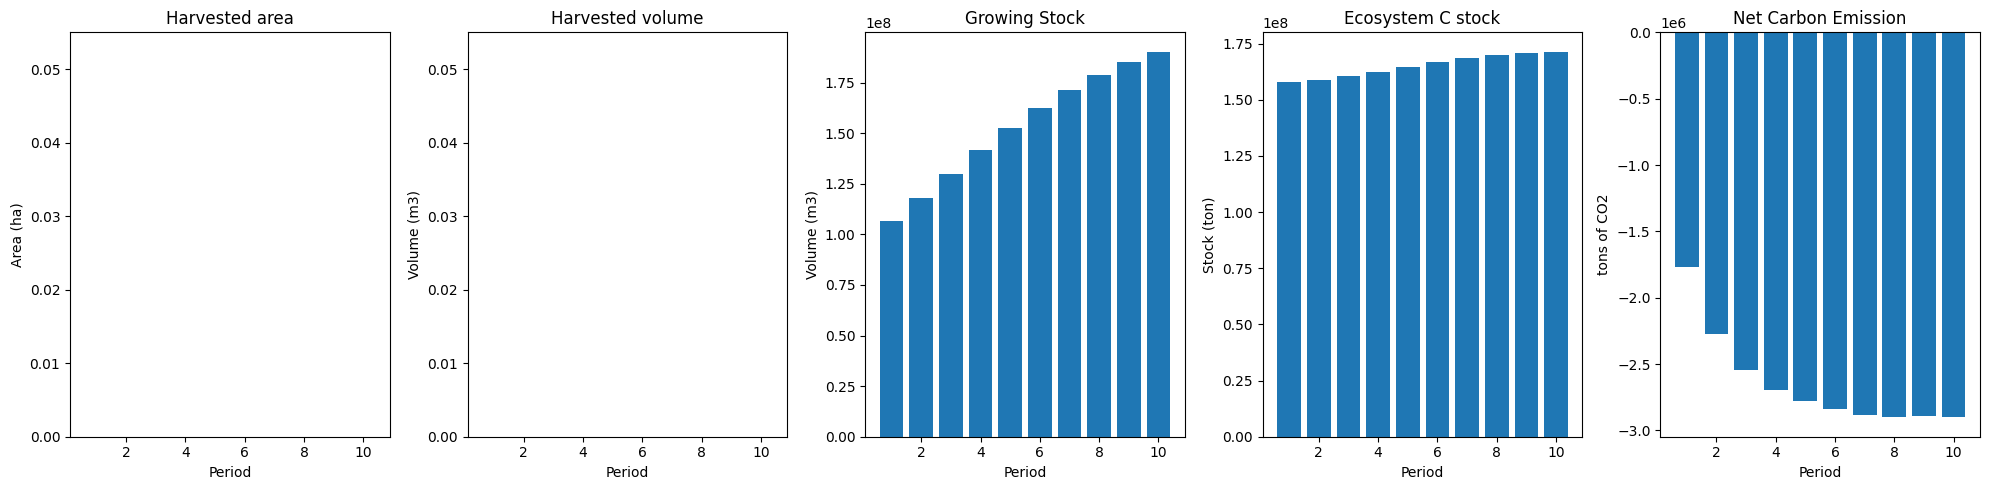

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_no_cons_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  0
The economic indicator (the provincial government revenues) is:  0
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


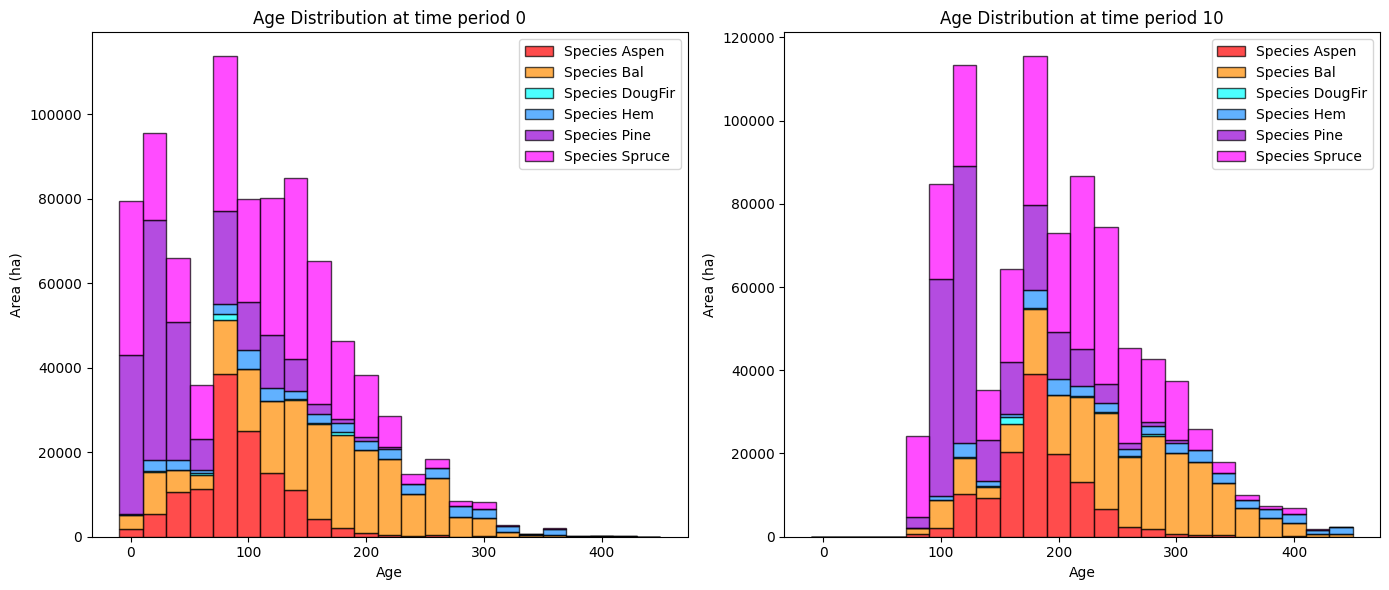

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_no_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   32688.964561   13536.837333
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  157689.747715   98373.777247
Spruce   36410.744598  198358.607639  161947.863041
Aspen    29632.731169  118345.834248   88713.103079
Pine      7432.733686   70671.811755   63239.078069

Overall diversity has **increased** by 427612.91 hectares from time period 0 to time period 10.


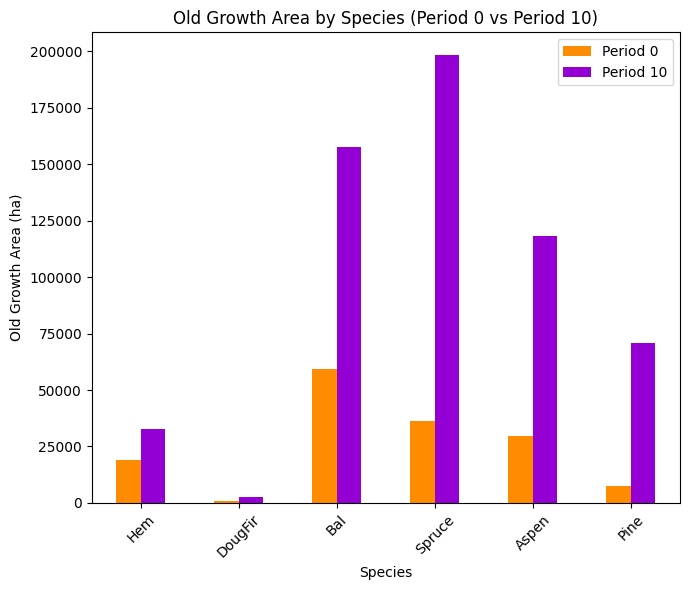

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_no_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7457

Diversity has **decreased** by 1.35% from time 0 to time 10.


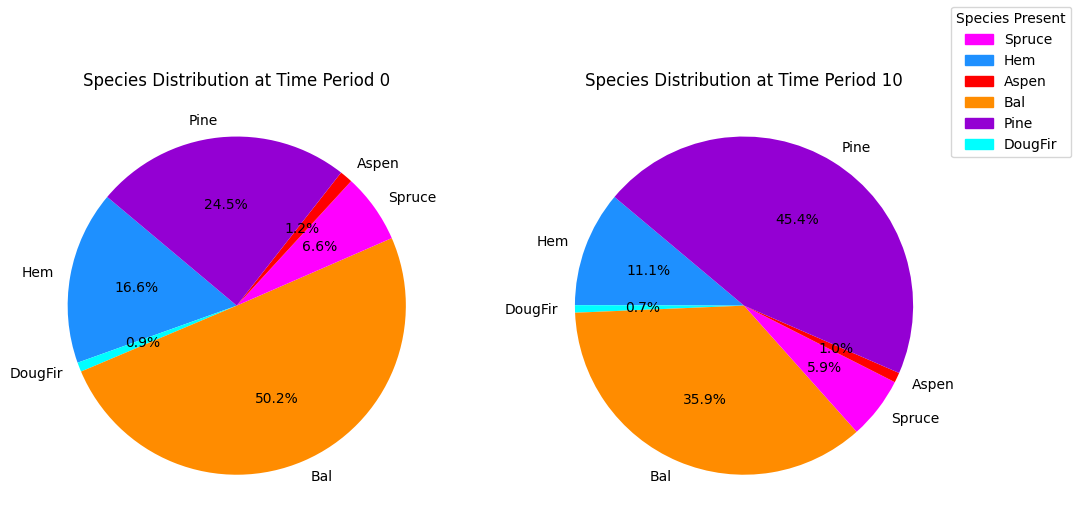

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_no_cons_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.23s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering t

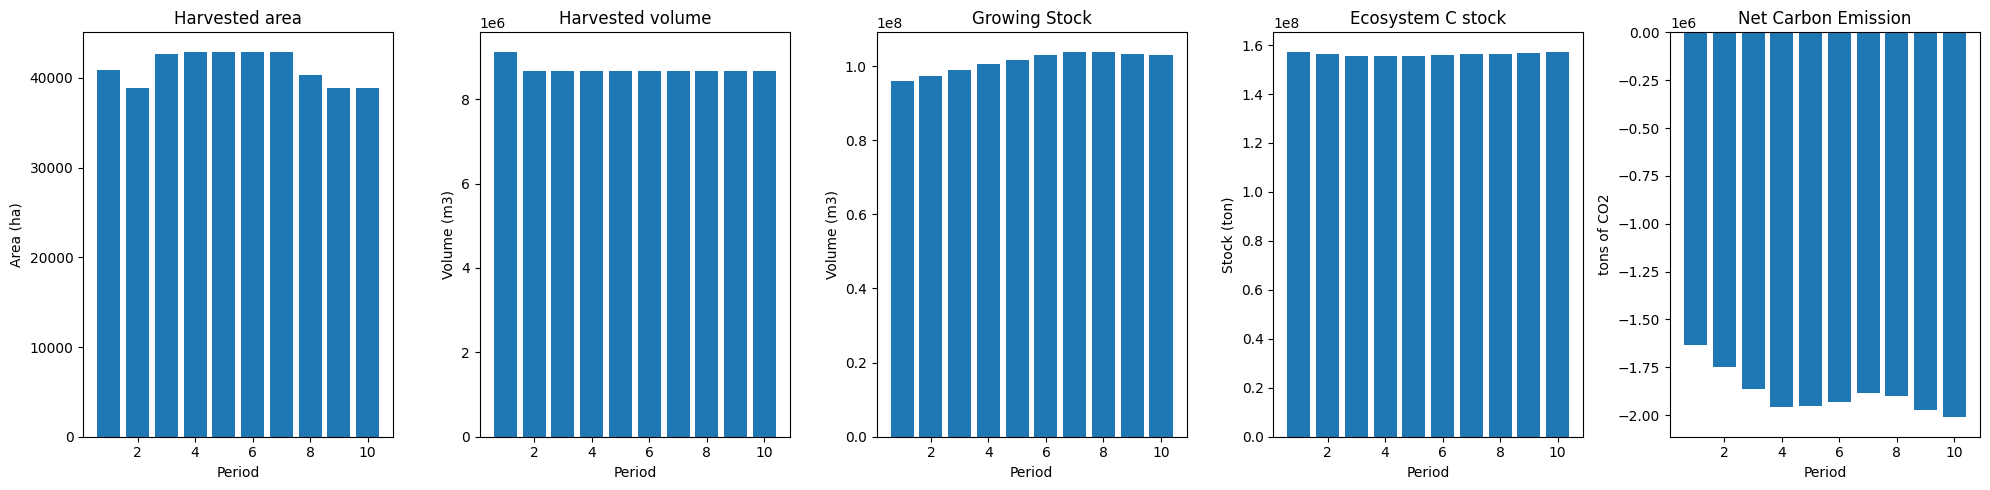

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


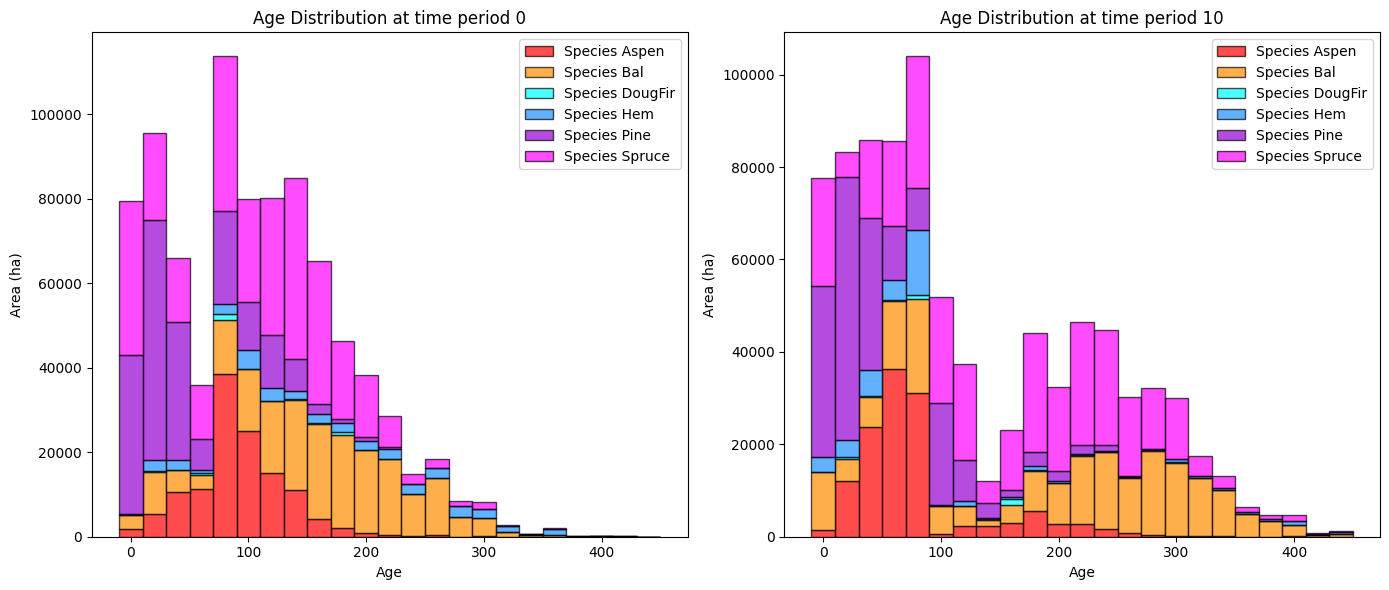

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


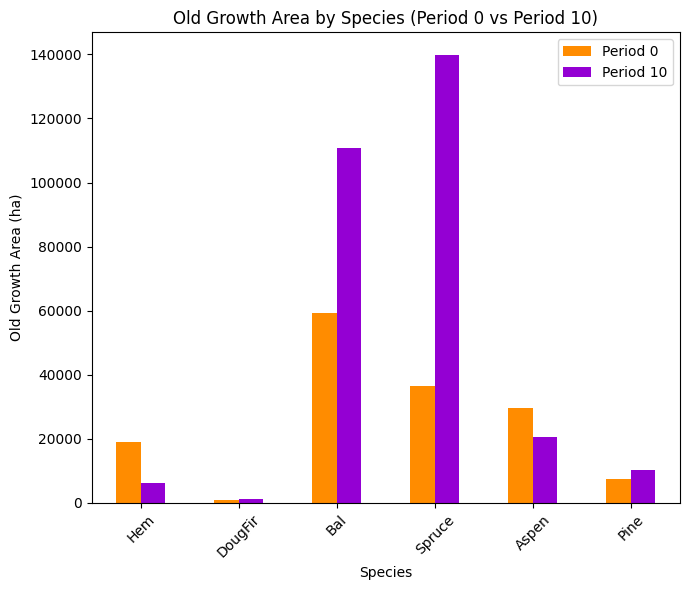

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


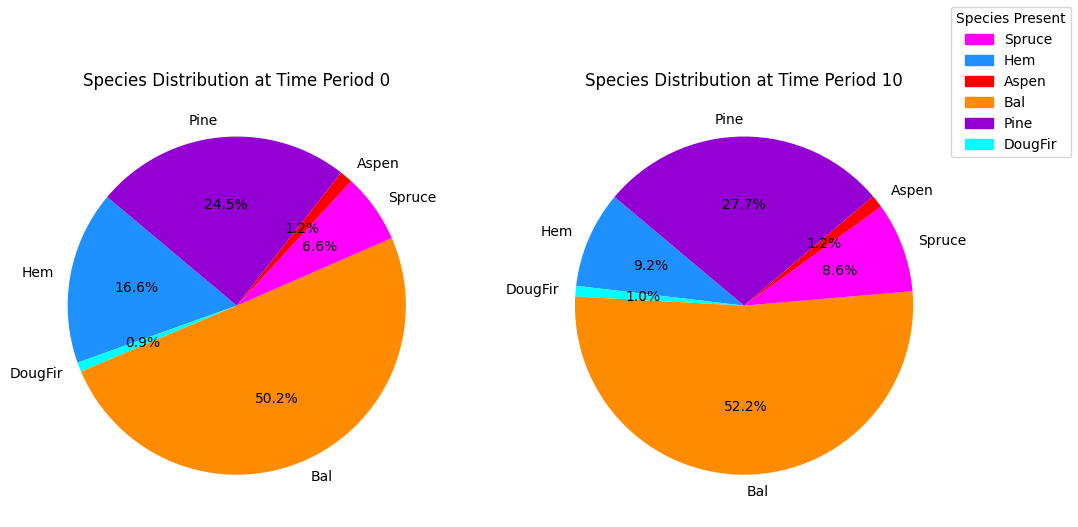

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


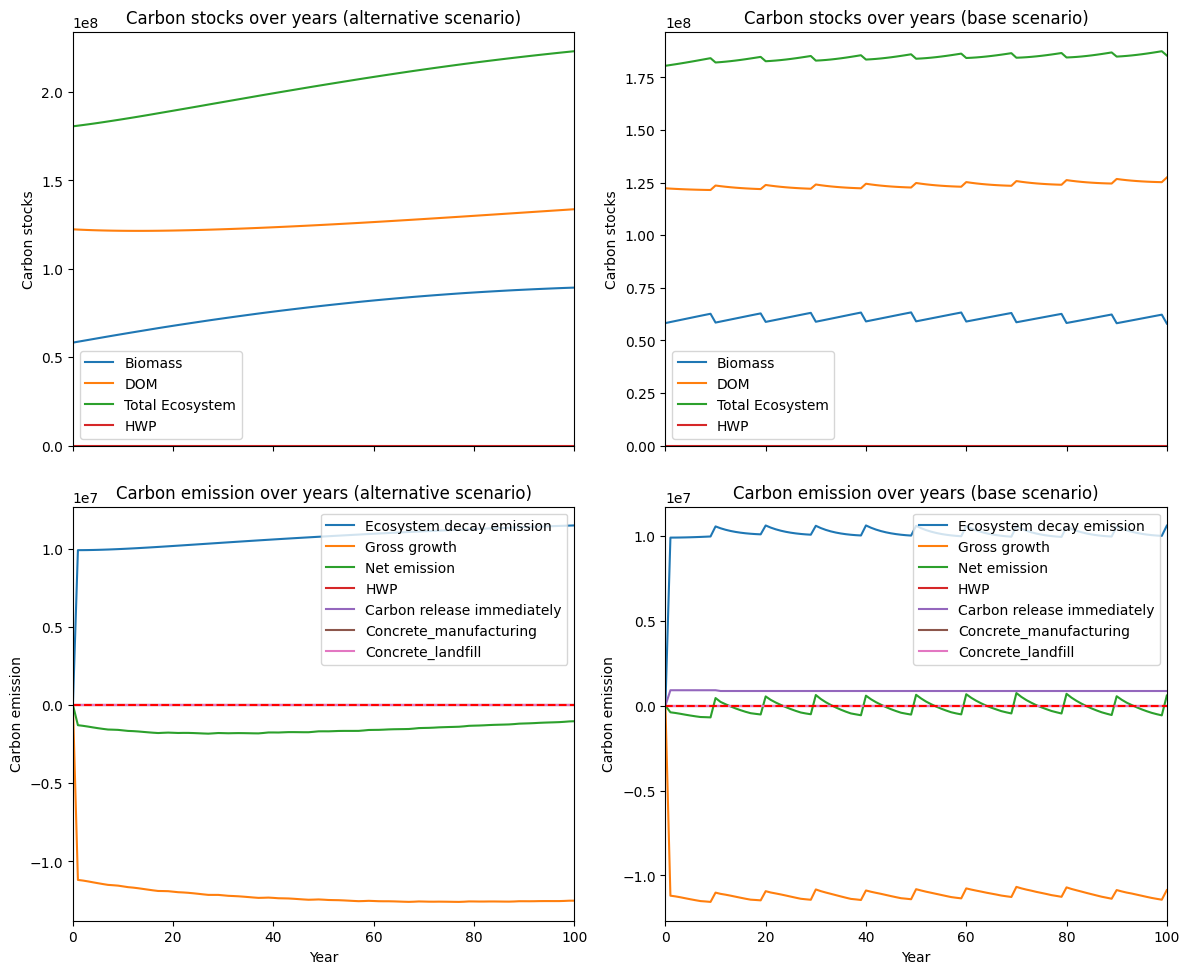

---------------------------------------------------------------------------------------
Net emission difference -33881682.10012411
Net emission base scenario -39533774.029656515
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  0.29514473249730916
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  26409.408269  26409.408269
DougFir  0.0   1390.176949   1390.176949
Bal      0.0  46798.376425  46798.376425
Spruce   0.0  58478.797204  58478.797204
Aspen    0.0  97656.306280  97656.306280
Pine     0.0  60486.603712  60486.603712

Overall, the old growth area has **increased** by 291219.67 hectares in the alternative scenario compared to the base scenario.


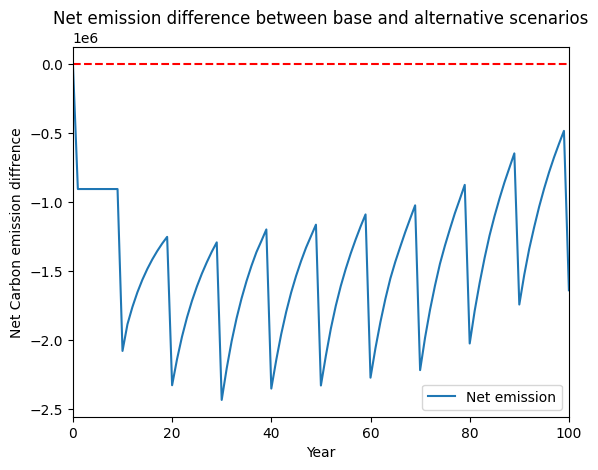

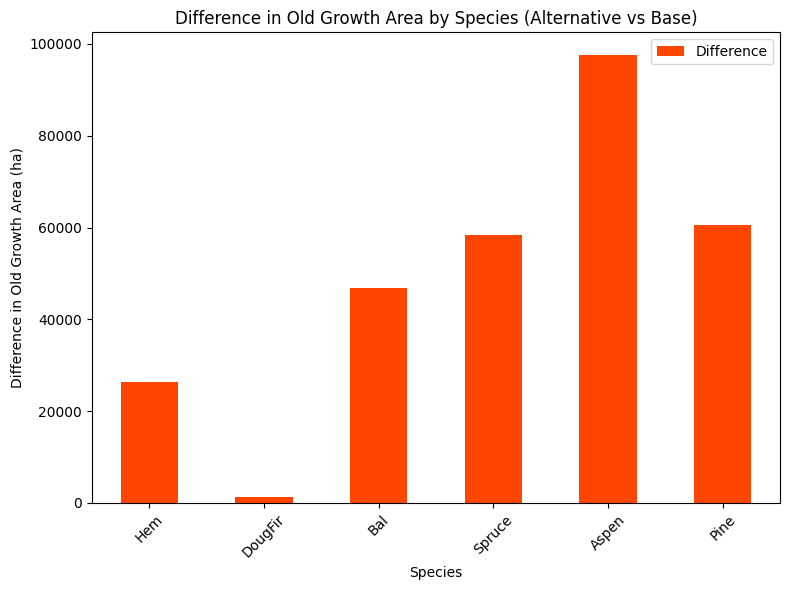

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


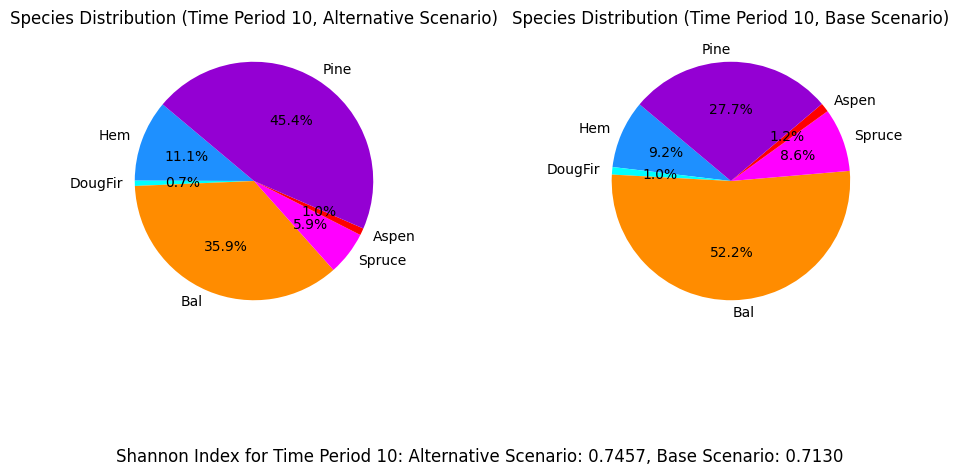

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_evenflow_cons...
running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17063 rows, 83258 columns and 514878 nonzeros
Model fingerprint: 0xc1400b13
Coefficient statistics:
  Matrix range     [5e-03, 6e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 8690 rows and 8884 columns
Presolve time: 0.20s
Presolved: 8373 rows, 74374 columns, 486421 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Orde

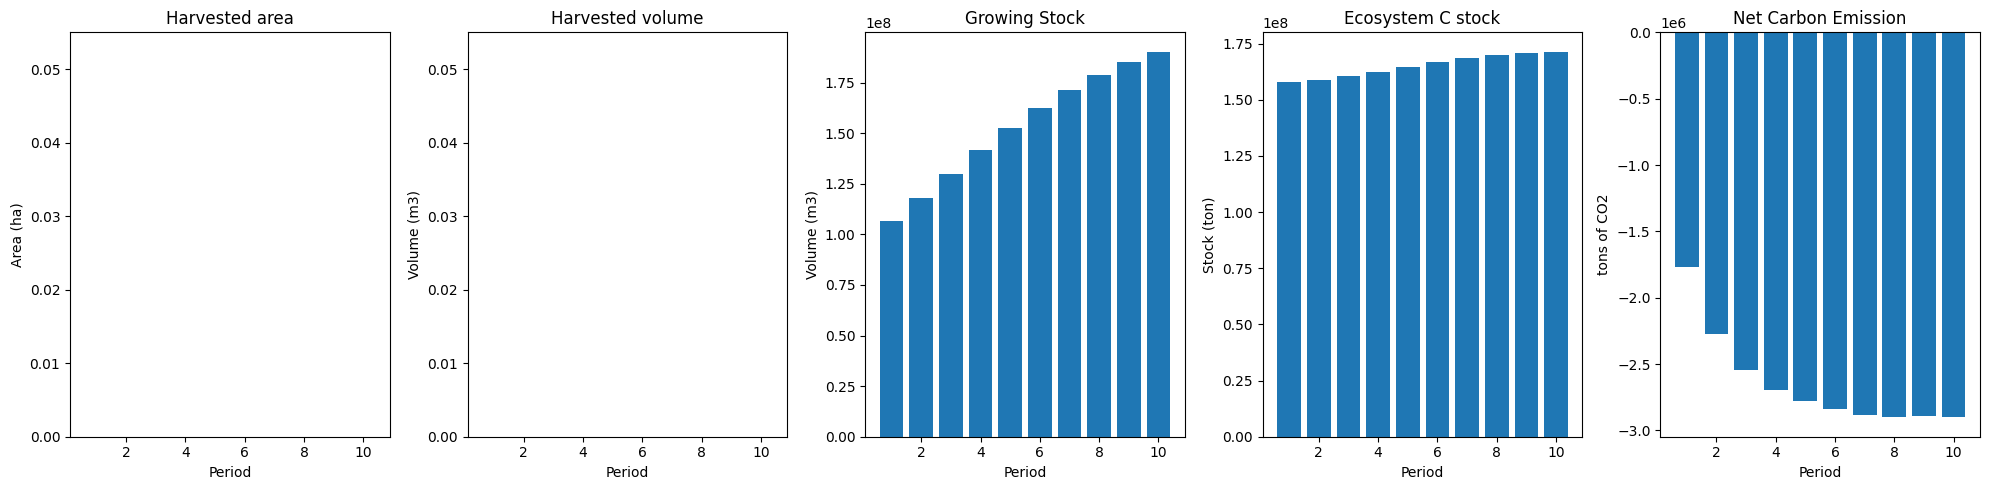

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_evenflow_cons_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  0
The economic indicator (the provincial government revenues) is:  0
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


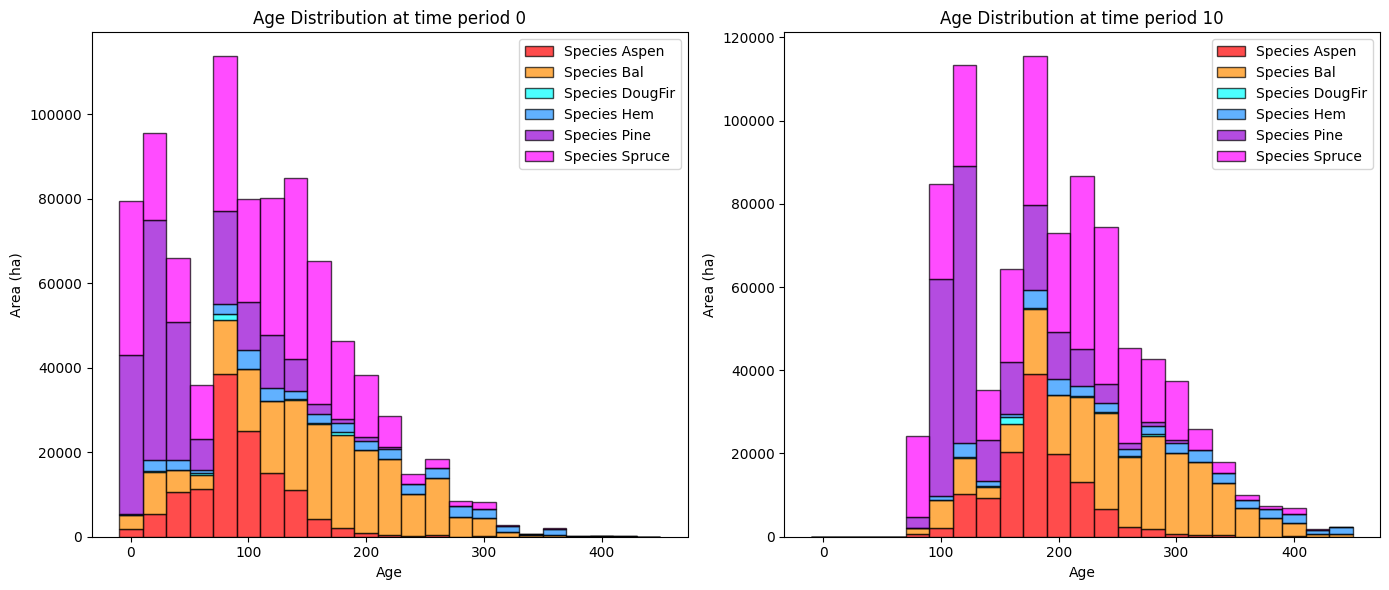

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   32688.964561   13536.837333
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  157689.747715   98373.777247
Spruce   36410.744598  198358.607639  161947.863041
Aspen    29632.731169  118345.834248   88713.103079
Pine      7432.733686   70671.811755   63239.078069

Overall diversity has **increased** by 427612.91 hectares from time period 0 to time period 10.


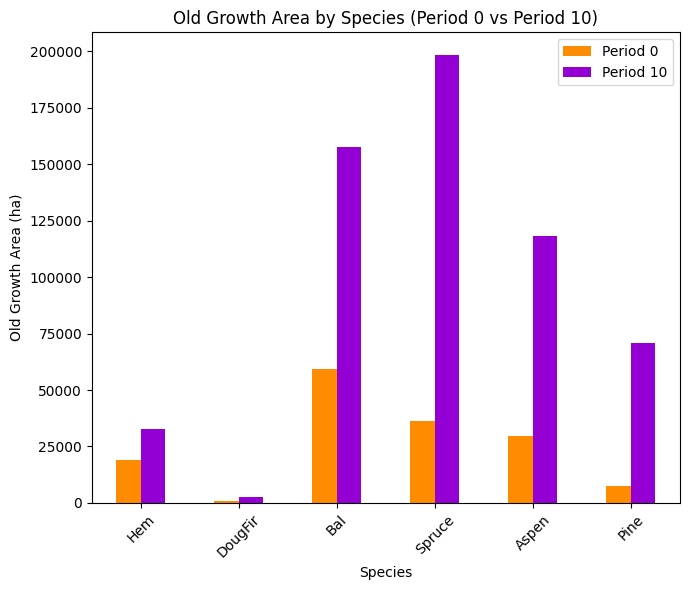

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7457

Diversity has **decreased** by 1.35% from time 0 to time 10.


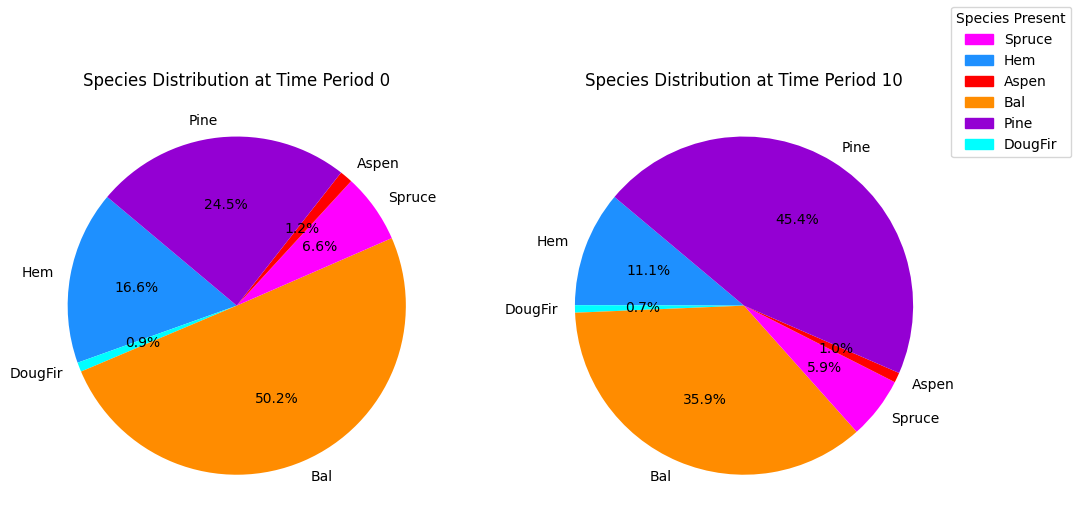

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_evenflow_cons_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.23s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Orde

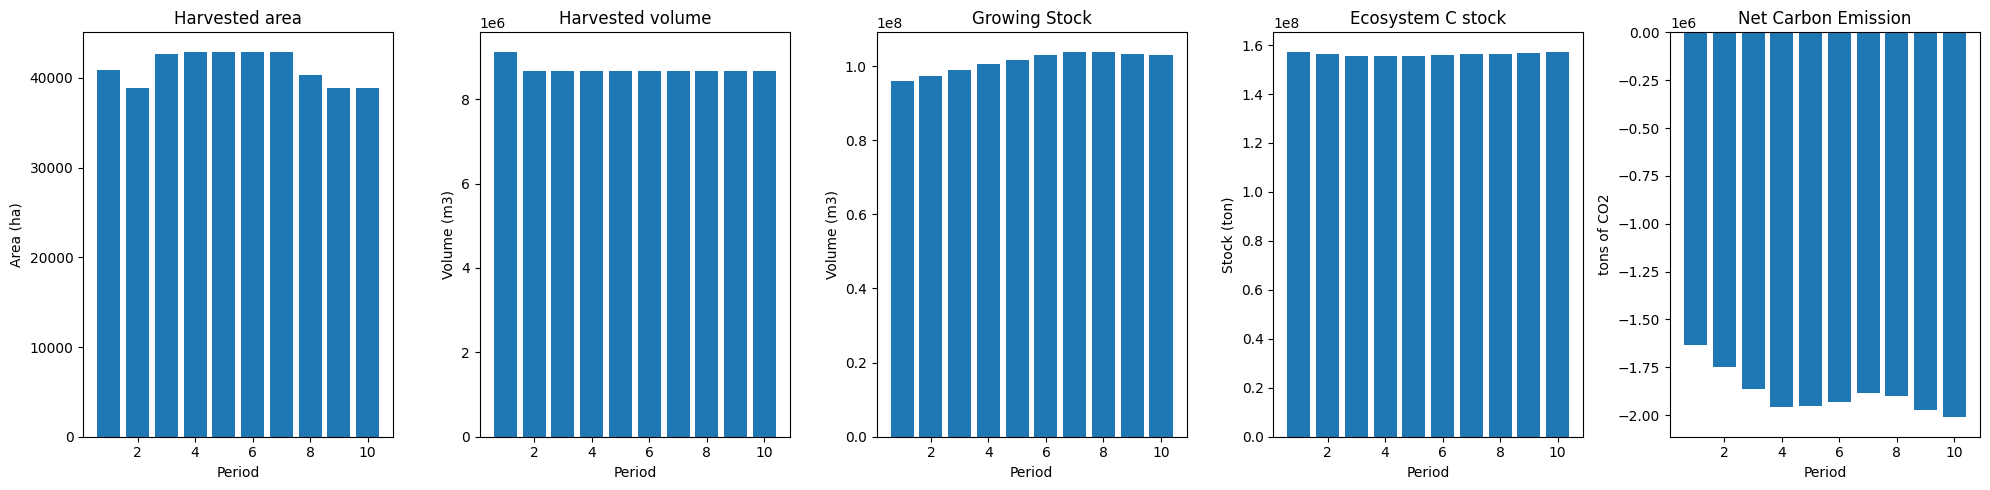

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


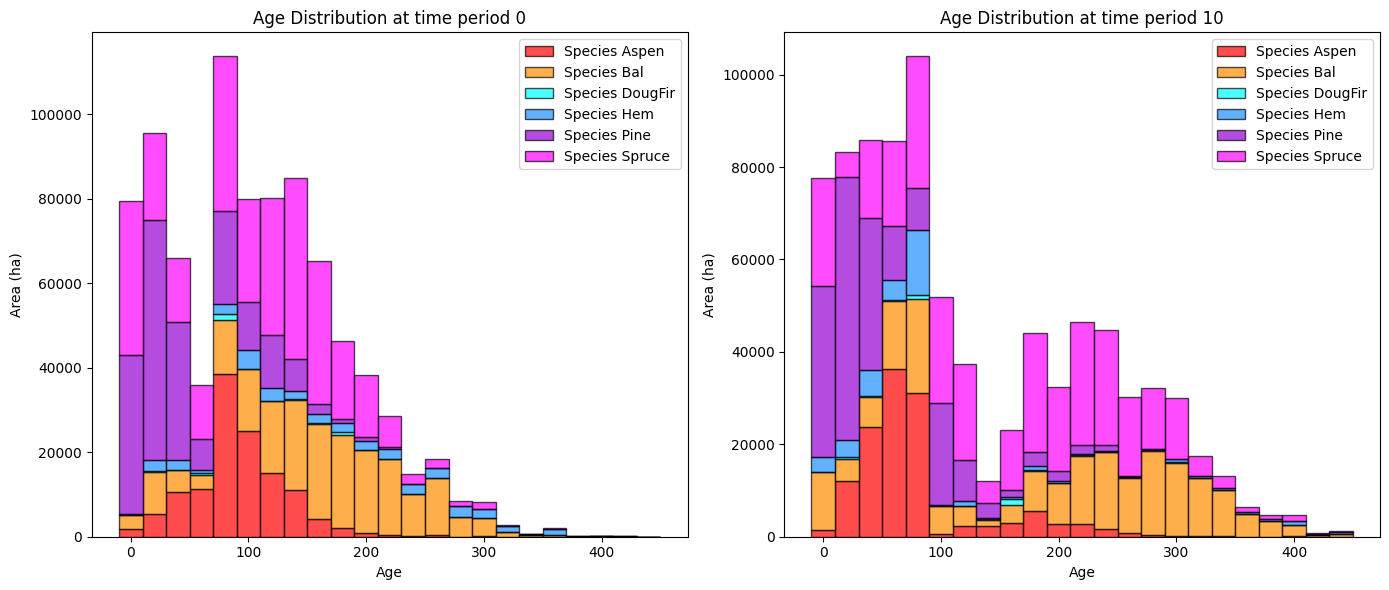

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


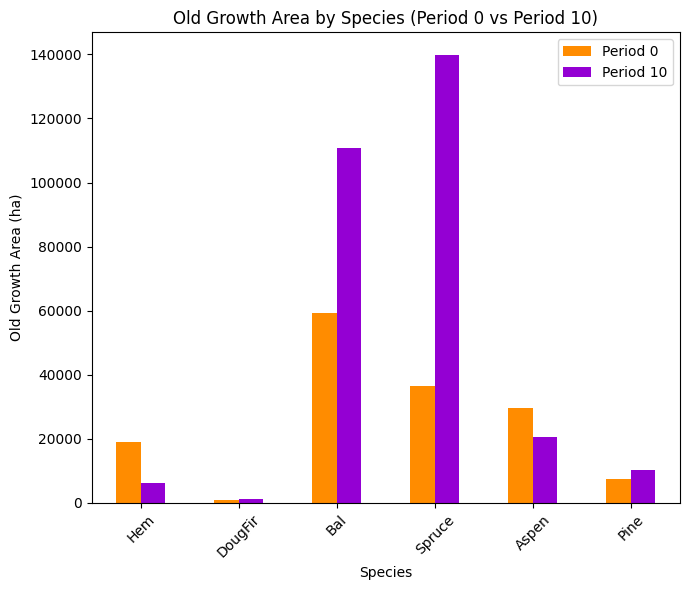

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


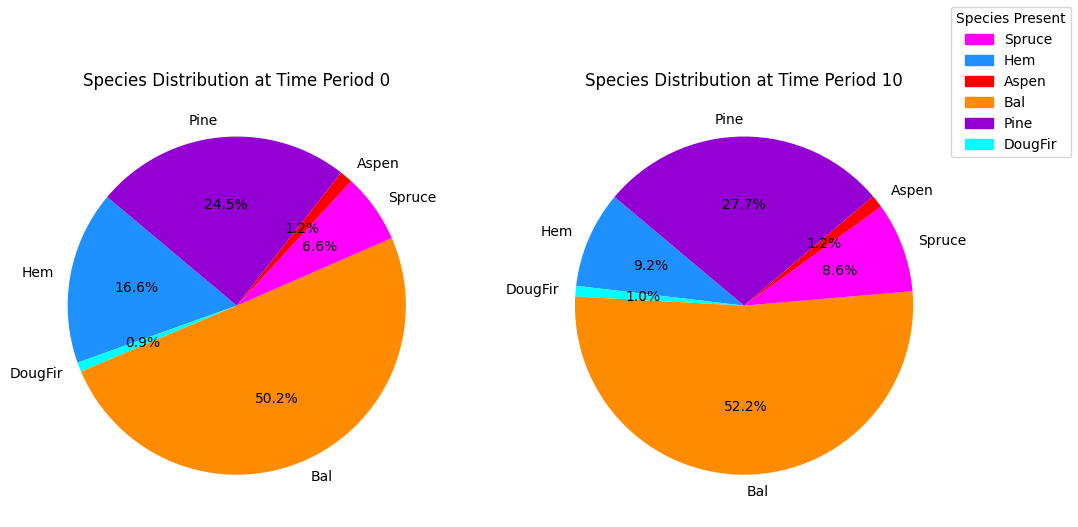

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


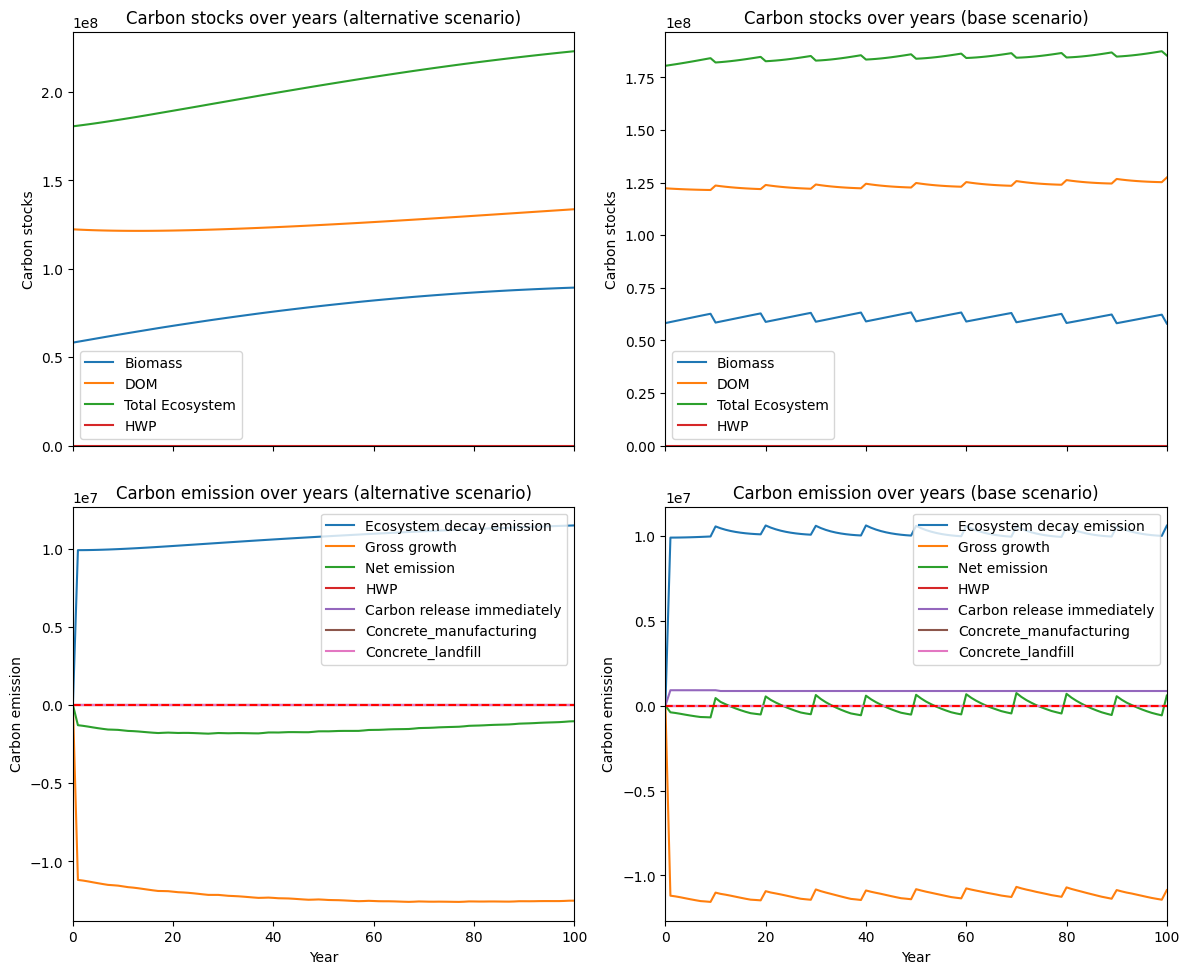

---------------------------------------------------------------------------------------
Net emission difference -33881682.10012411
Net emission base scenario -39533774.029656515
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  0.29514473249730916
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  26409.408269  26409.408269
DougFir  0.0   1390.176949   1390.176949
Bal      0.0  46798.376425  46798.376425
Spruce   0.0  58478.797204  58478.797204
Aspen    0.0  97656.306280  97656.306280
Pine     0.0  60486.603712  60486.603712

Overall, the old growth area has **increased** by 291219.67 hectares in the alternative scenario compared to the base scenario.


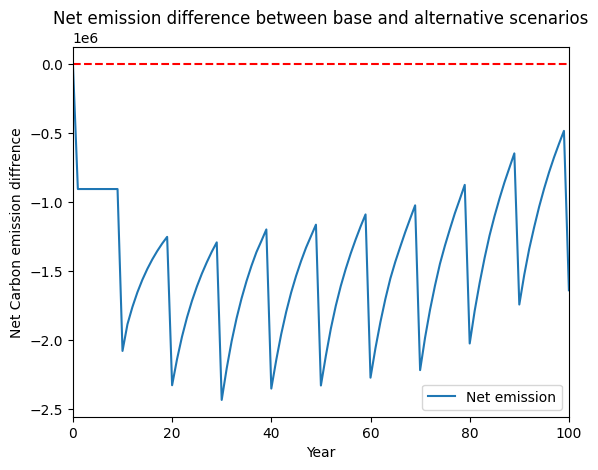

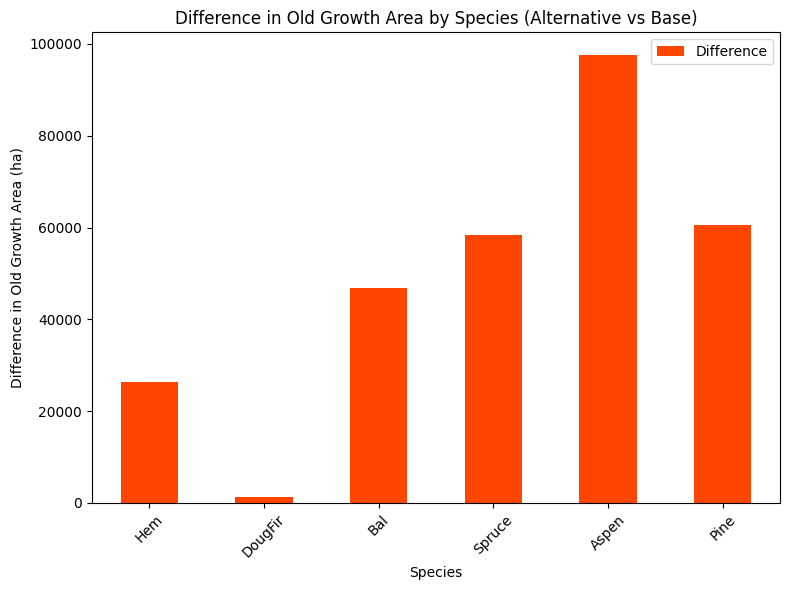

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


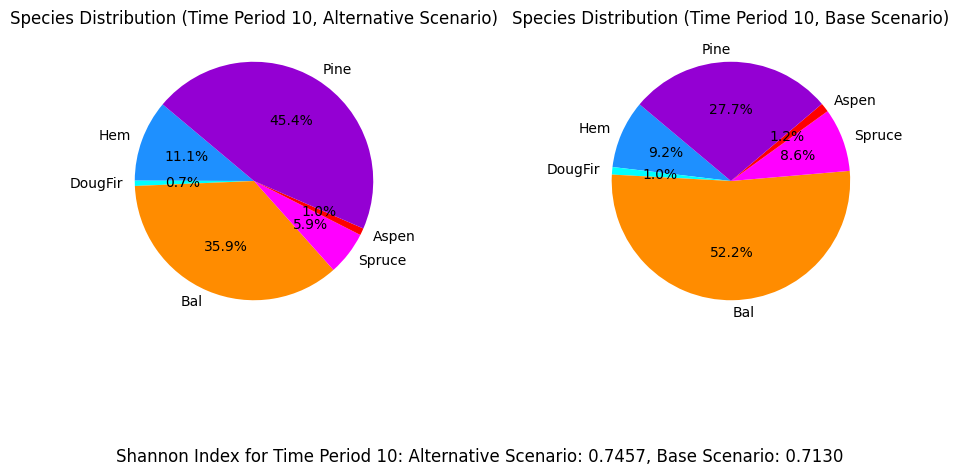

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_eqtslvr_AAC_90%...
running the scenario for the Equity Silver mining site (90%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x3482f110
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.27s
Presolved: 8375 r

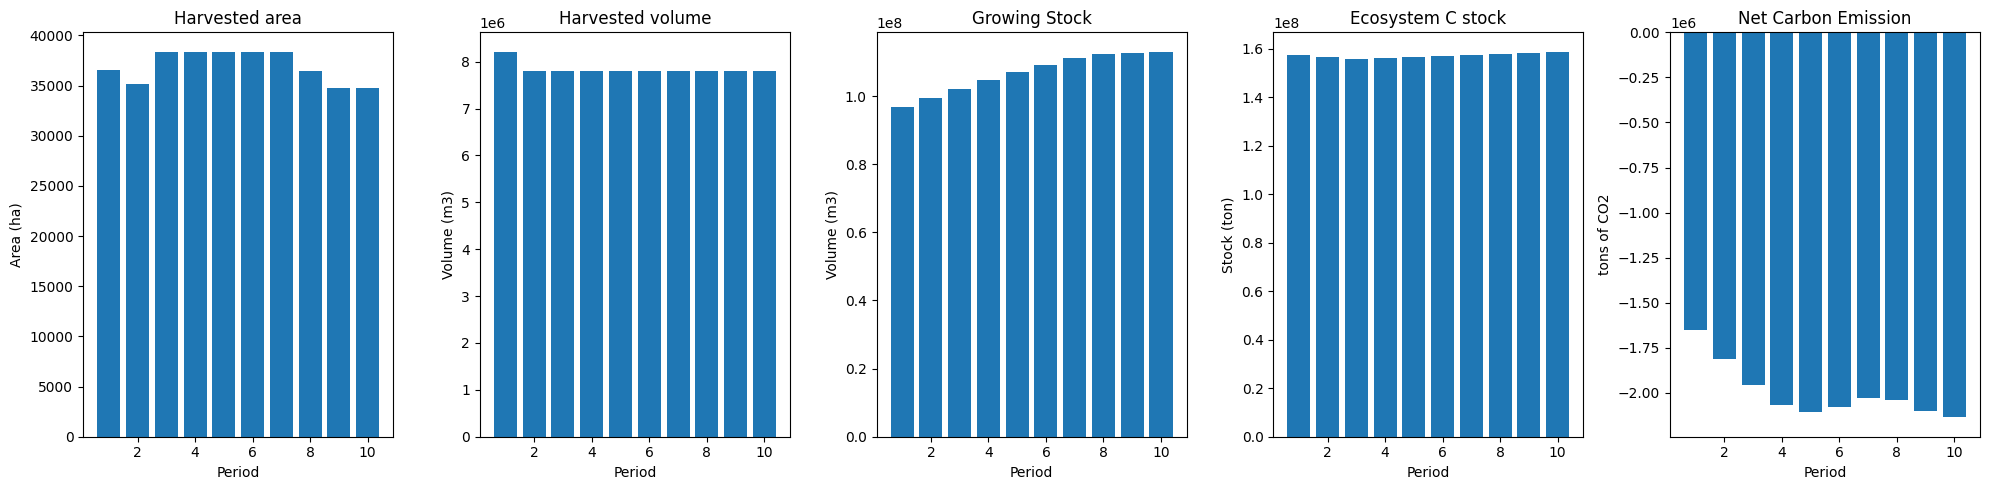

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_90%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  82941
The economic indicator (the provincial government revenues) is:  2828481
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


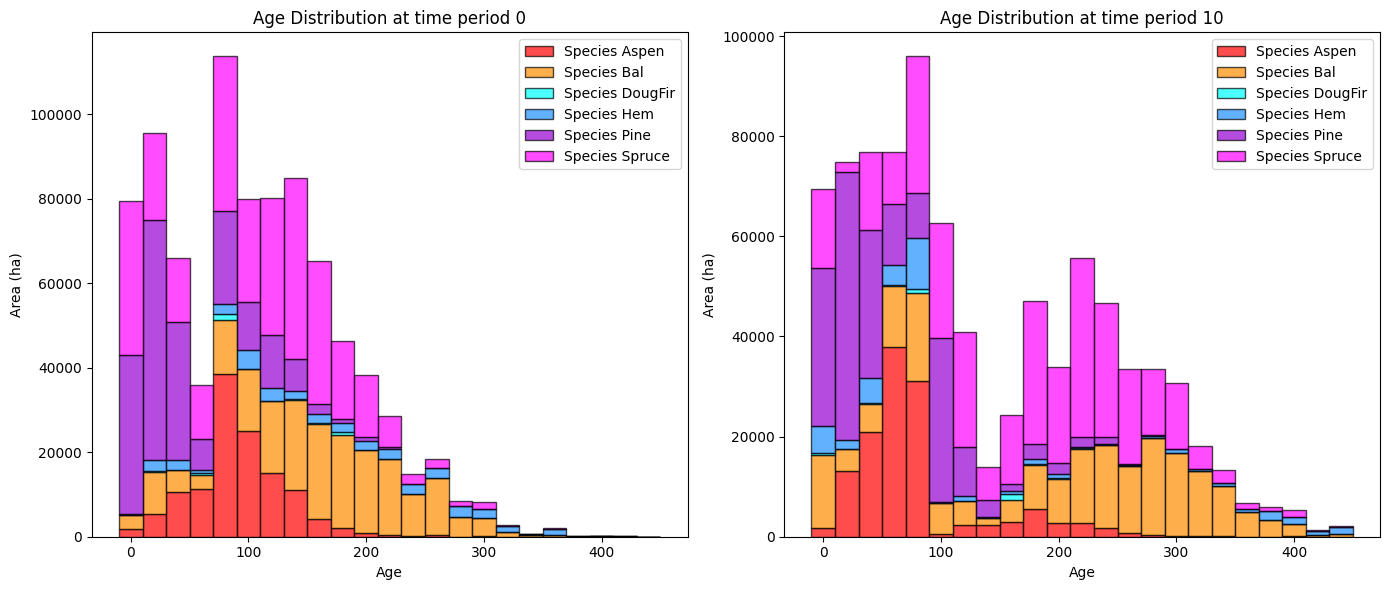

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_90%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   10144.135171   -9007.992058
DougFir    947.047810    1480.701453     533.653643
Bal      59315.970469  114545.020735   55229.050266
Spruce   36410.744598  156626.986855  120216.242257
Aspen    29632.731169   20687.801119   -8944.930050
Pine      7432.733686   10444.287924    3011.554238

Overall diversity has **increased** by 161037.58 hectares from time period 0 to time period 10.


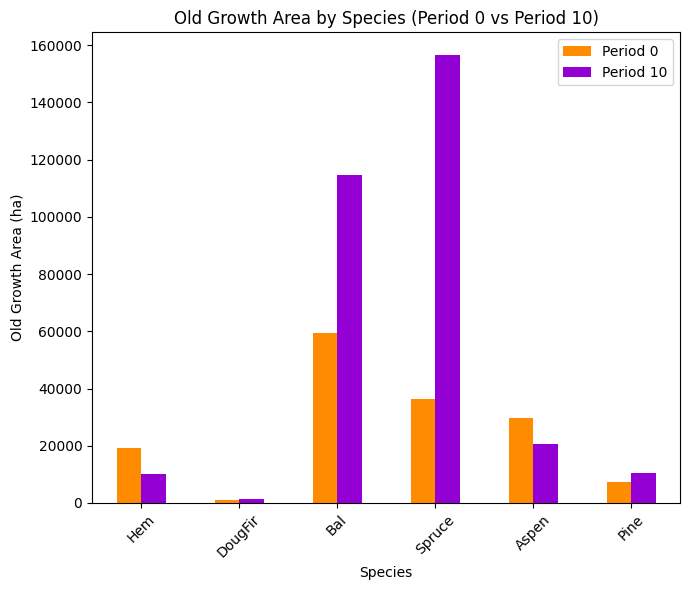

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_90%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7199

Diversity has **decreased** by 3.93% from time 0 to time 10.


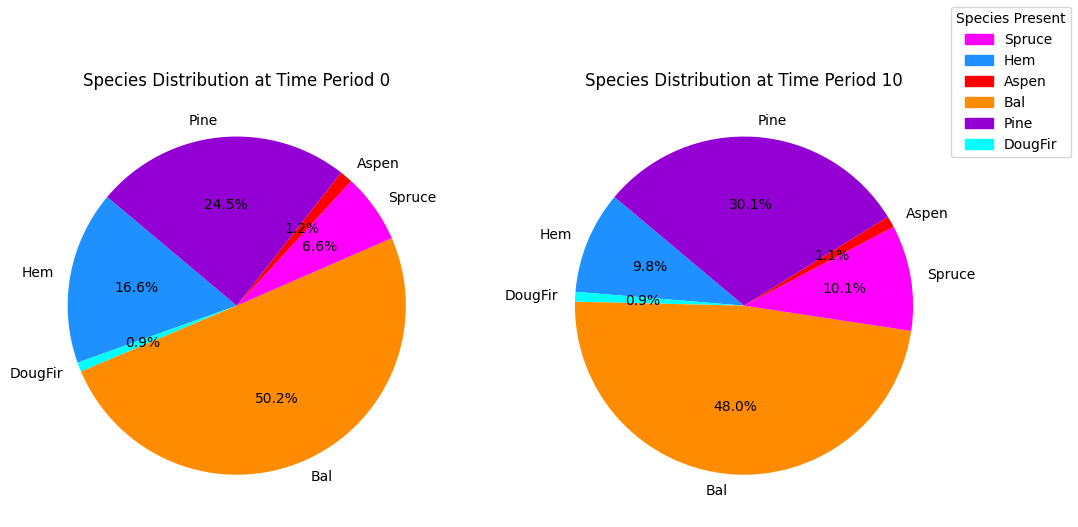

Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.28s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.01s

Barrier statistics:
 AA' NZ     : 2.583e+05
 Factor NZ  : 3.385e+05 (roughly 36 MB of memory)
 Factor Ops : 1.590e+07 (less than 1 second per iteration)
 Threads    : 14

   

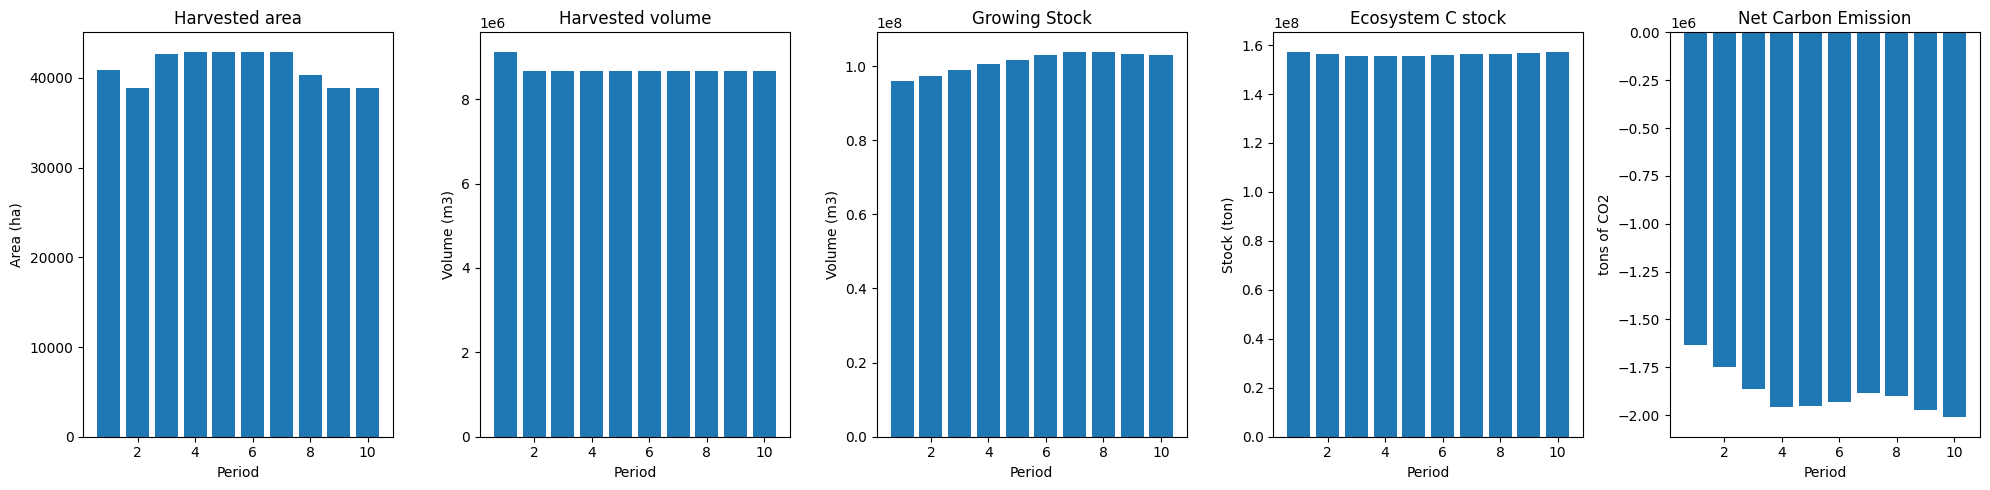

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


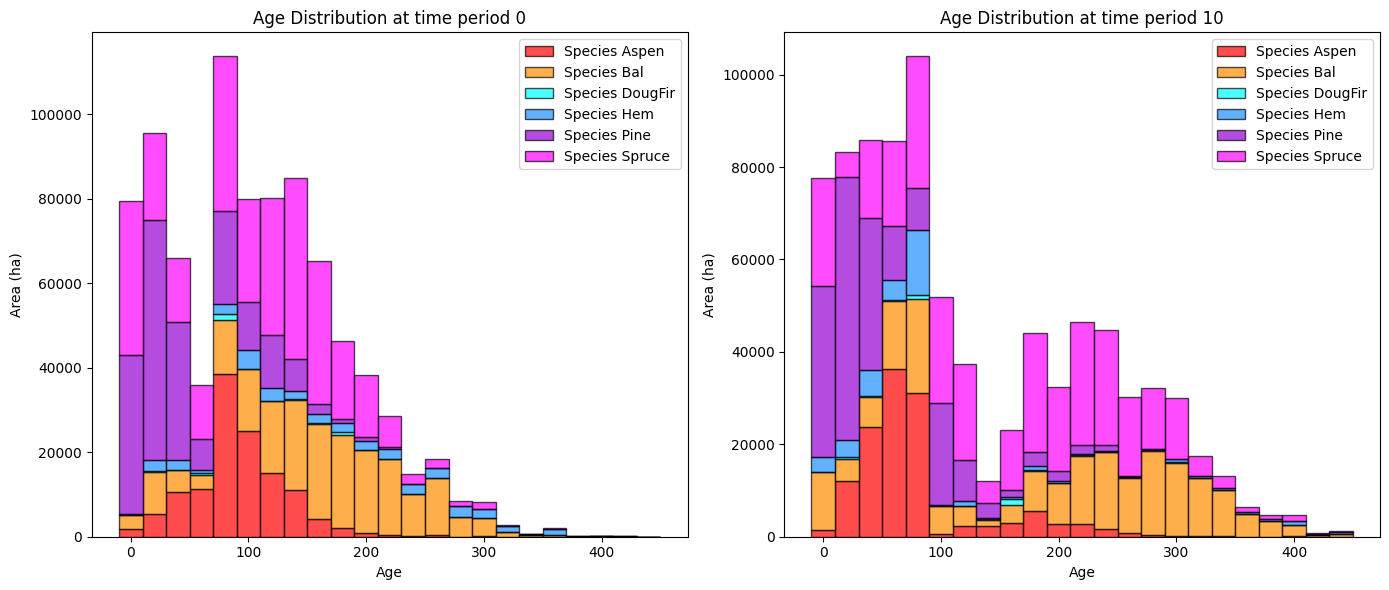

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


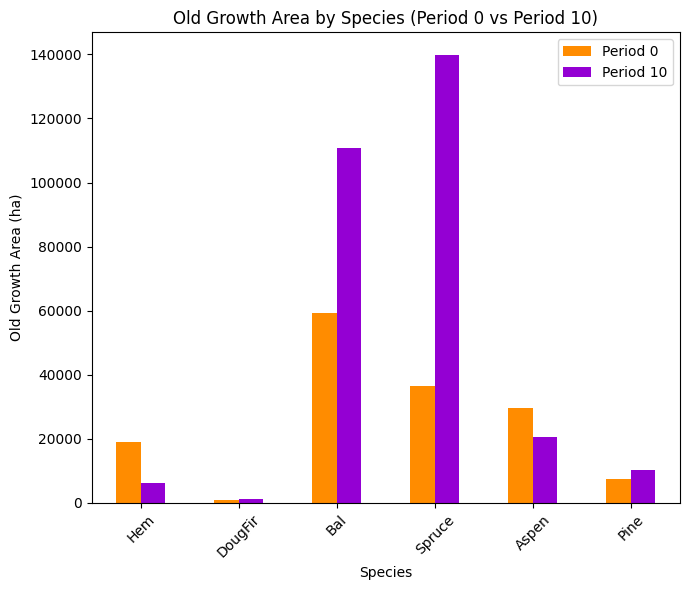

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


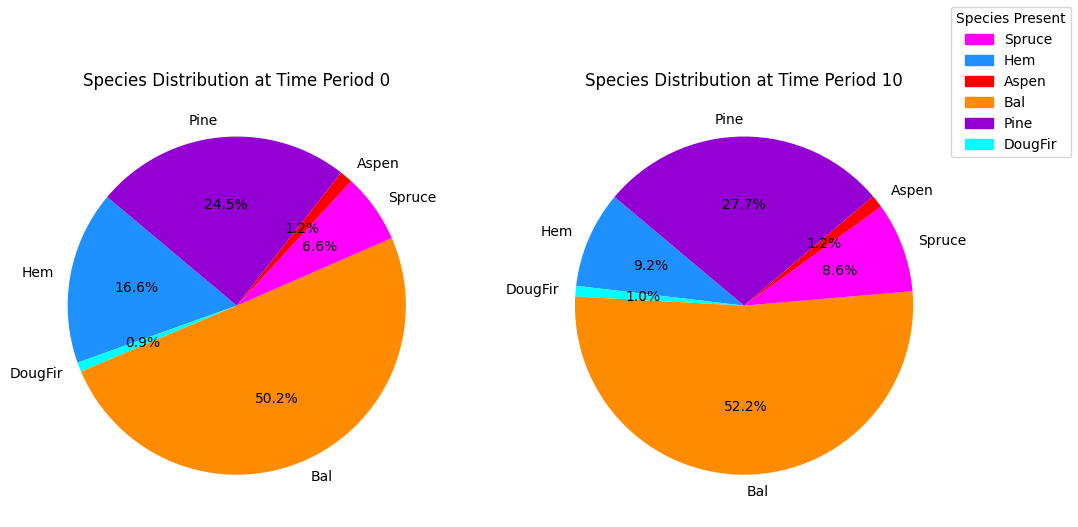

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


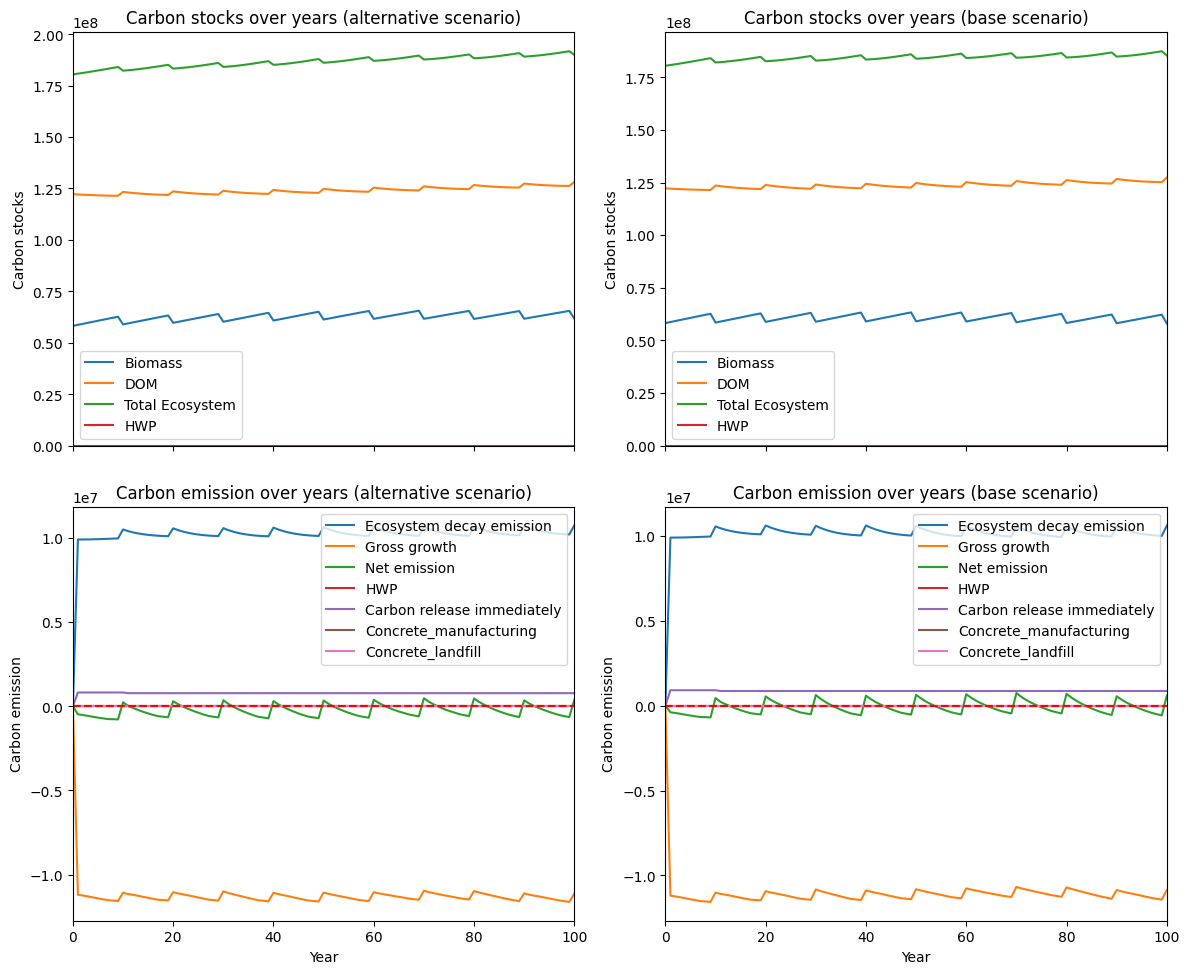

---------------------------------------------------------------------------------------
Net emission difference -3551118.1591683375
Net emission base scenario -9203210.088700745
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  2.8160144359550046
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   3864.578879   3864.578879
DougFir  0.0    121.580191    121.580191
Bal      0.0   3653.649444   3653.649444
Spruce   0.0  16747.176420  16747.176420
Aspen    0.0     -1.726849     -1.726849
Pine     0.0    259.079881    259.079881

Overall, the old growth area has **increased** by 24644.34 hectares in the alternative scenario compared to the base scenario.


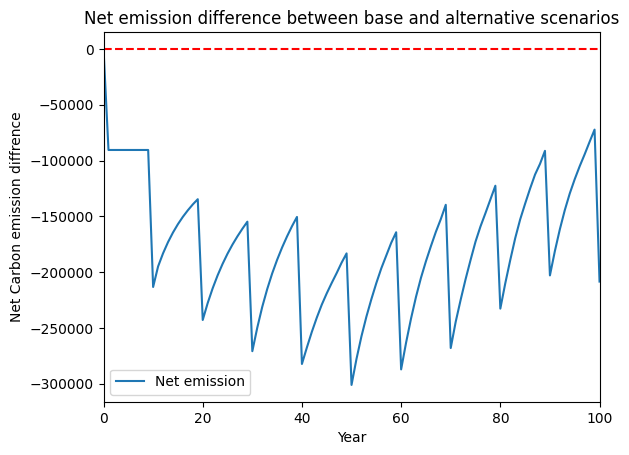

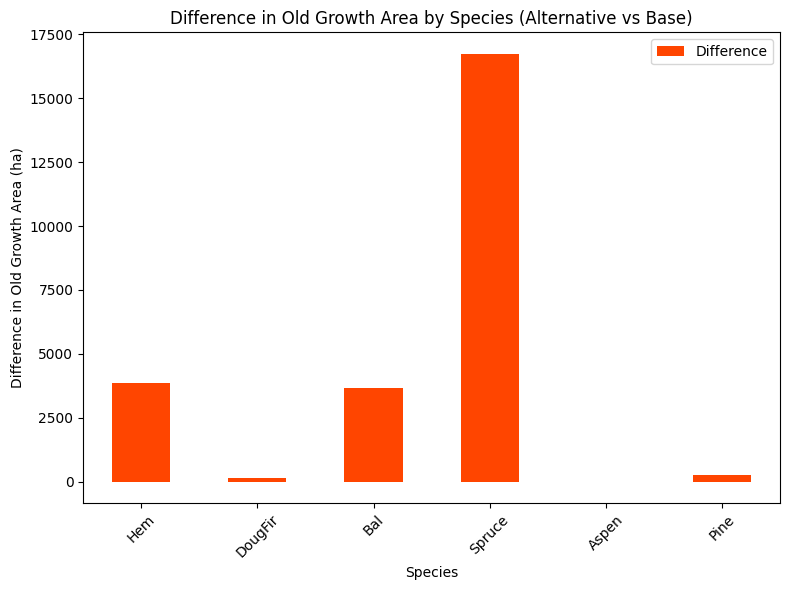

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


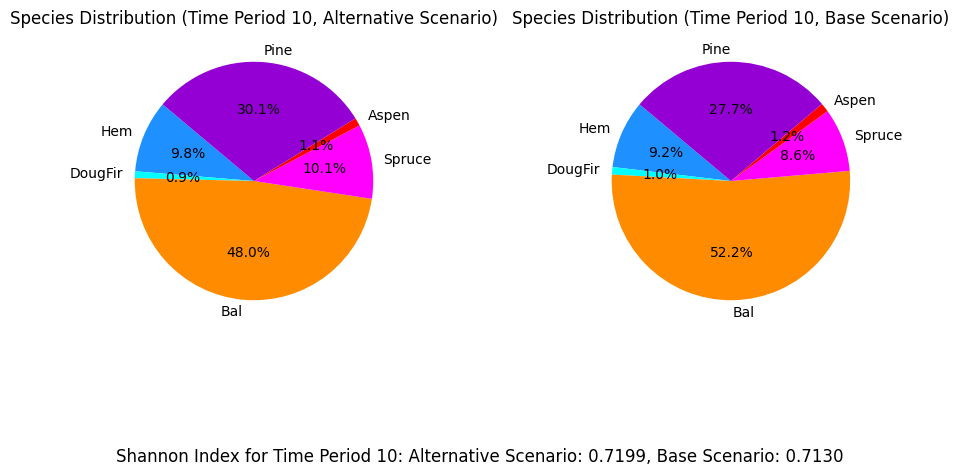

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_eqtslvr_AAC_80%...
running the scenario for the Equity Silver mining site (80%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xddb1730f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.29s
Presolved: 8375 r

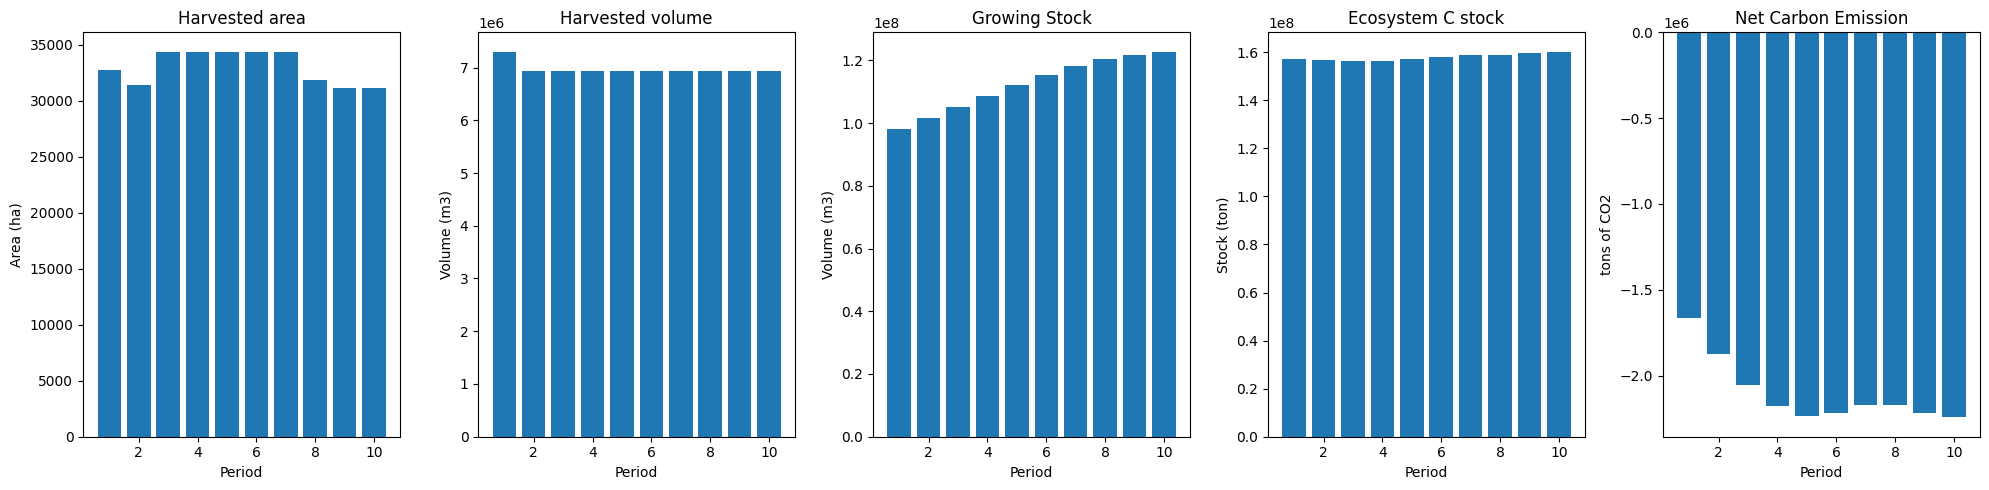

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_80%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  73725
The economic indicator (the provincial government revenues) is:  2514205
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


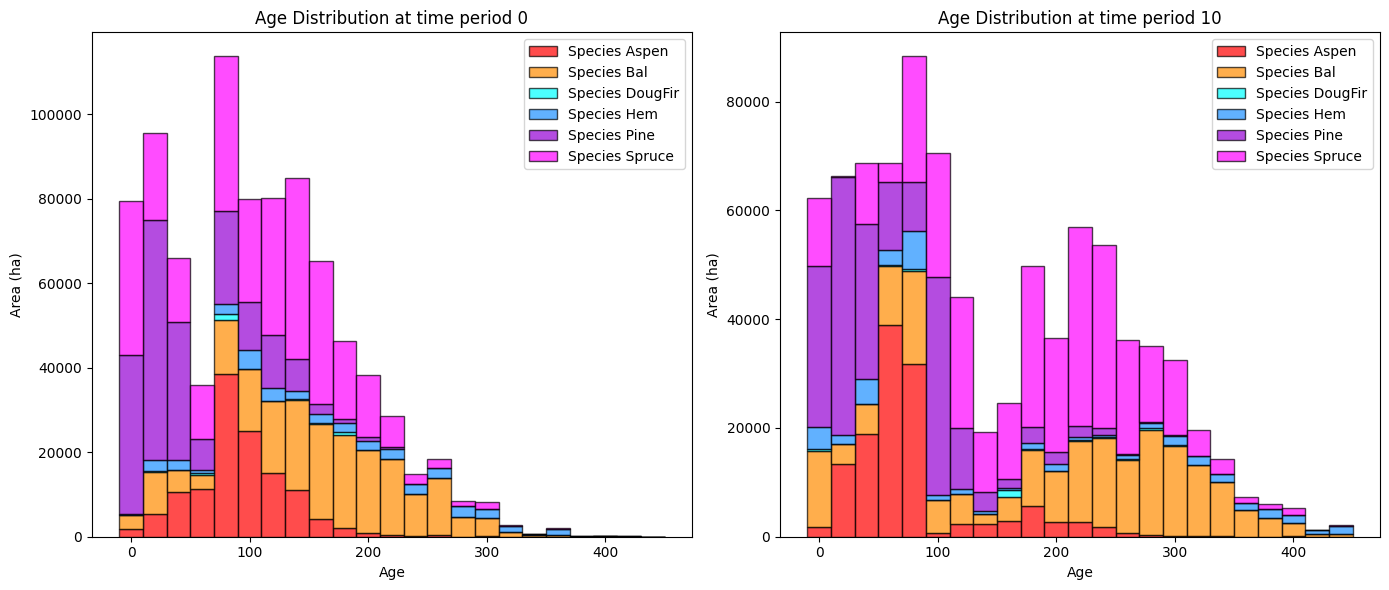

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_80%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   15833.180578   -3318.946651
DougFir    947.047810    1952.827102    1005.779292
Bal      59315.970469  115254.782873   55938.812404
Spruce   36410.744598  172198.126174  135787.381576
Aspen    29632.731169   20688.379011   -8944.352158
Pine      7432.733686   10518.651102    3085.917416

Overall diversity has **increased** by 183554.59 hectares from time period 0 to time period 10.


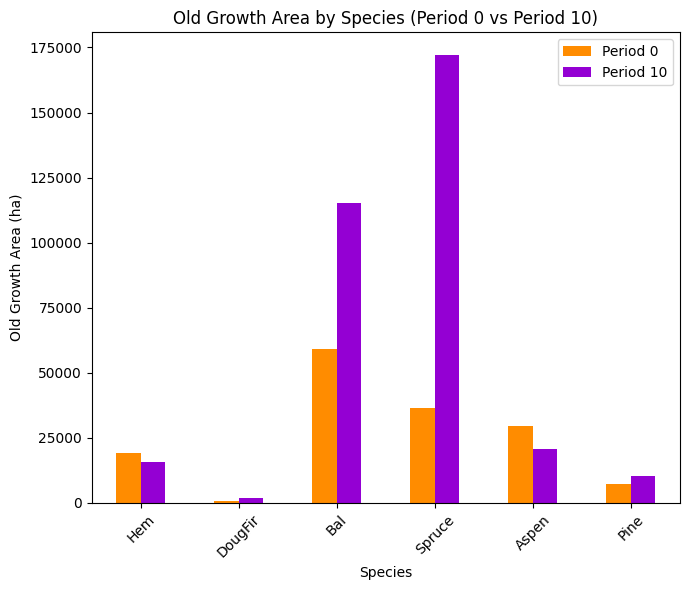

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_80%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7209

Diversity has **decreased** by 3.82% from time 0 to time 10.


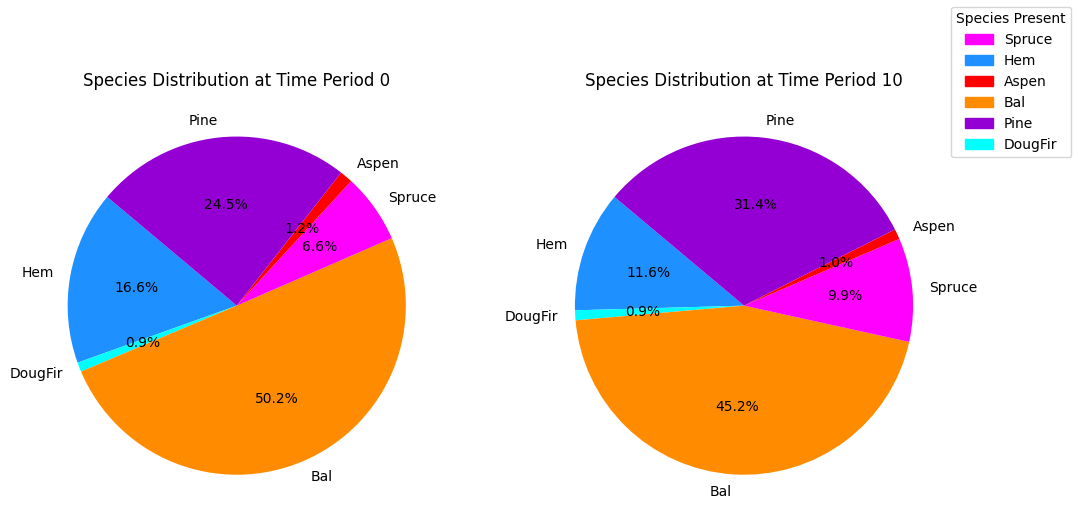

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_80%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.26s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

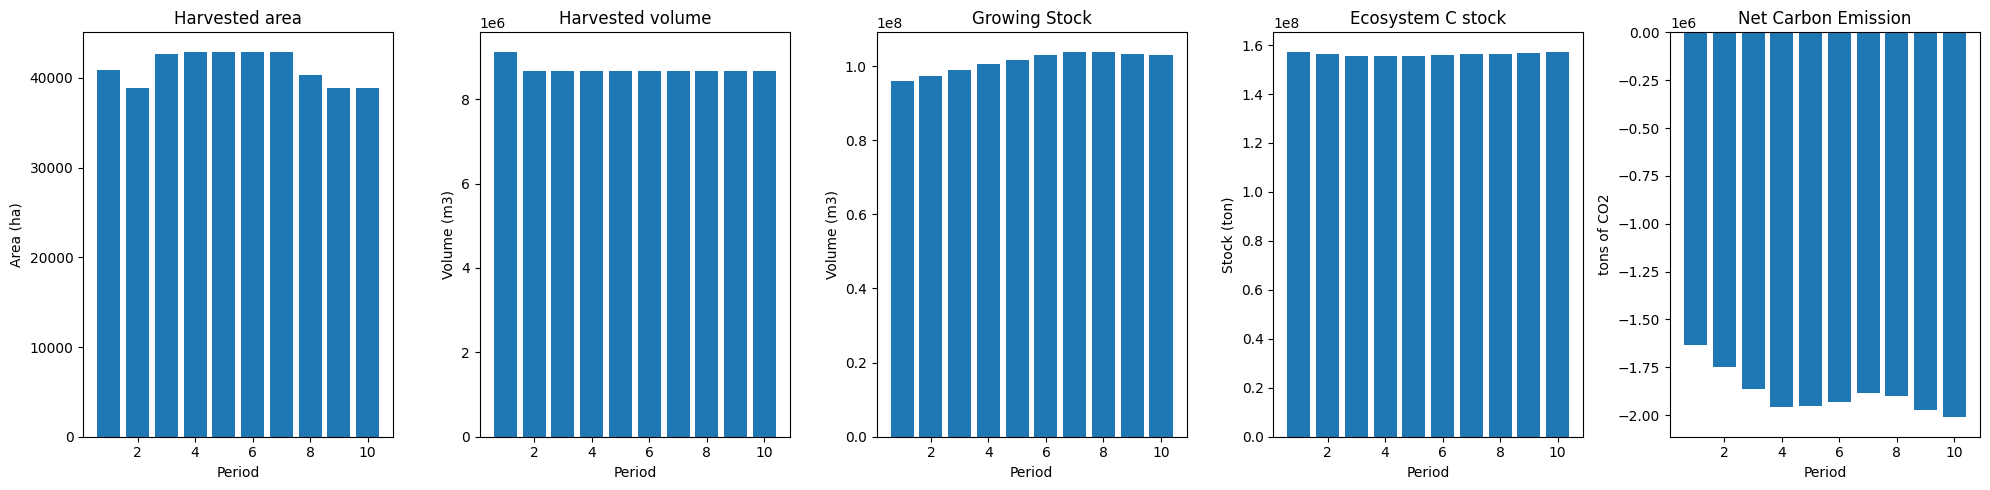

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


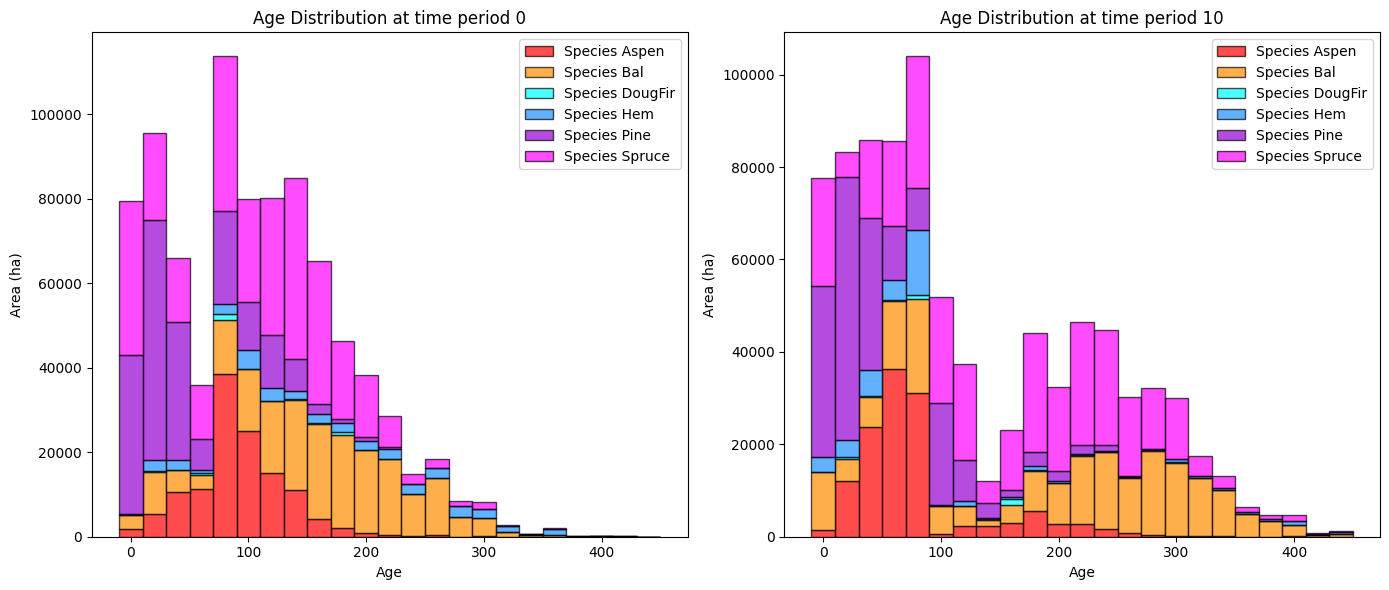

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


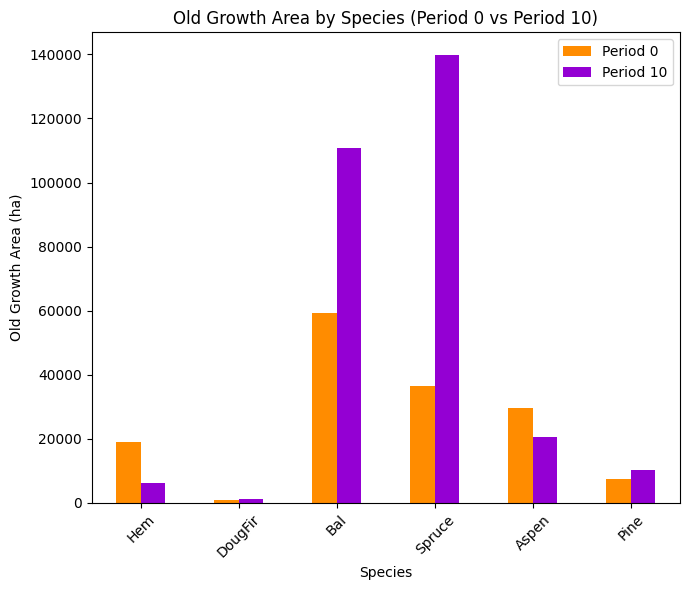

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


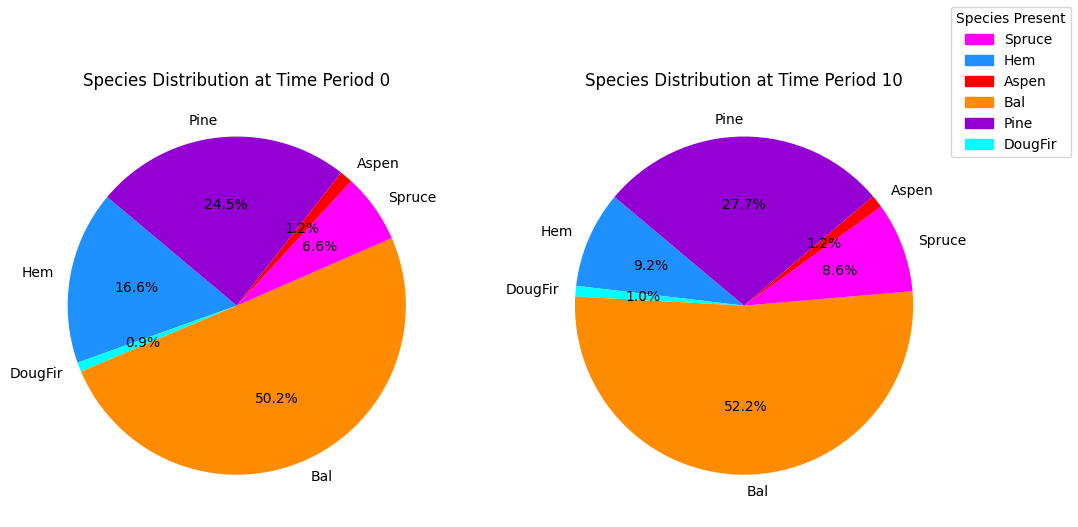

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


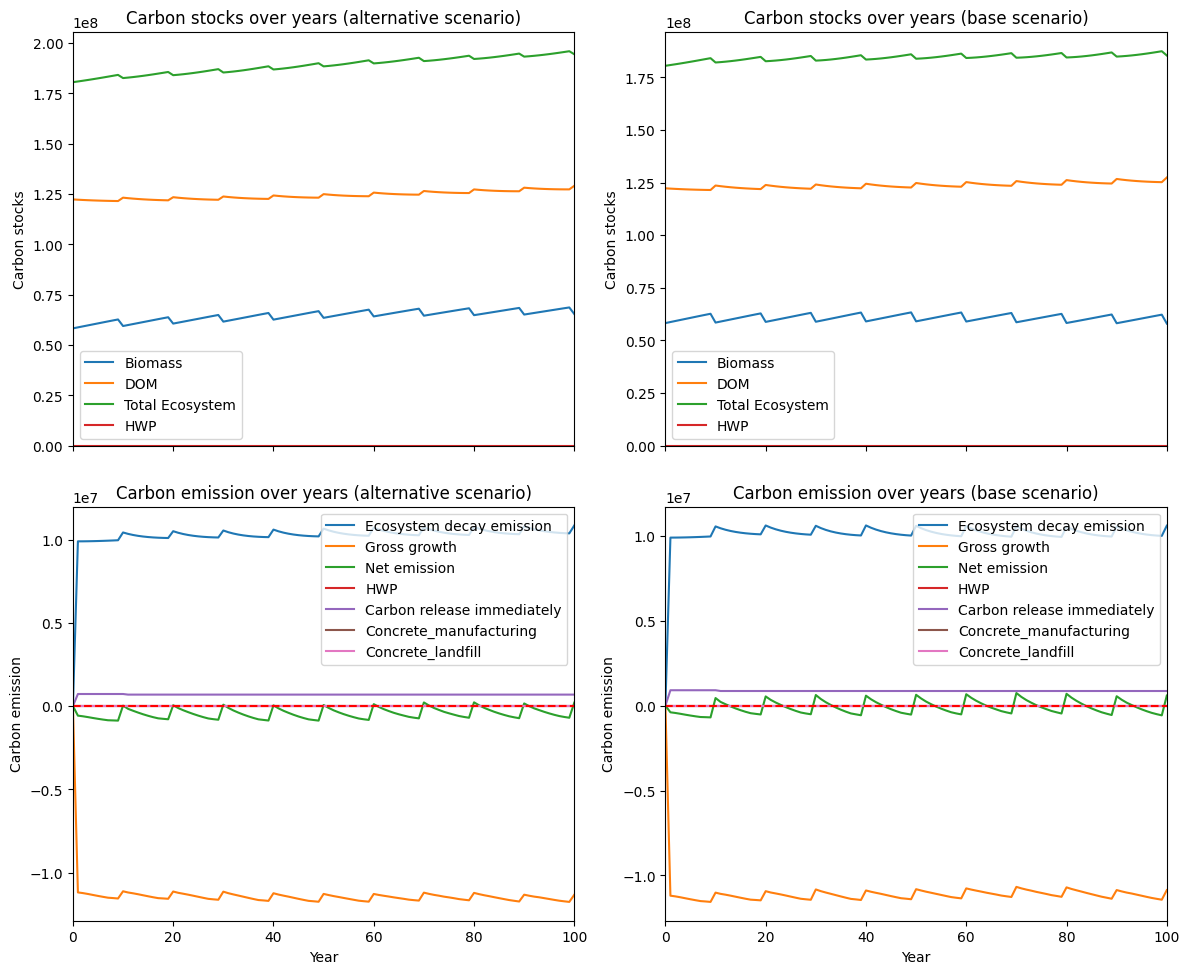

---------------------------------------------------------------------------------------
Net emission difference -7102016.179938556
Net emission base scenario -12754108.109470963
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  1.4080508614226386
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0   9553.624286   9553.624286
DougFir  0.0    593.705839    593.705839
Bal      0.0   4363.411582   4363.411582
Spruce   0.0  32318.315740  32318.315740
Aspen    0.0     -1.148957     -1.148957
Pine     0.0    333.443060    333.443060

Overall, the old growth area has **increased** by 47161.35 hectares in the alternative scenario compared to the base scenario.


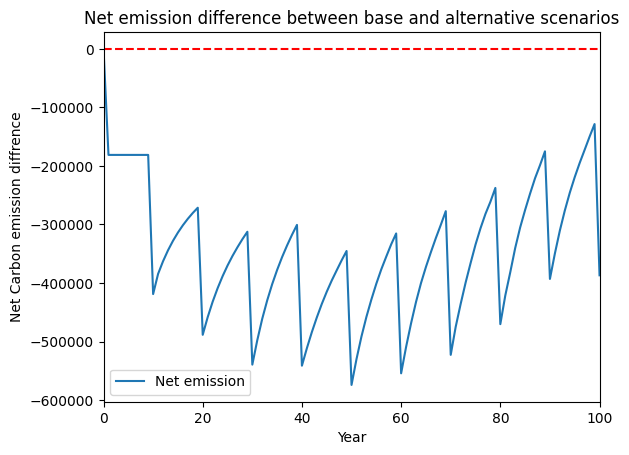

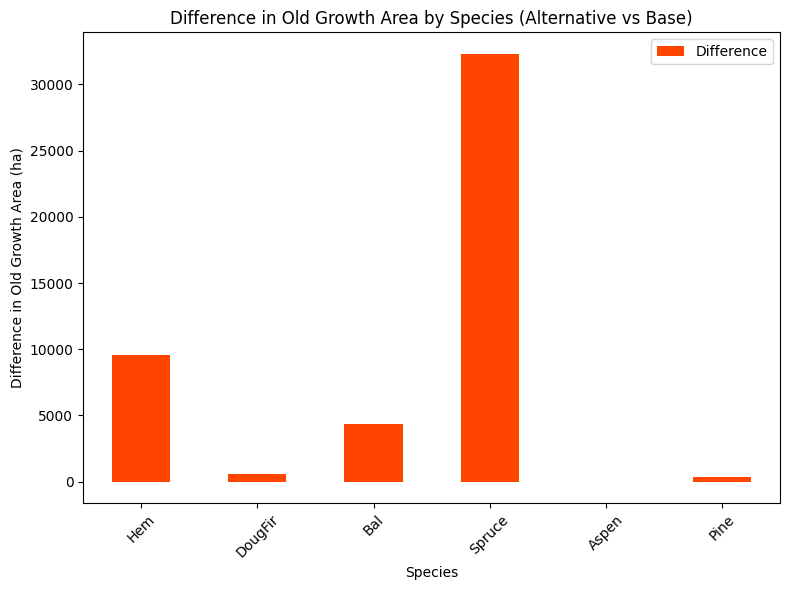

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


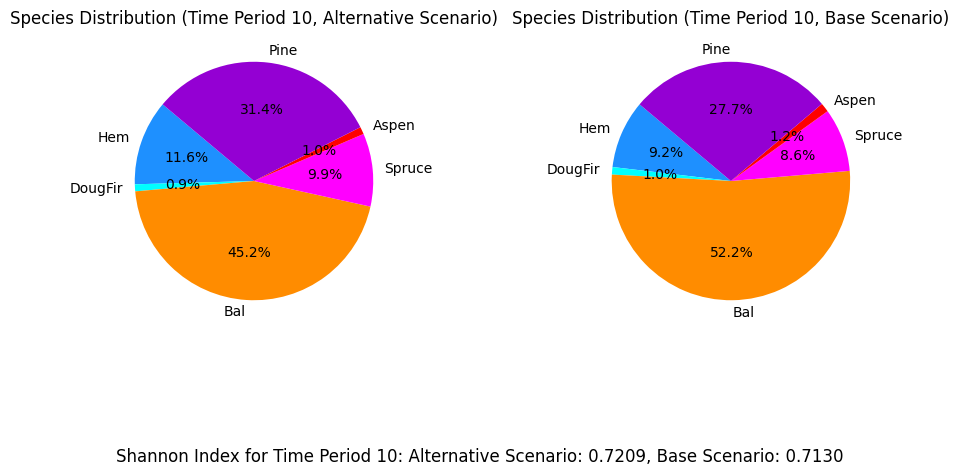

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_eqtslvr_AAC_70%...
running the scenario for the Equity Silver mining site (70%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x3046cd56
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.25s
Presolved: 8375 r

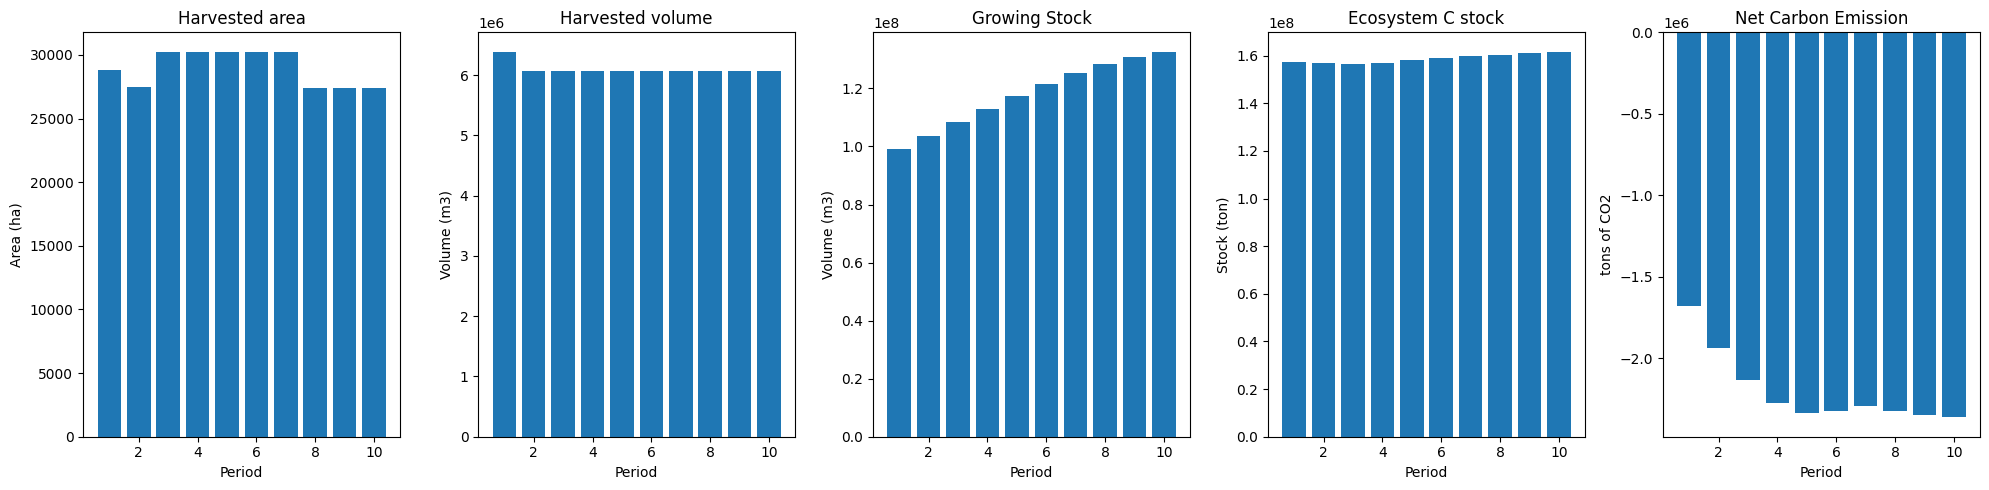

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_70%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  64510
The economic indicator (the provincial government revenues) is:  2199929
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


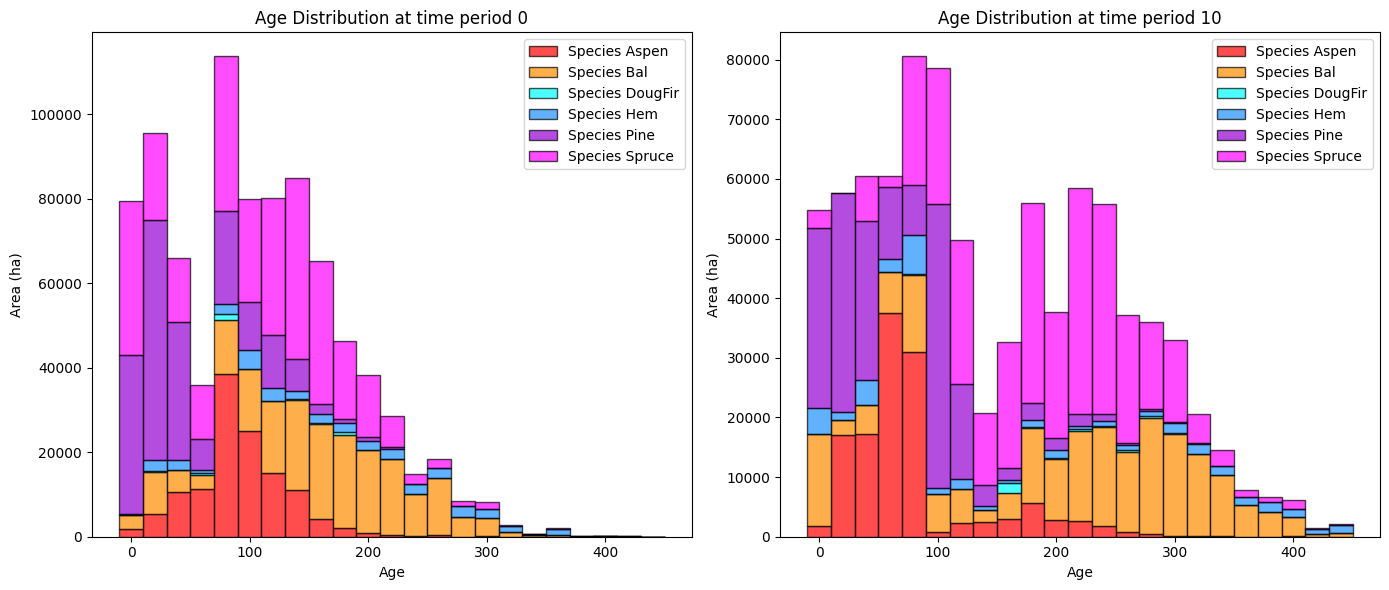

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_70%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   16492.455595   -2659.671634
DougFir    947.047810    2607.841586    1660.793776
Bal      59315.970469  121160.775316   61844.804848
Spruce   36410.744598  184453.007924  148042.263326
Aspen    29632.731169   20696.112662   -8936.618507
Pine      7432.733686   11782.462892    4349.729206

Overall diversity has **increased** by 204301.30 hectares from time period 0 to time period 10.


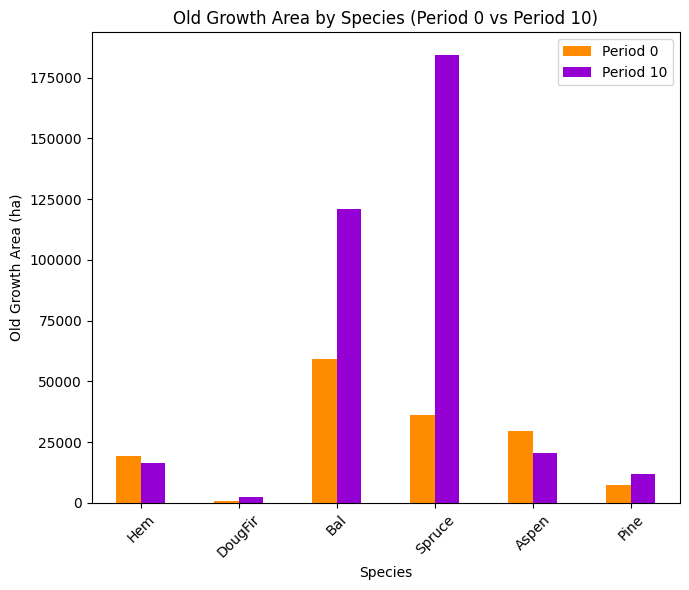

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_70%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7161

Diversity has **decreased** by 4.31% from time 0 to time 10.


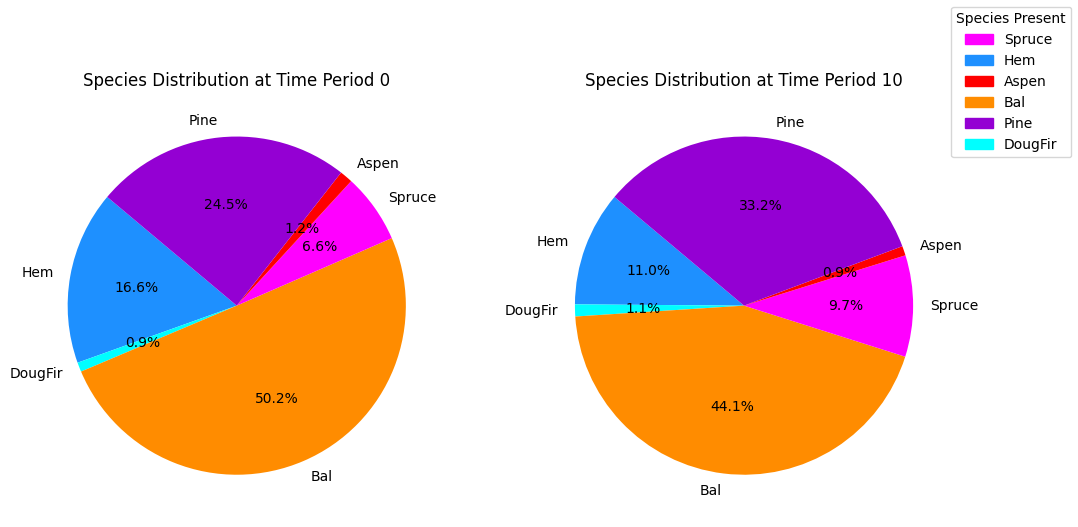

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_70%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.24s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

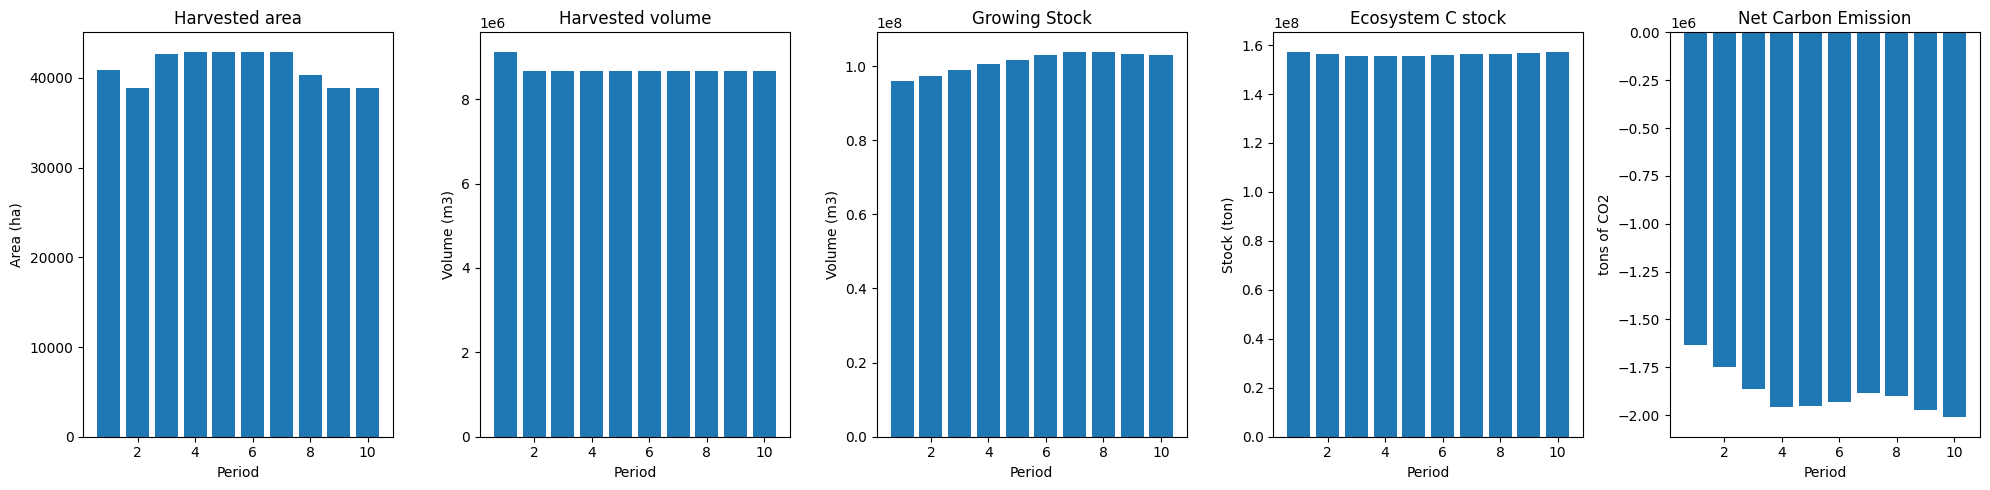

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


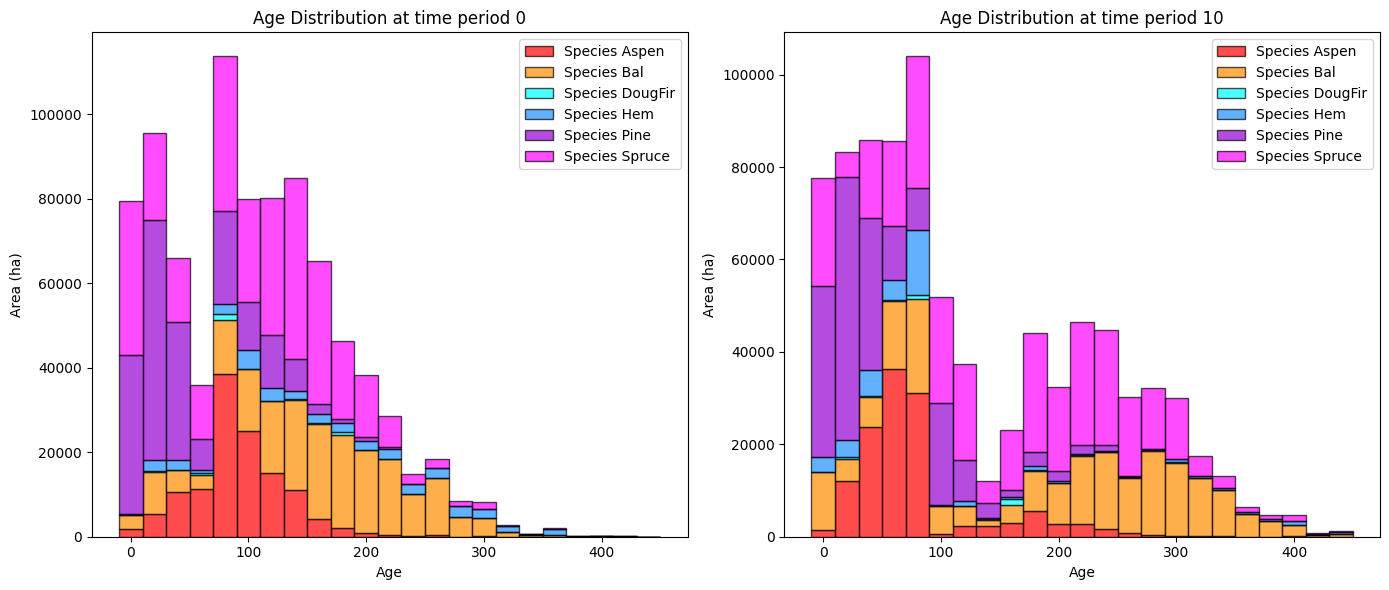

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


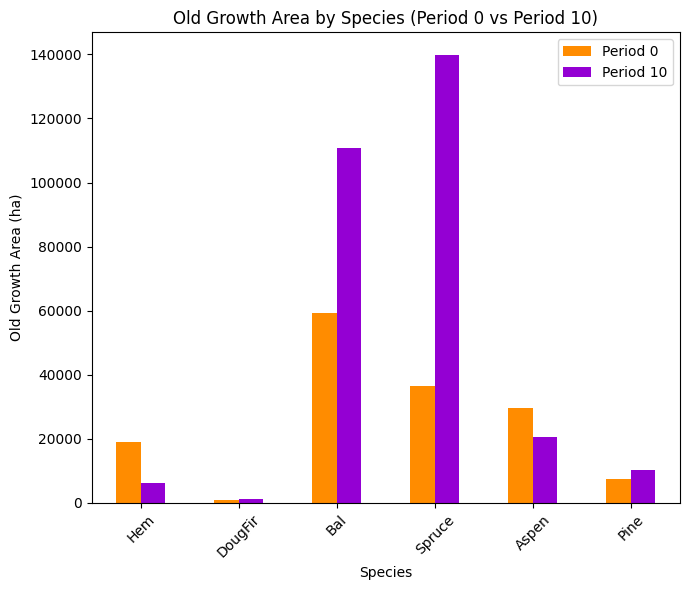

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


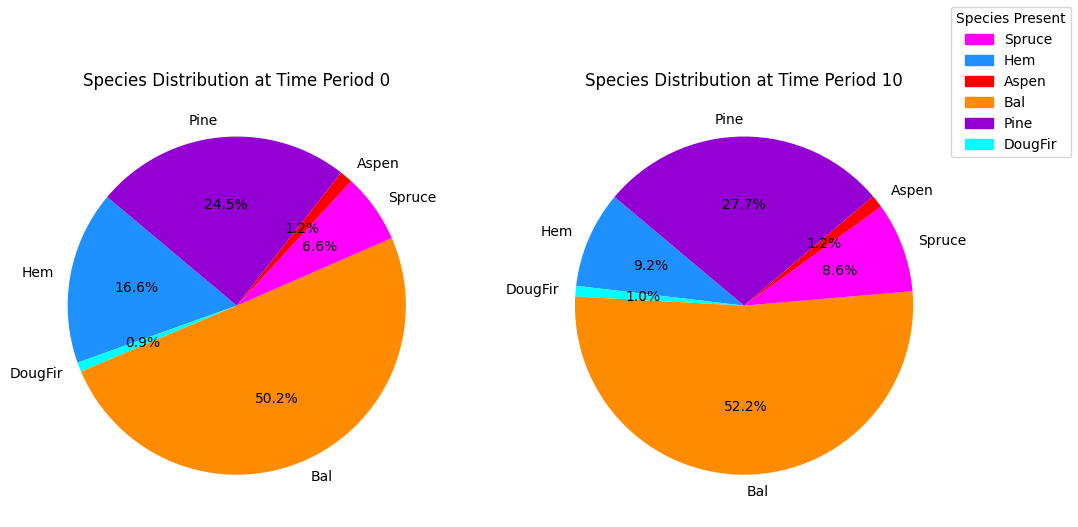

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


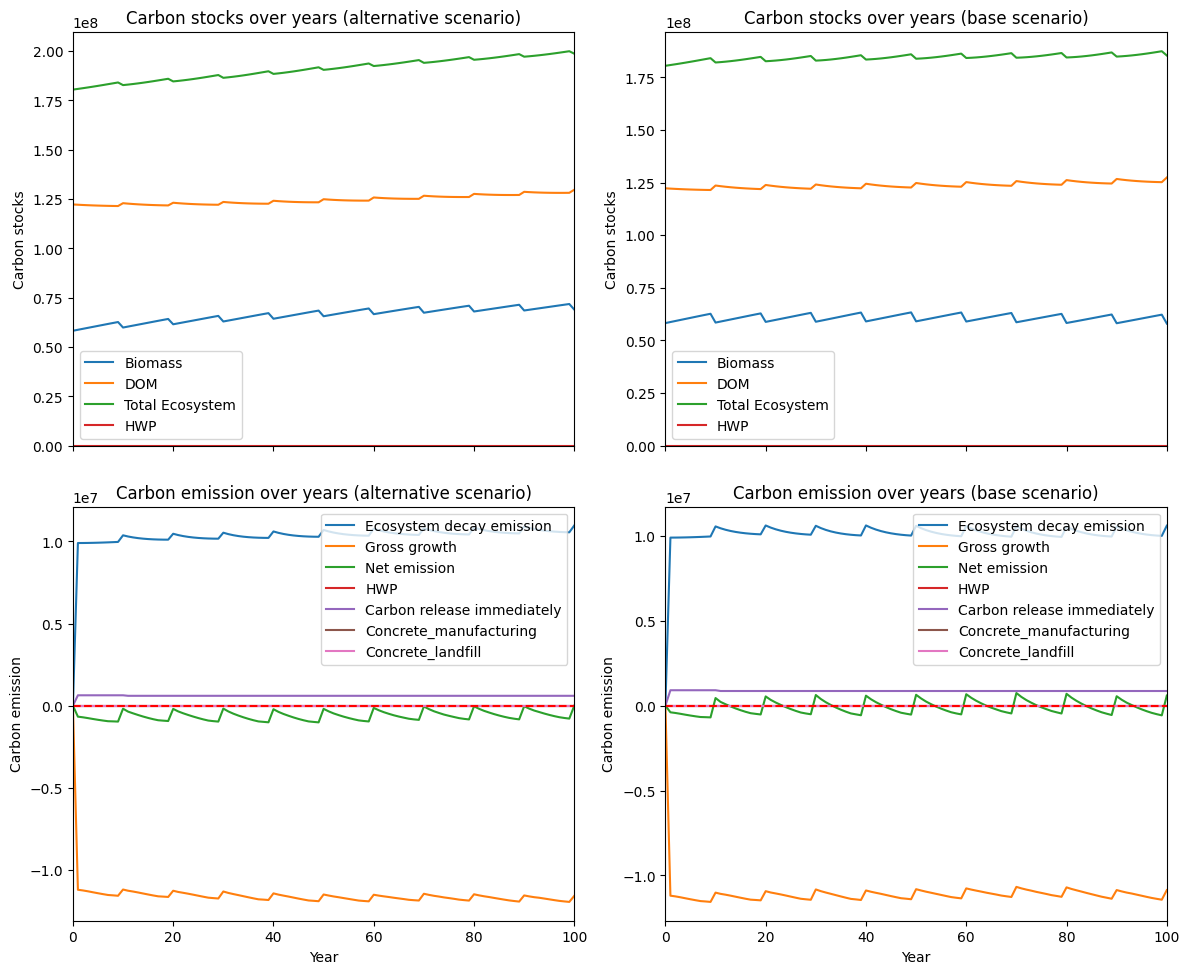

---------------------------------------------------------------------------------------
Net emission difference -10644015.995256633
Net emission base scenario -16296107.92478904
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  0.9394950180886961
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  10212.899303  10212.899303
DougFir  0.0   1248.720324   1248.720324
Bal      0.0  10269.404025  10269.404025
Spruce   0.0  44573.197489  44573.197489
Aspen    0.0      6.584695      6.584695
Pine     0.0   1597.254849   1597.254849

Overall, the old growth area has **increased** by 67908.06 hectares in the alternative scenario compared to the base scenario.


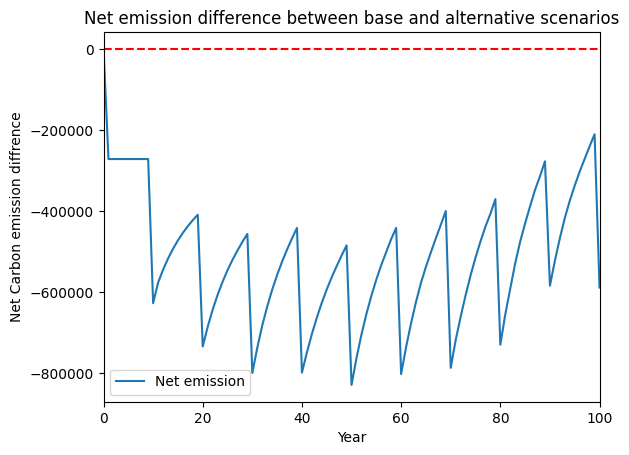

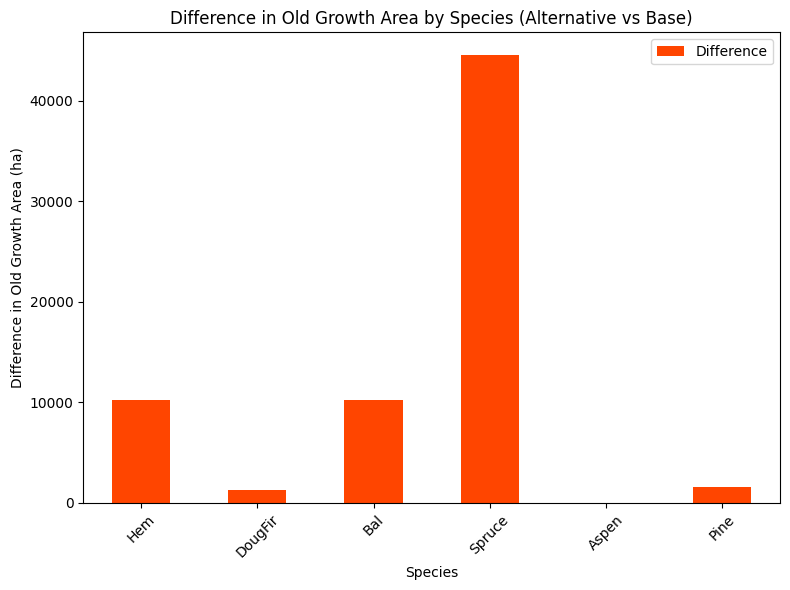

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


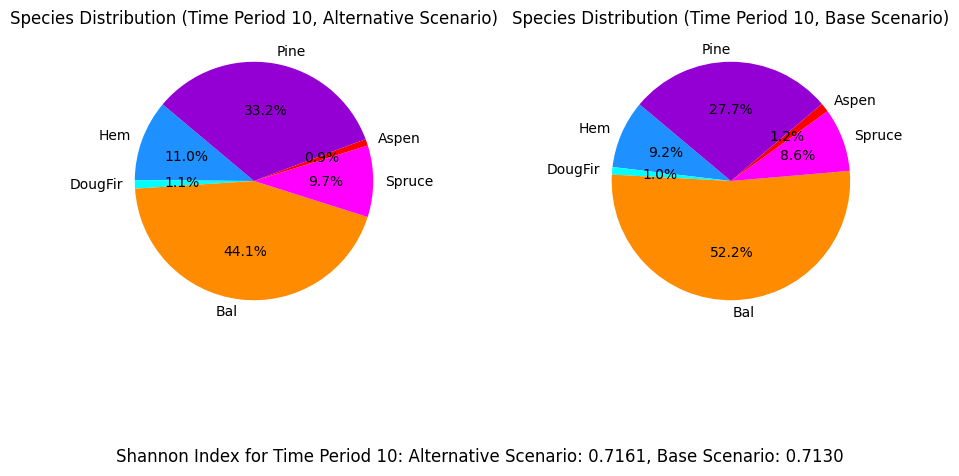

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_eqtslvr_AAC_60%...
running the scenario for the Equity Silver mining site (60%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x6be7a9f5
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.29s
Presolved: 8375 r

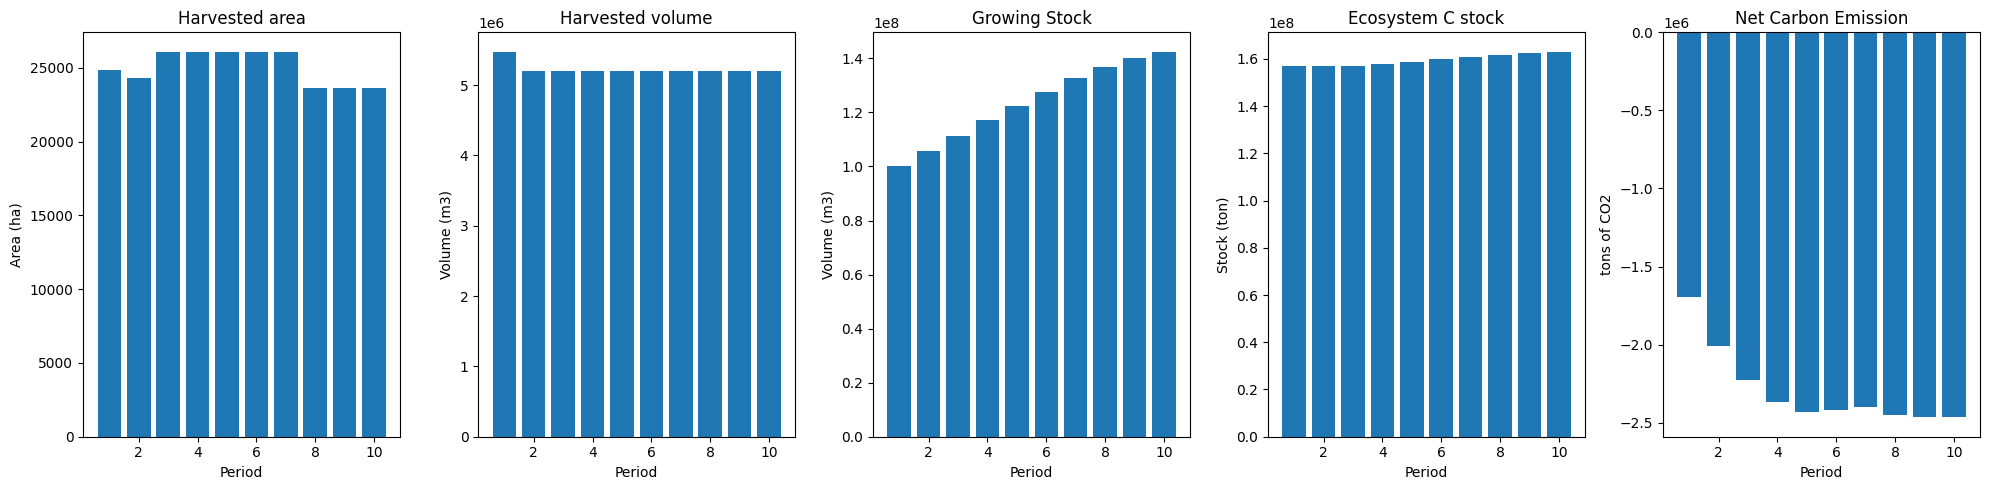

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_60%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  55294
The economic indicator (the provincial government revenues) is:  1885654
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


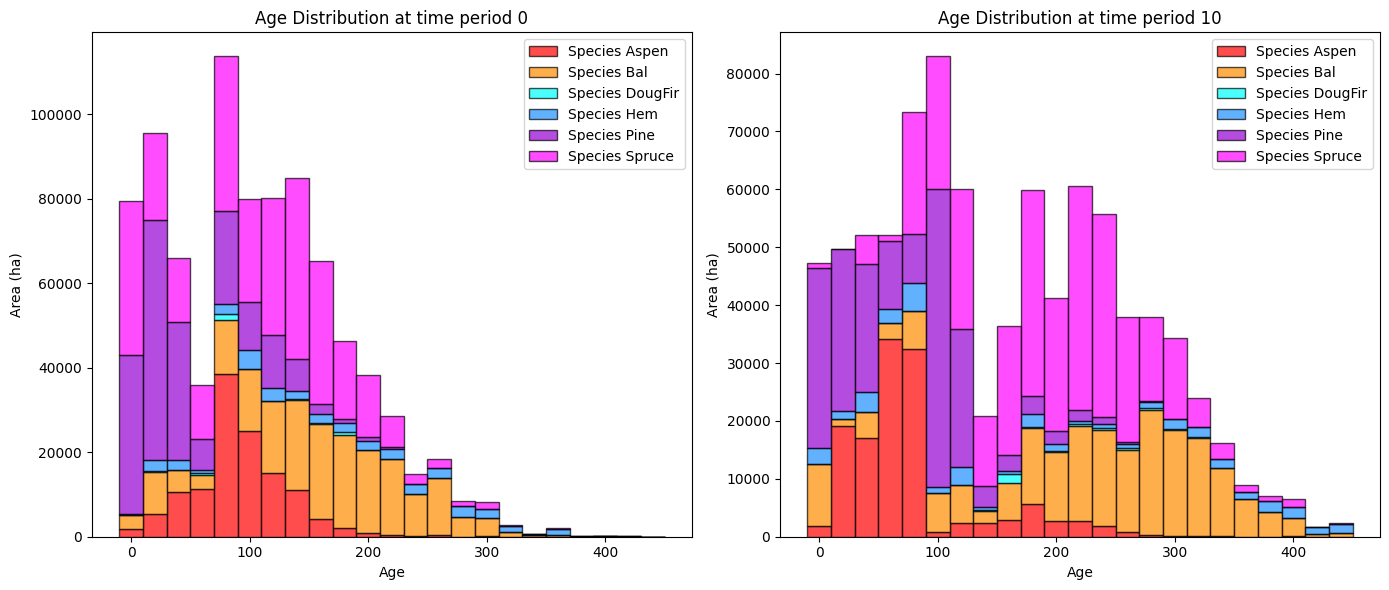

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_60%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   18893.488964    -258.638264
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  135093.471008   75777.500540
Spruce   36410.744598  189884.474053  153473.729455
Aspen    29632.731169   20706.791225   -8925.939944
Pine      7432.733686   14059.813854    6627.080168

Overall diversity has **increased** by 228495.98 hectares from time period 0 to time period 10.


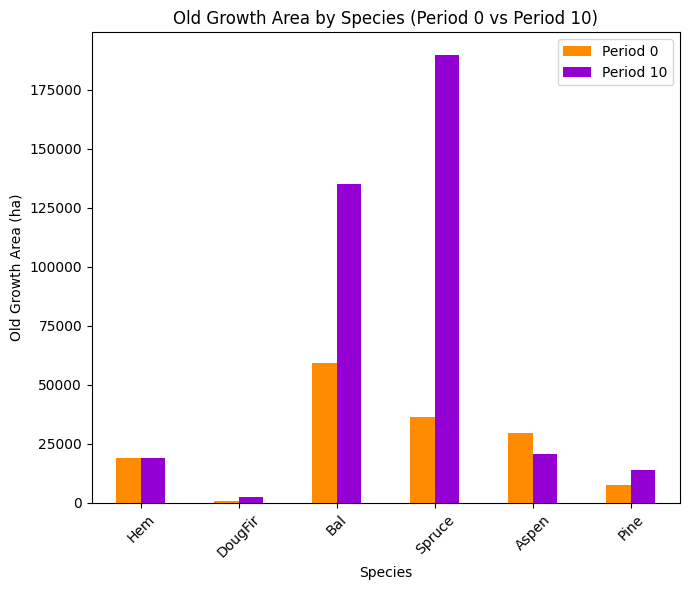

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_60%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7182

Diversity has **decreased** by 4.09% from time 0 to time 10.


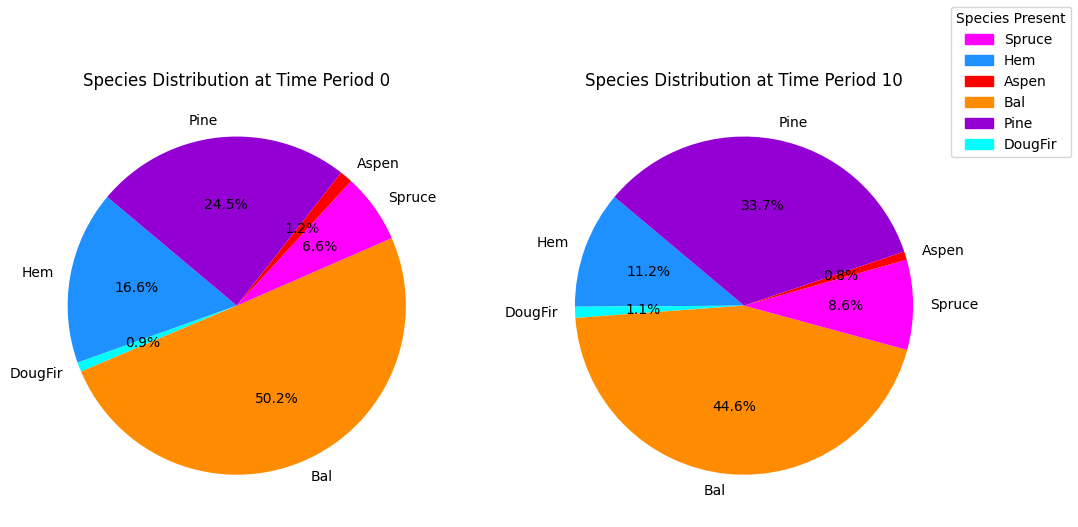

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_60%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.26s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

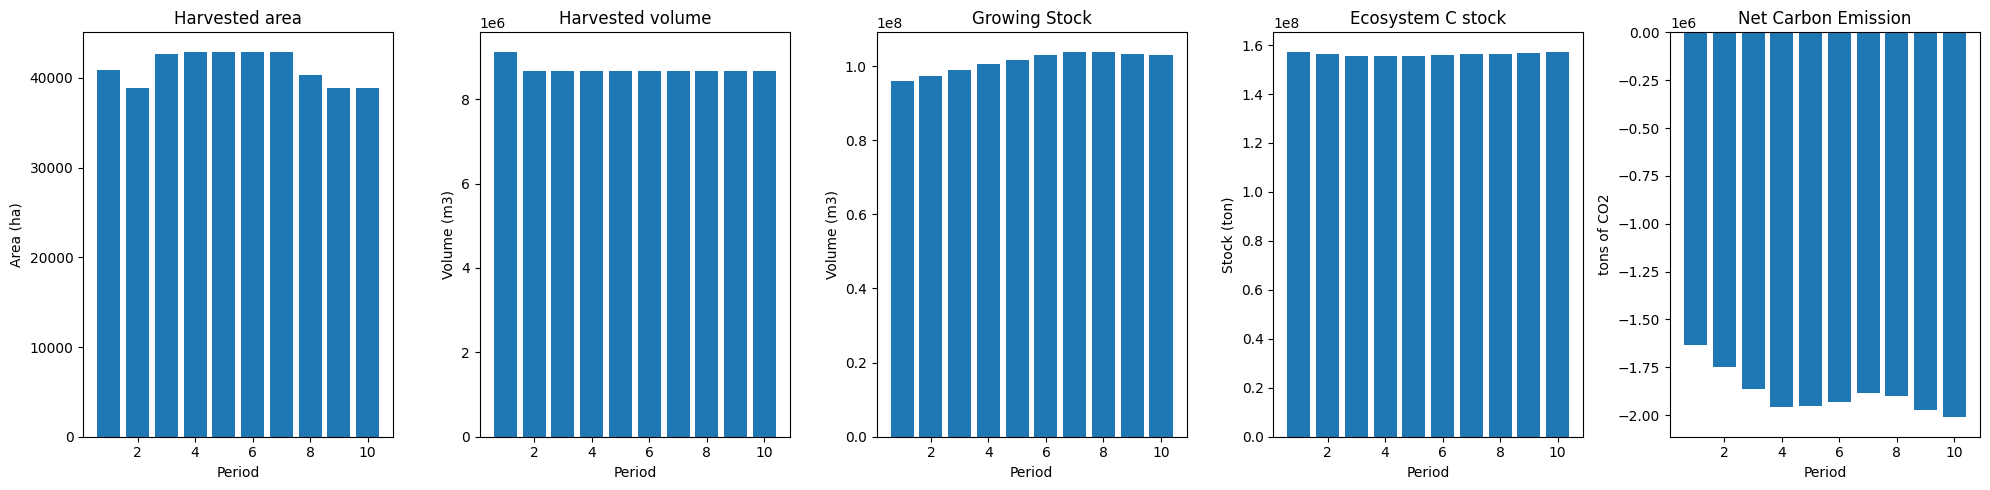

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


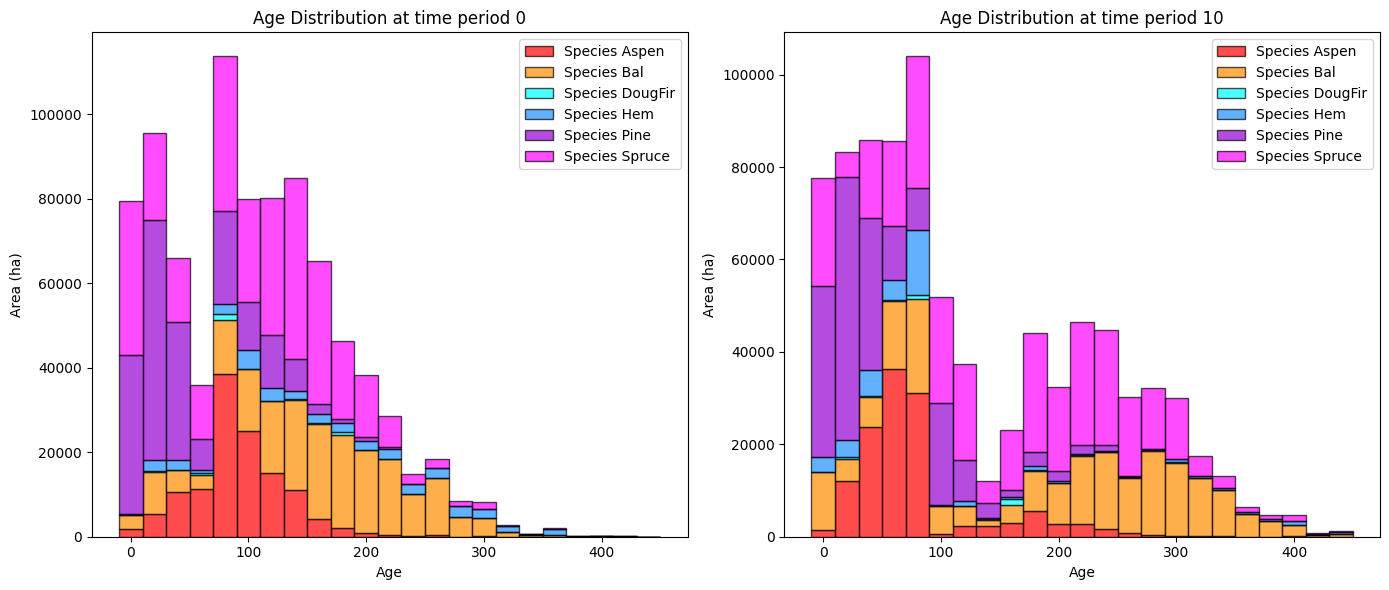

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


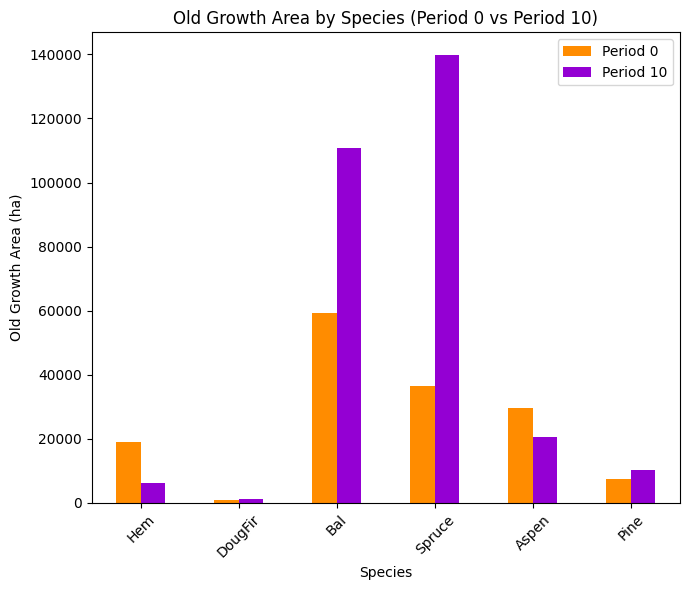

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


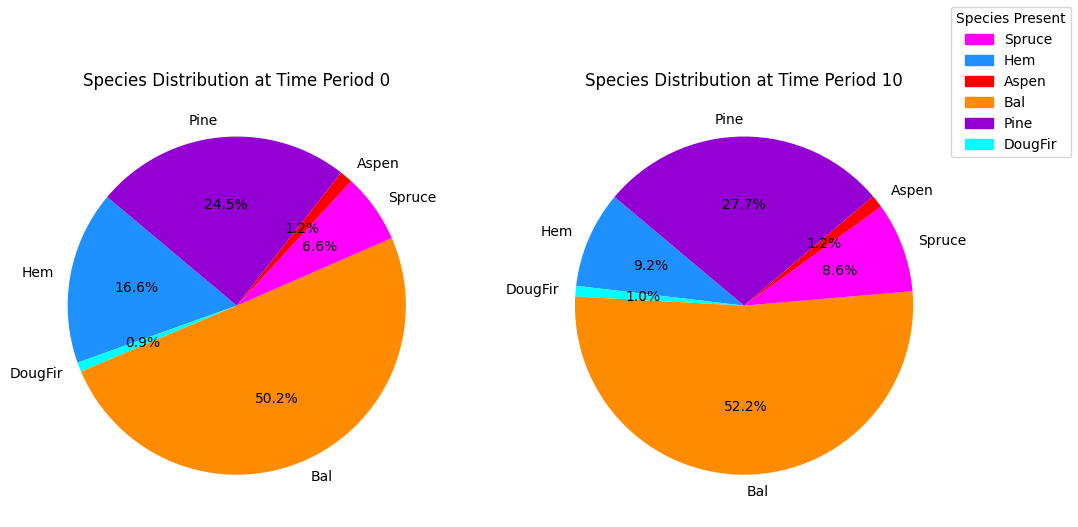

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


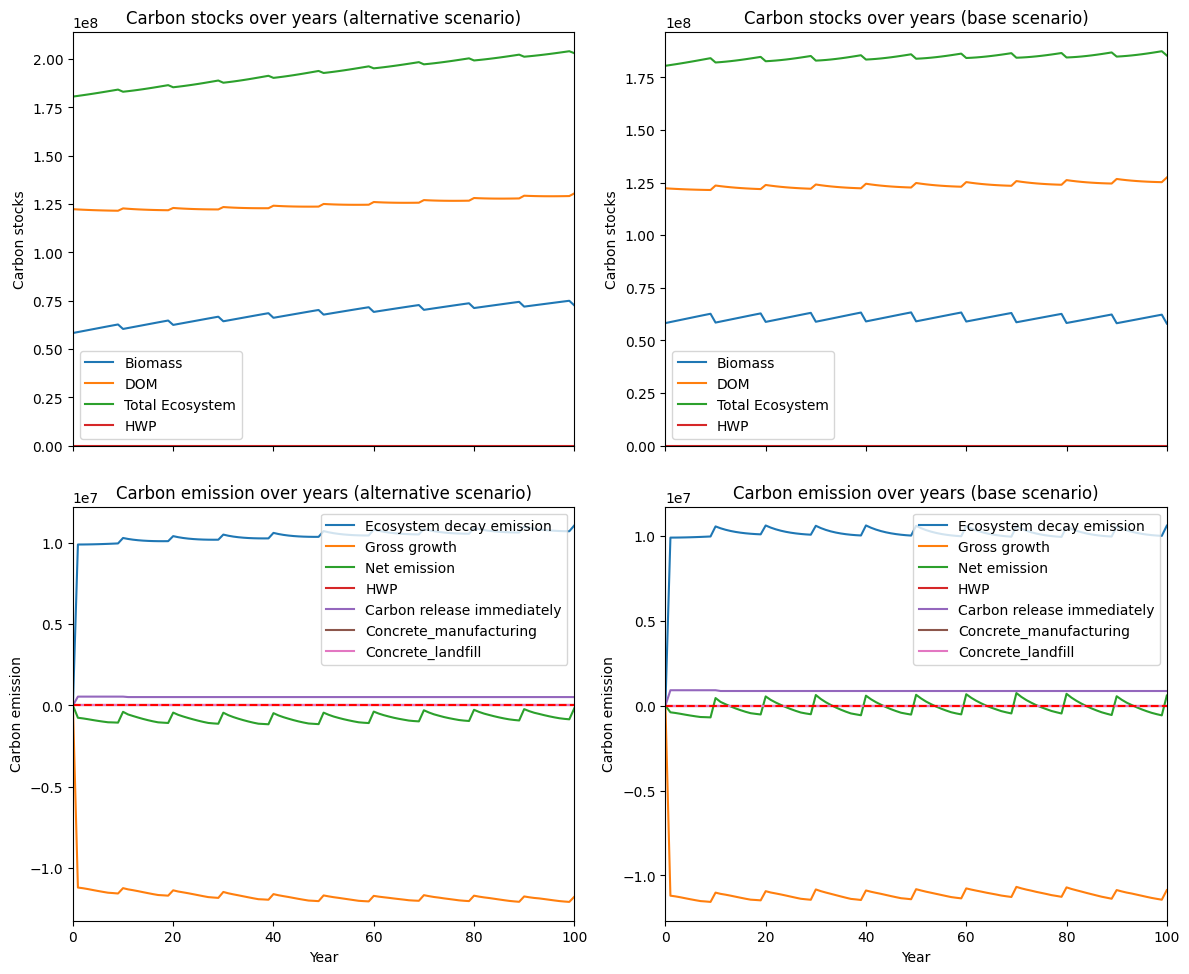

---------------------------------------------------------------------------------------
Net emission difference -14263685.793331051
Net emission base scenario -19915777.72286346
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  0.701081063120128
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  12613.932672  12613.932672
DougFir  0.0   1390.176949   1390.176949
Bal      0.0  24202.099718  24202.099718
Spruce   0.0  50004.663618  50004.663618
Aspen    0.0     17.263257     17.263257
Pine     0.0   3874.605812   3874.605812

Overall, the old growth area has **increased** by 92102.74 hectares in the alternative scenario compared to the base scenario.


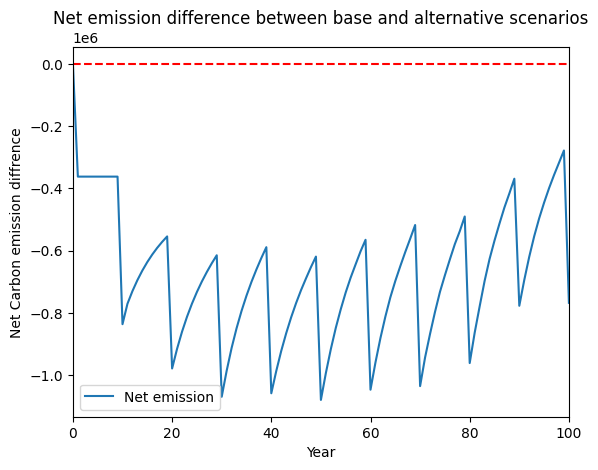

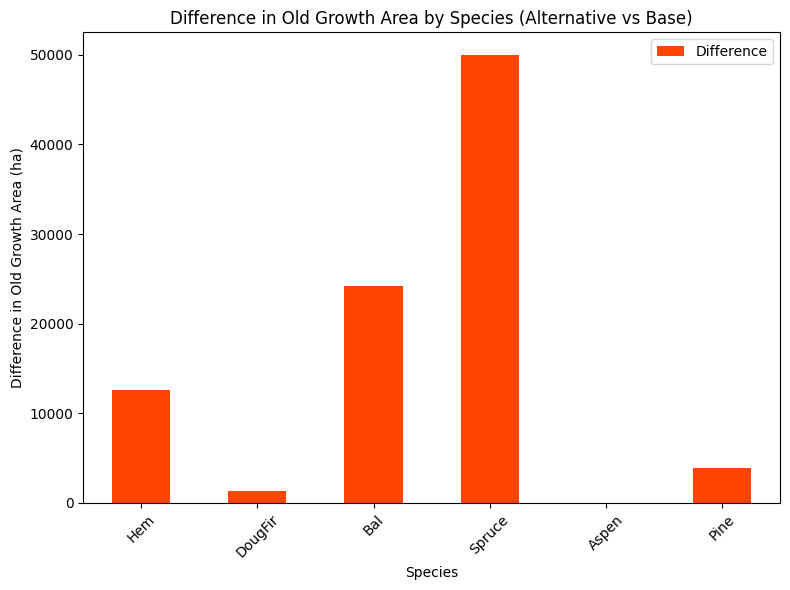

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


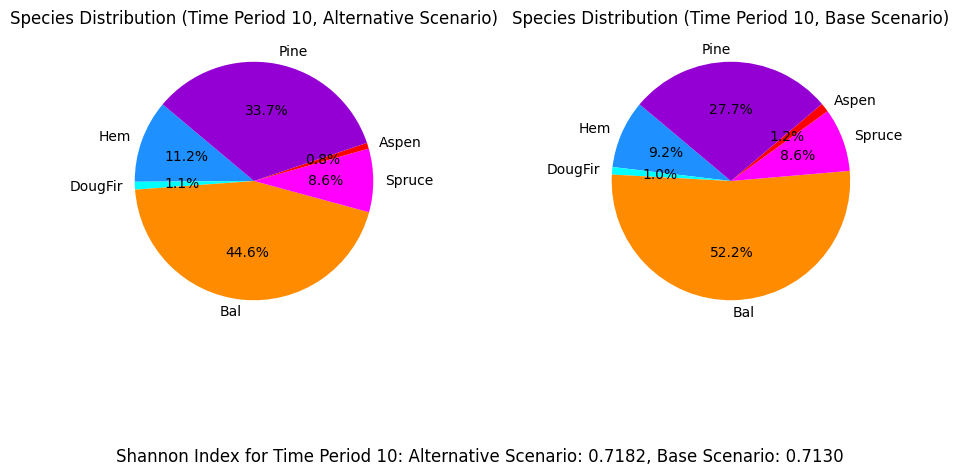

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_eqtslvr_AAC_50%...
running the scenario for the Equity Silver mining site (50%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x56766a8b
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.29s
Presolved: 8375 r

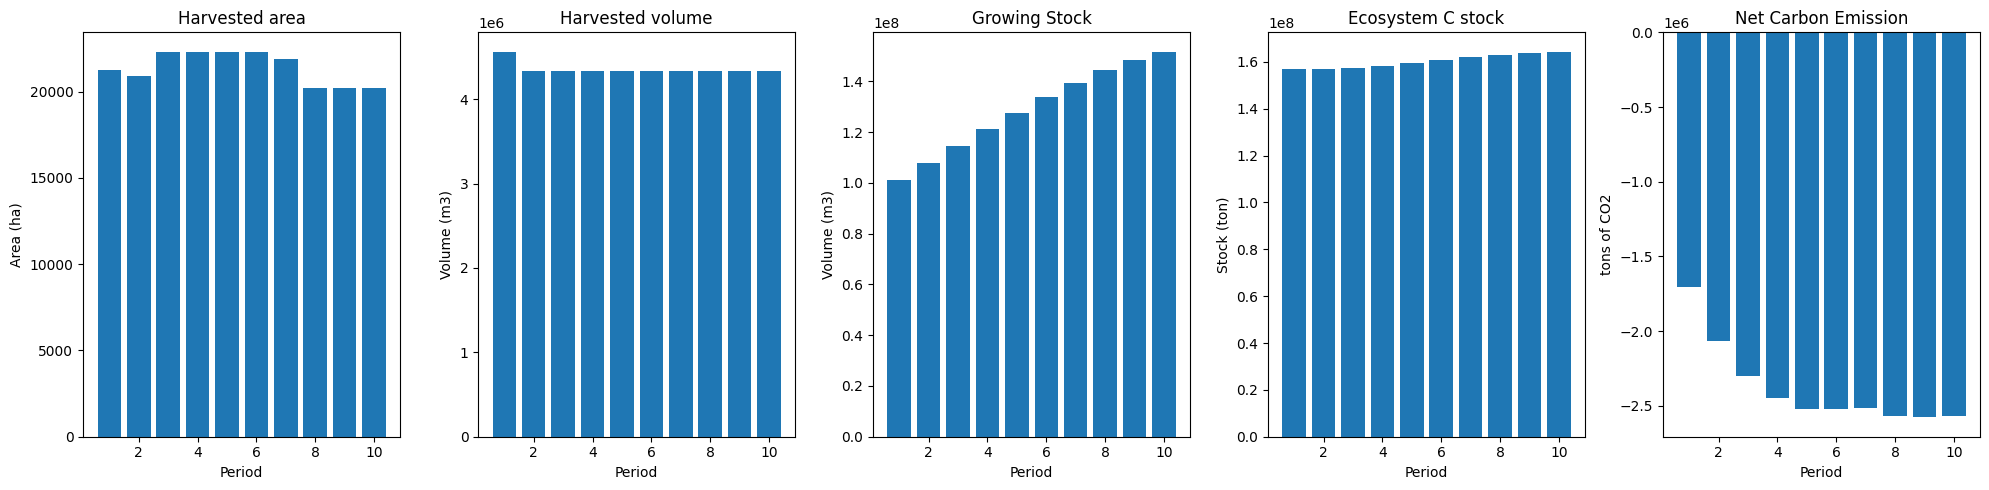

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_50%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  46078
The economic indicator (the provincial government revenues) is:  1571378
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


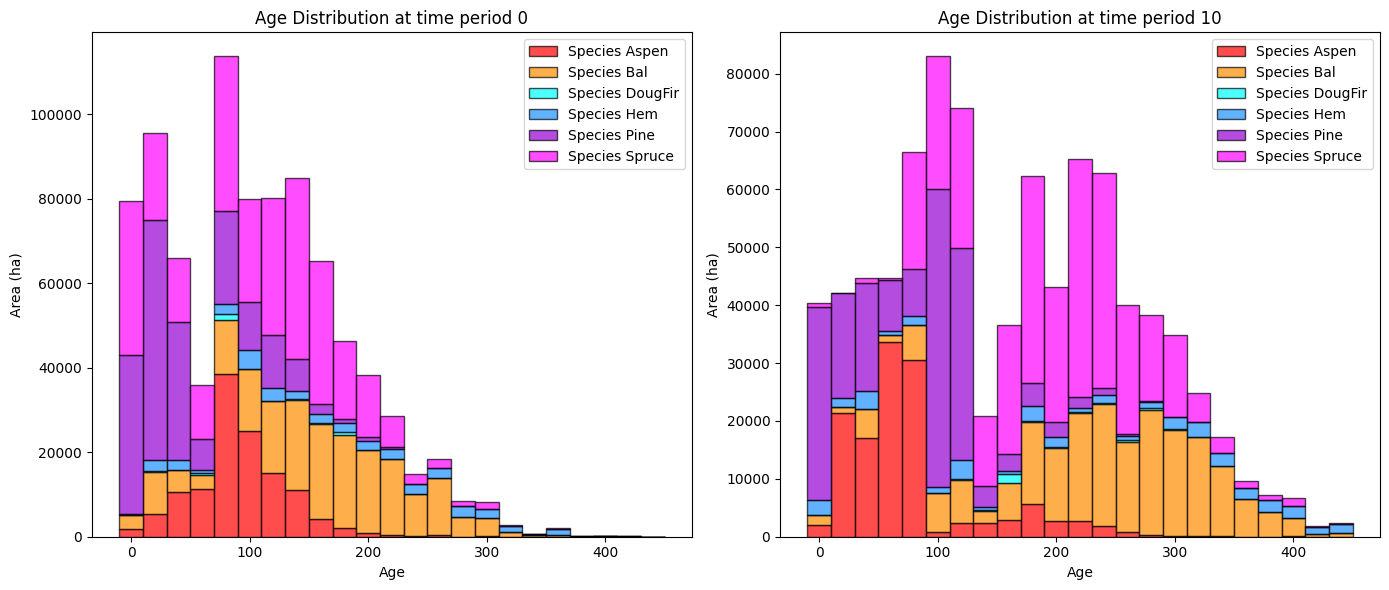

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_50%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   23505.455095    4353.327867
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  145352.338422   86036.367953
Spruce   36410.744598  196033.354526  159622.609928
Aspen    29632.731169   20711.283745   -8921.447424
Pine      7432.733686   18136.435488   10703.701802

Overall diversity has **increased** by 253596.81 hectares from time period 0 to time period 10.


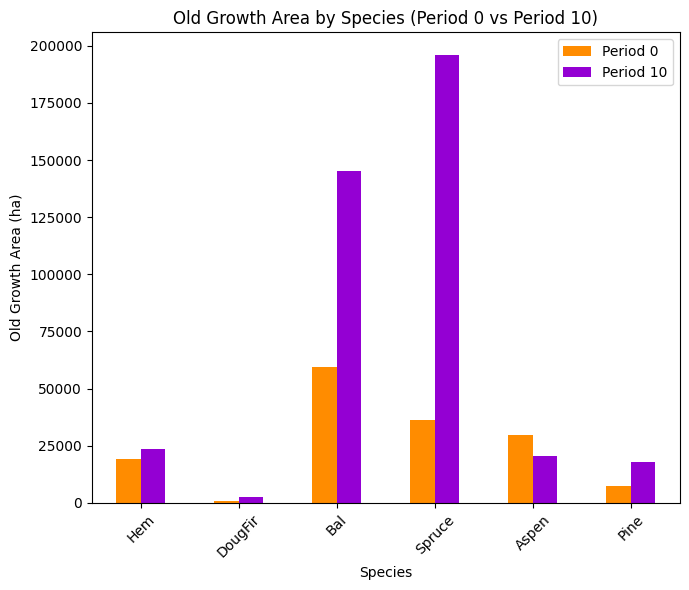

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_50%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7187

Diversity has **decreased** by 4.05% from time 0 to time 10.


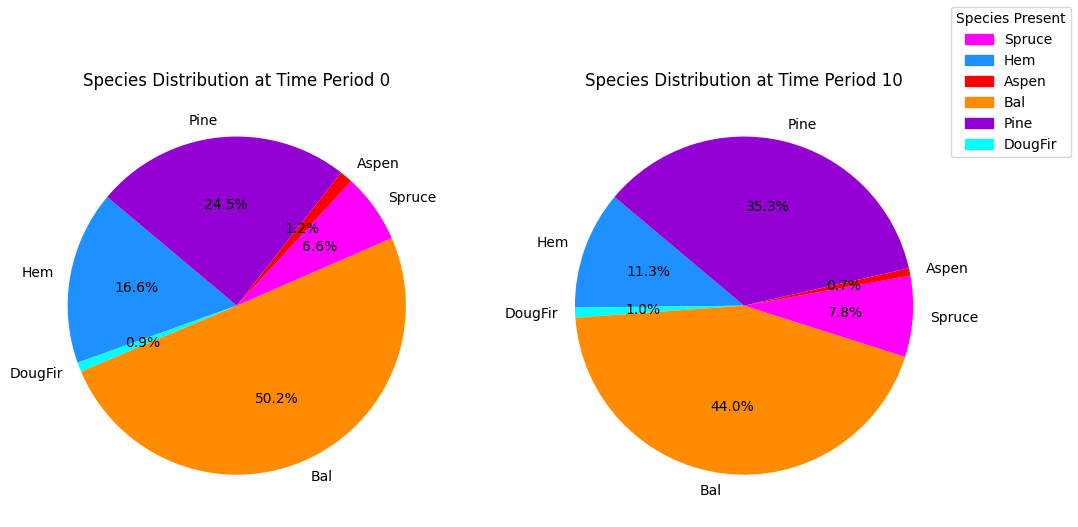

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_50%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.26s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

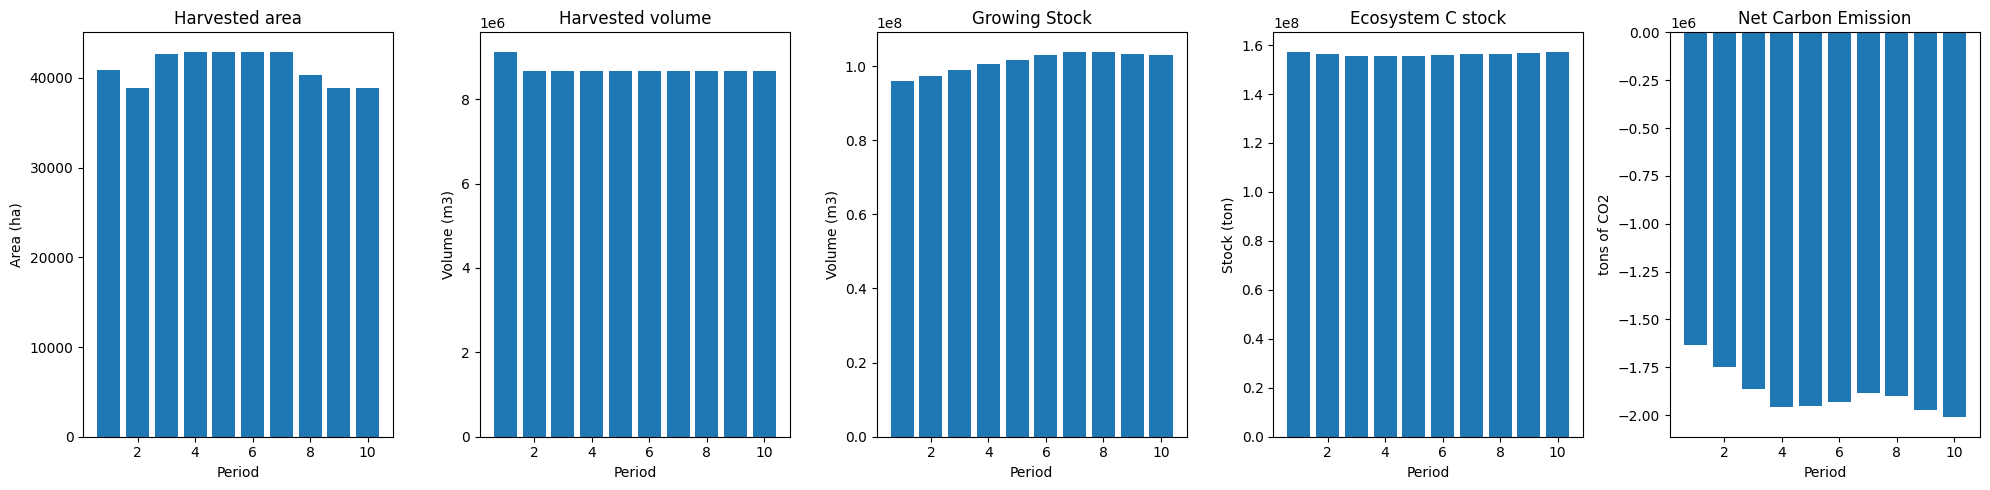

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


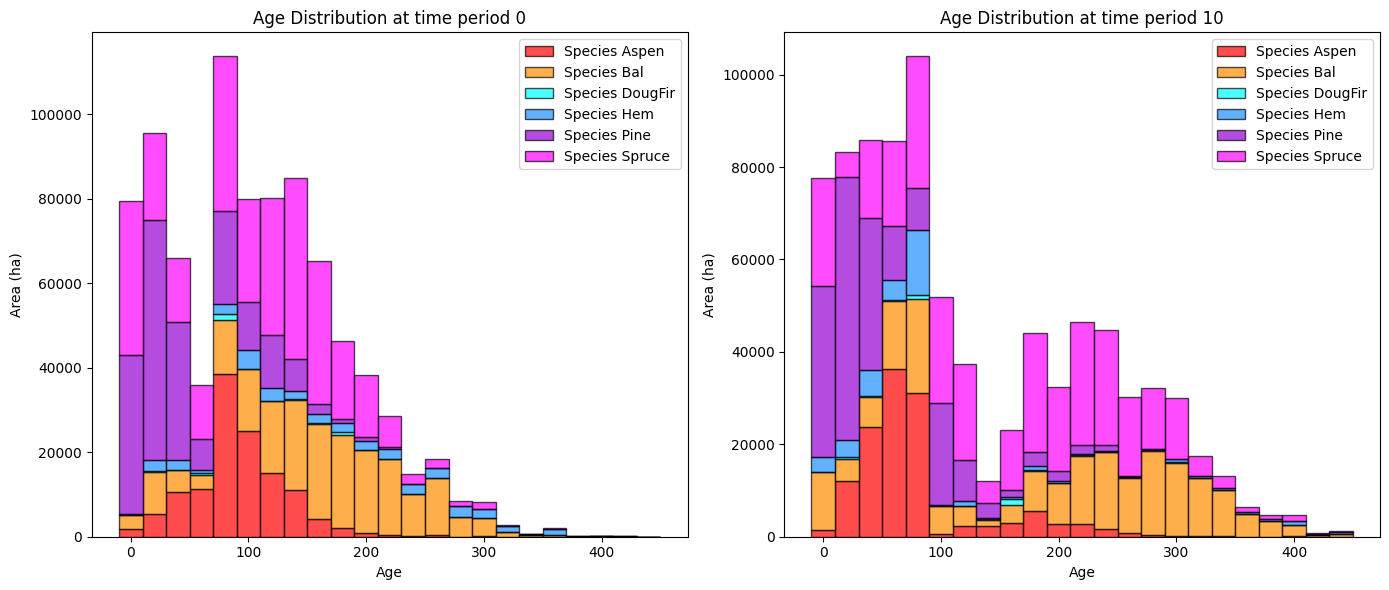

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


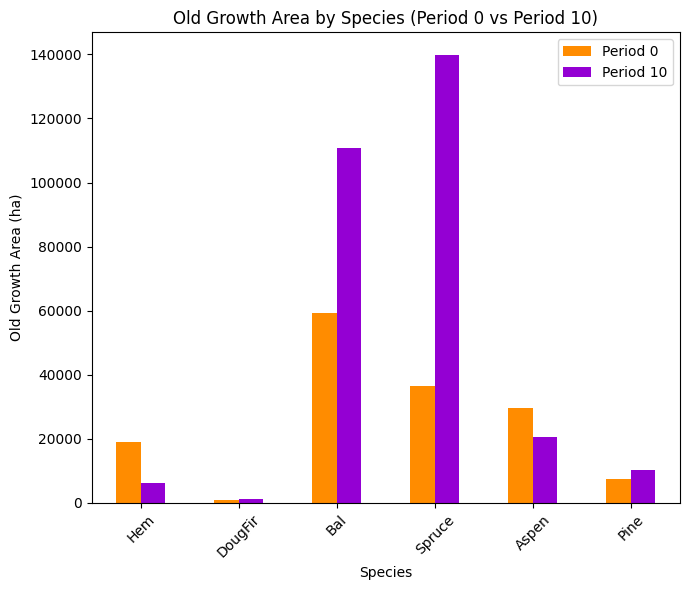

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


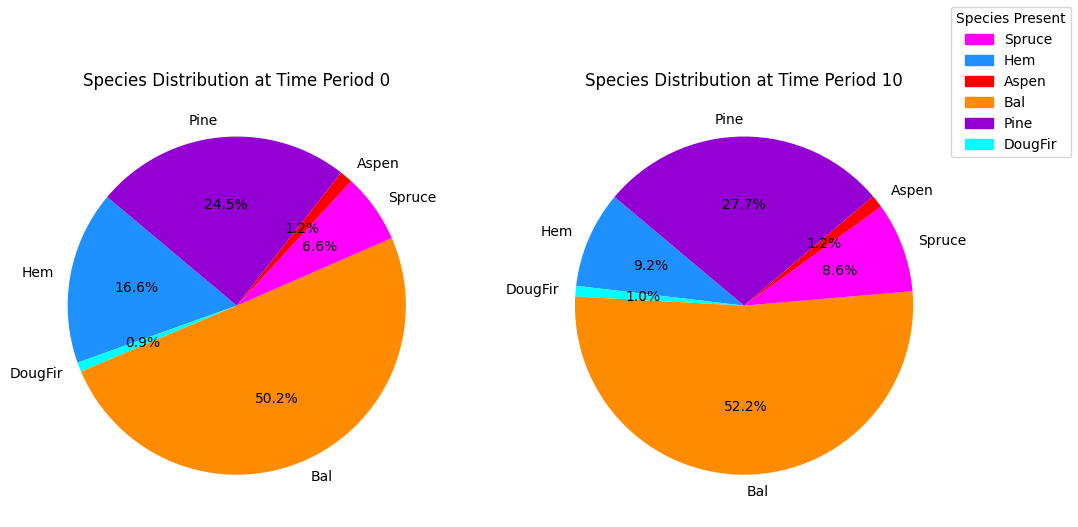

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


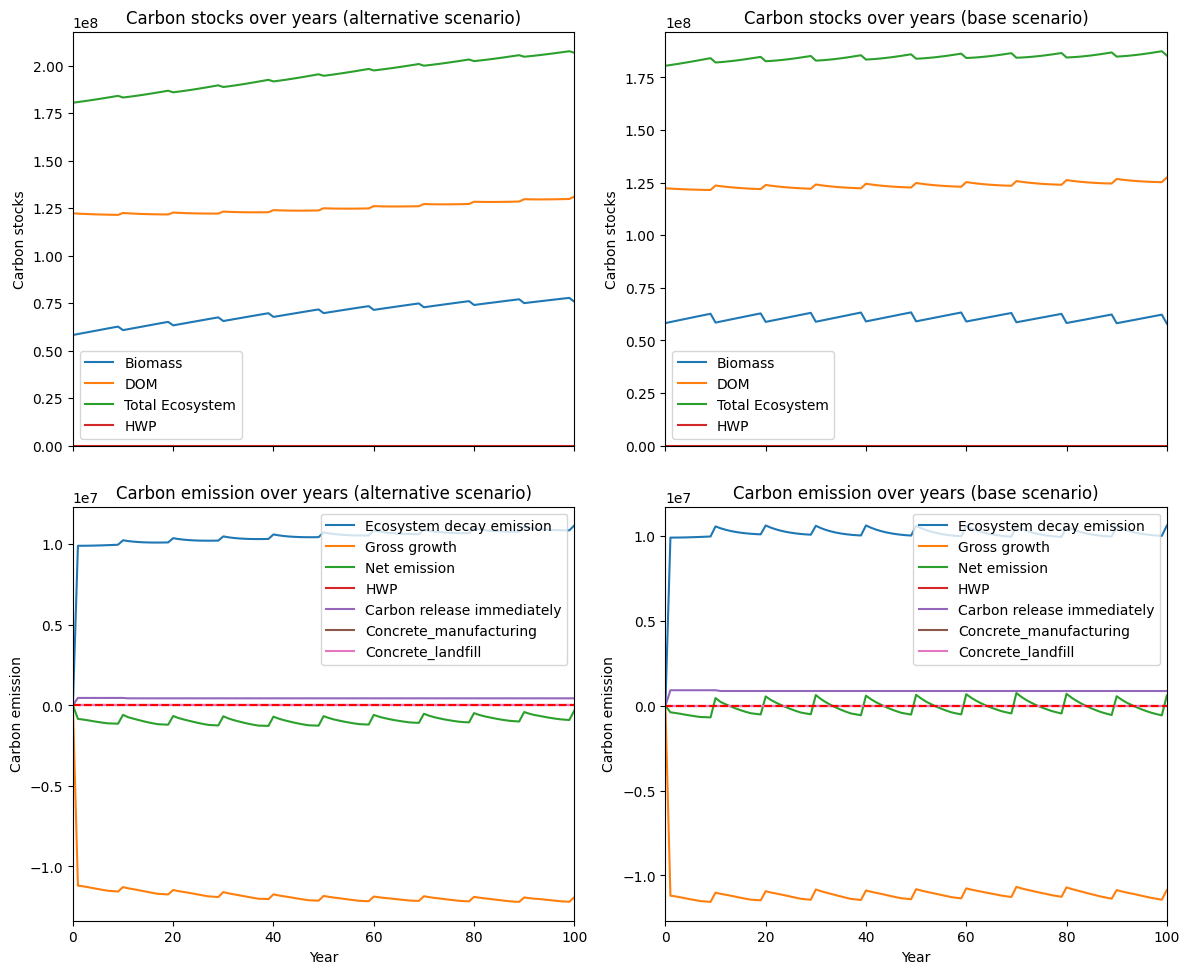

---------------------------------------------------------------------------------------
Net emission difference -17667108.189585138
Net emission base scenario -23319200.119117547
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  0.5660235898648687
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  17225.898803  17225.898803
DougFir  0.0   1390.176949   1390.176949
Bal      0.0  34460.967131  34460.967131
Spruce   0.0  56153.544092  56153.544092
Aspen    0.0     21.755777     21.755777
Pine     0.0   7951.227445   7951.227445

Overall, the old growth area has **increased** by 117203.57 hectares in the alternative scenario compared to the base scenario.


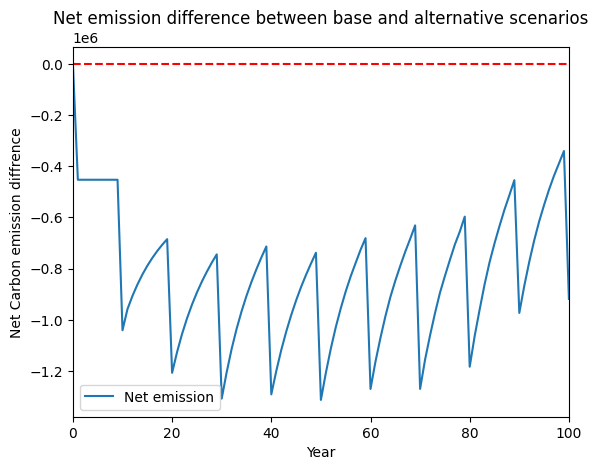

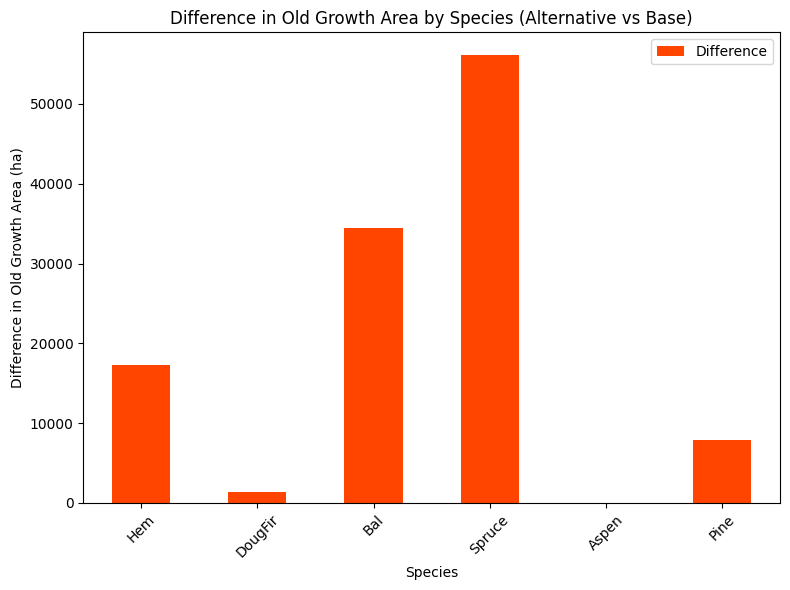

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


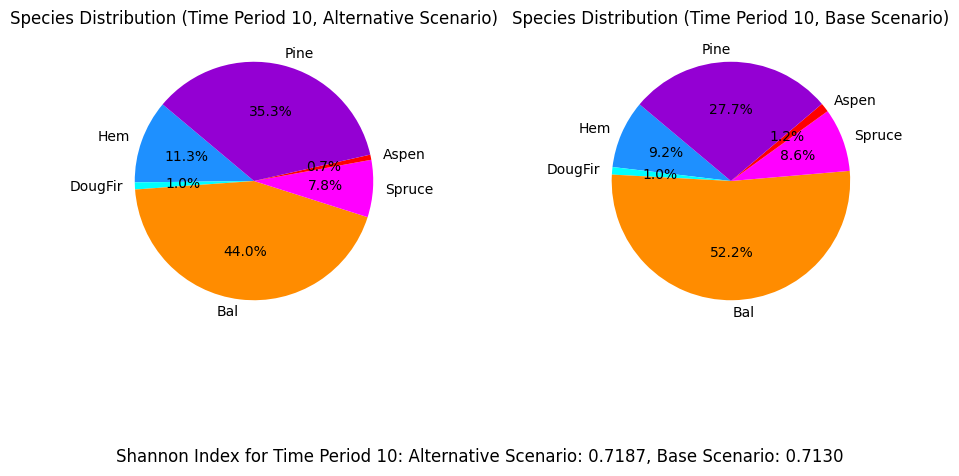

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_eqtslvr_AAC_40%...
running the scenario for the Equity Silver mining site (40%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xc14120b0
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.29s
Presolved: 8375 r

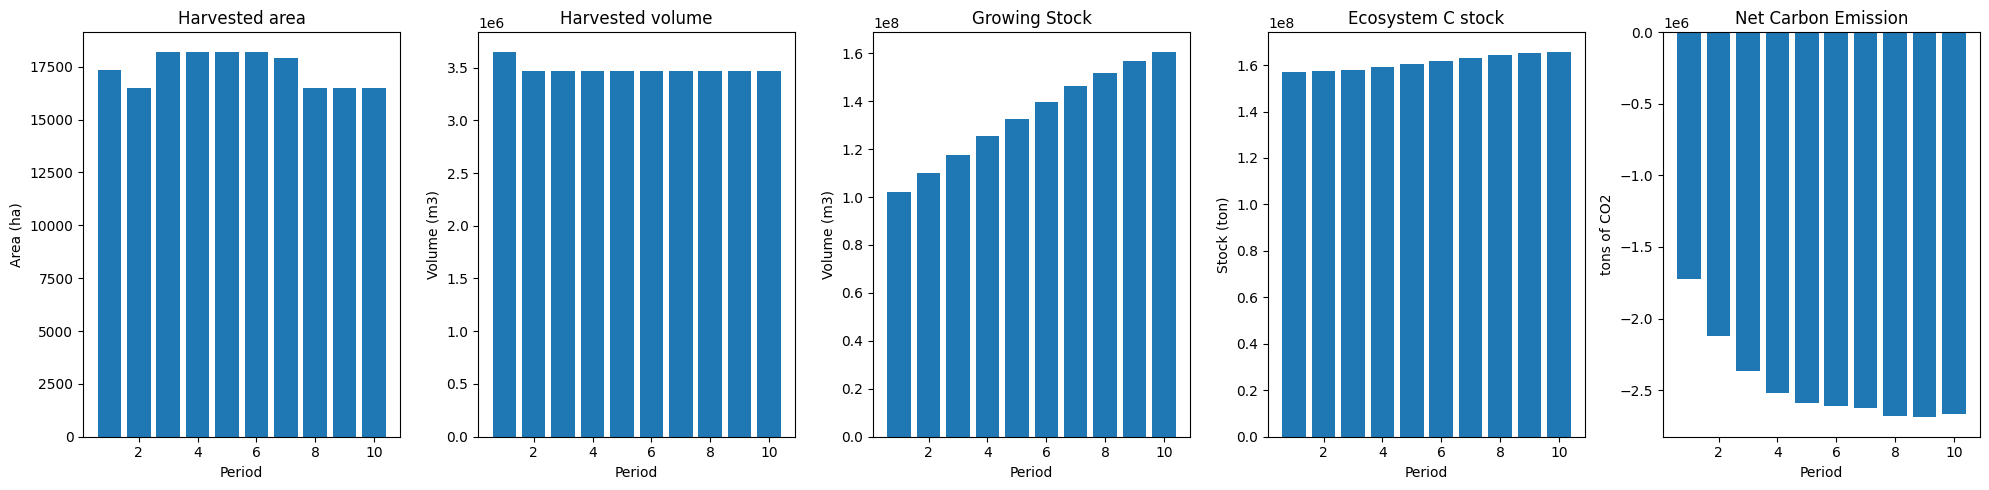

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_40%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  36862
The economic indicator (the provincial government revenues) is:  1257102
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


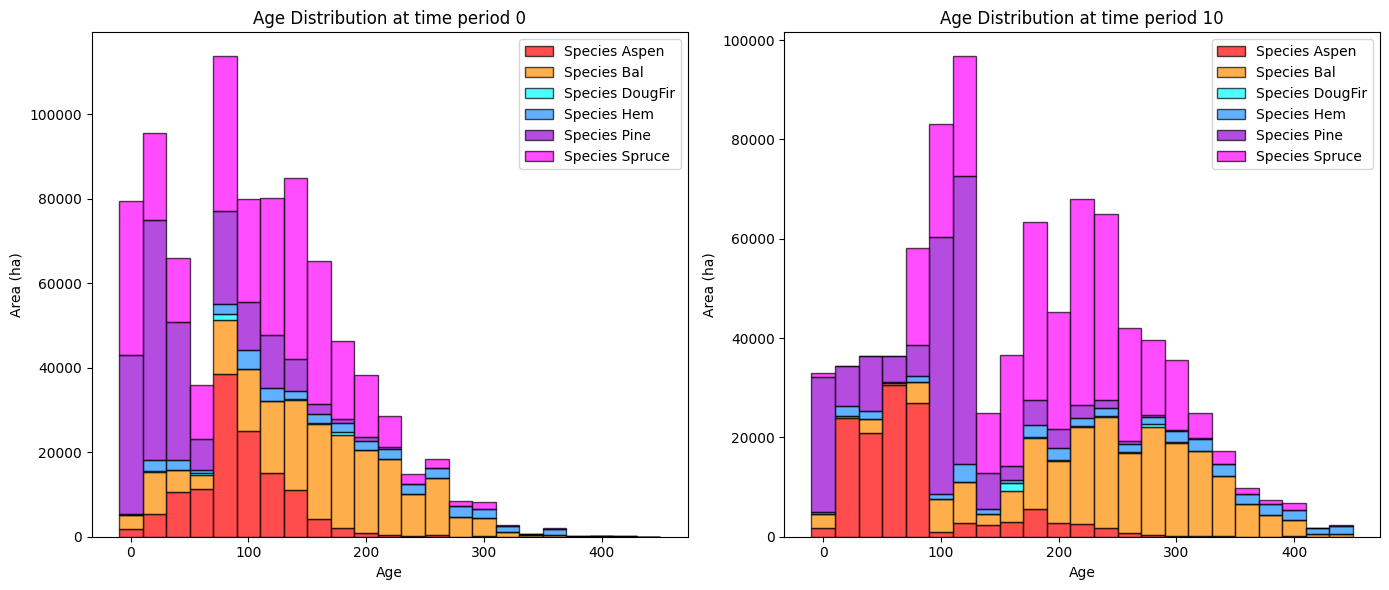

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_40%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   27323.291331    8171.164103
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  149339.639671   90023.669202
Spruce   36410.744598  197818.592269  161407.847671
Aspen    29632.731169   20823.697019   -8809.034150
Pine      7432.733686   27911.409997   20478.676311

Overall diversity has **increased** by 273074.57 hectares from time period 0 to time period 10.


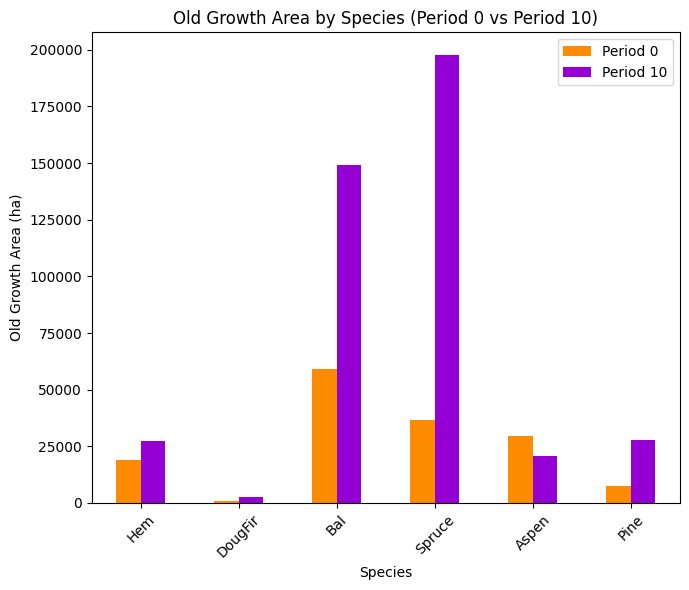

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_40%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7210

Diversity has **decreased** by 3.81% from time 0 to time 10.


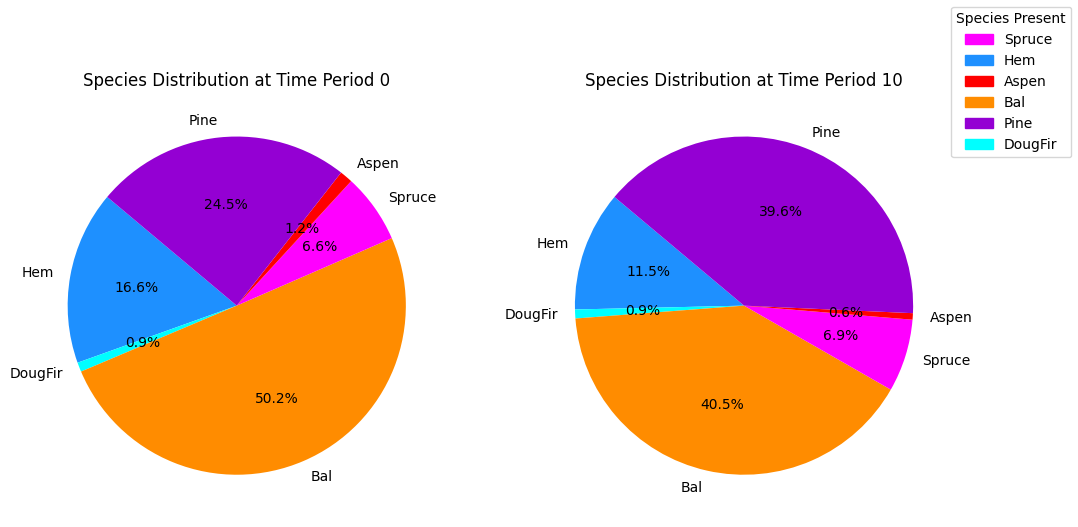

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_40%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.25s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

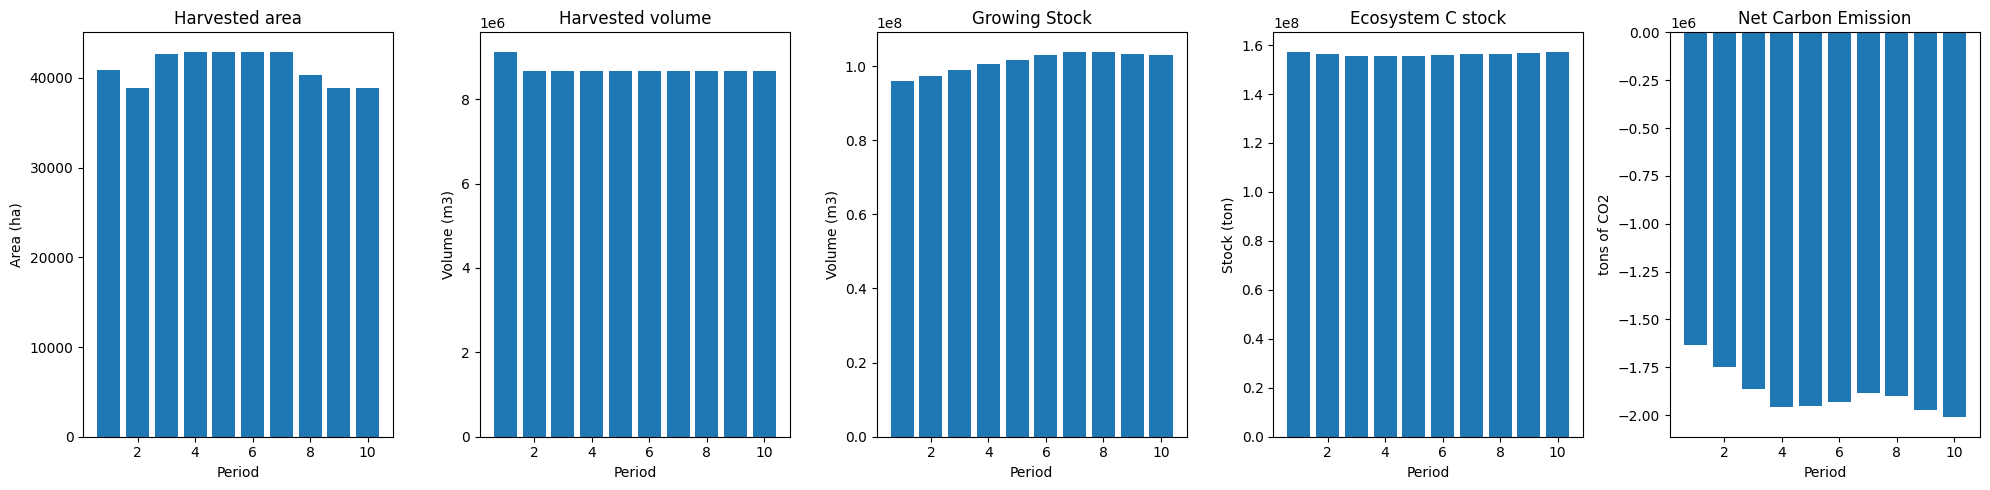

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


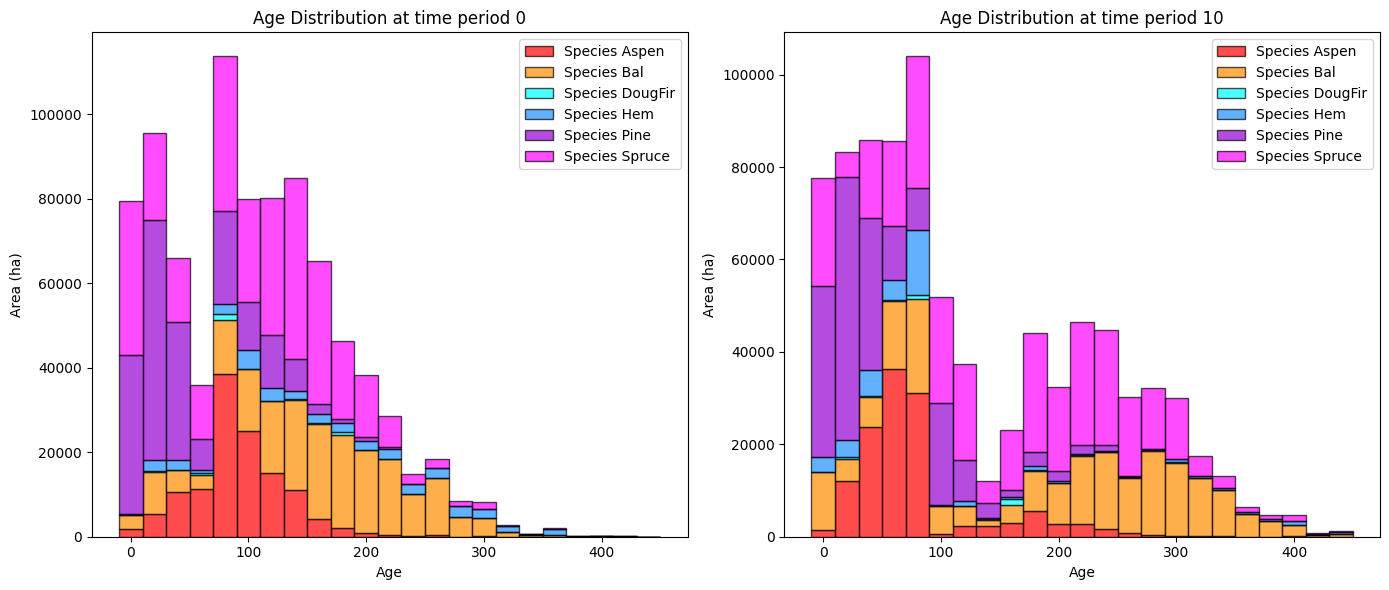

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


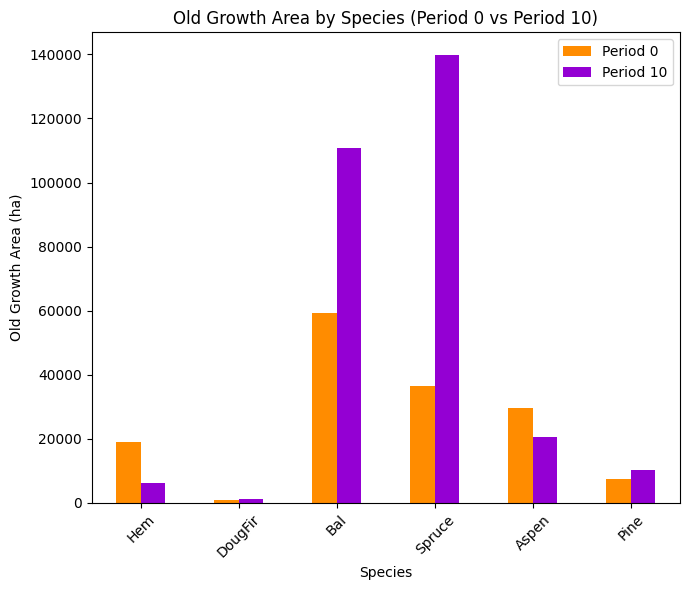

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


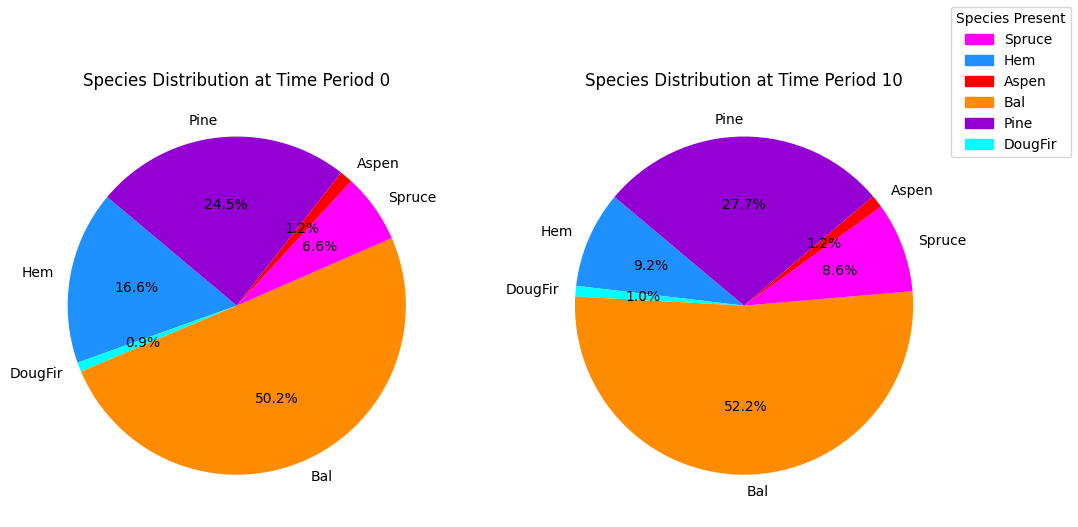

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


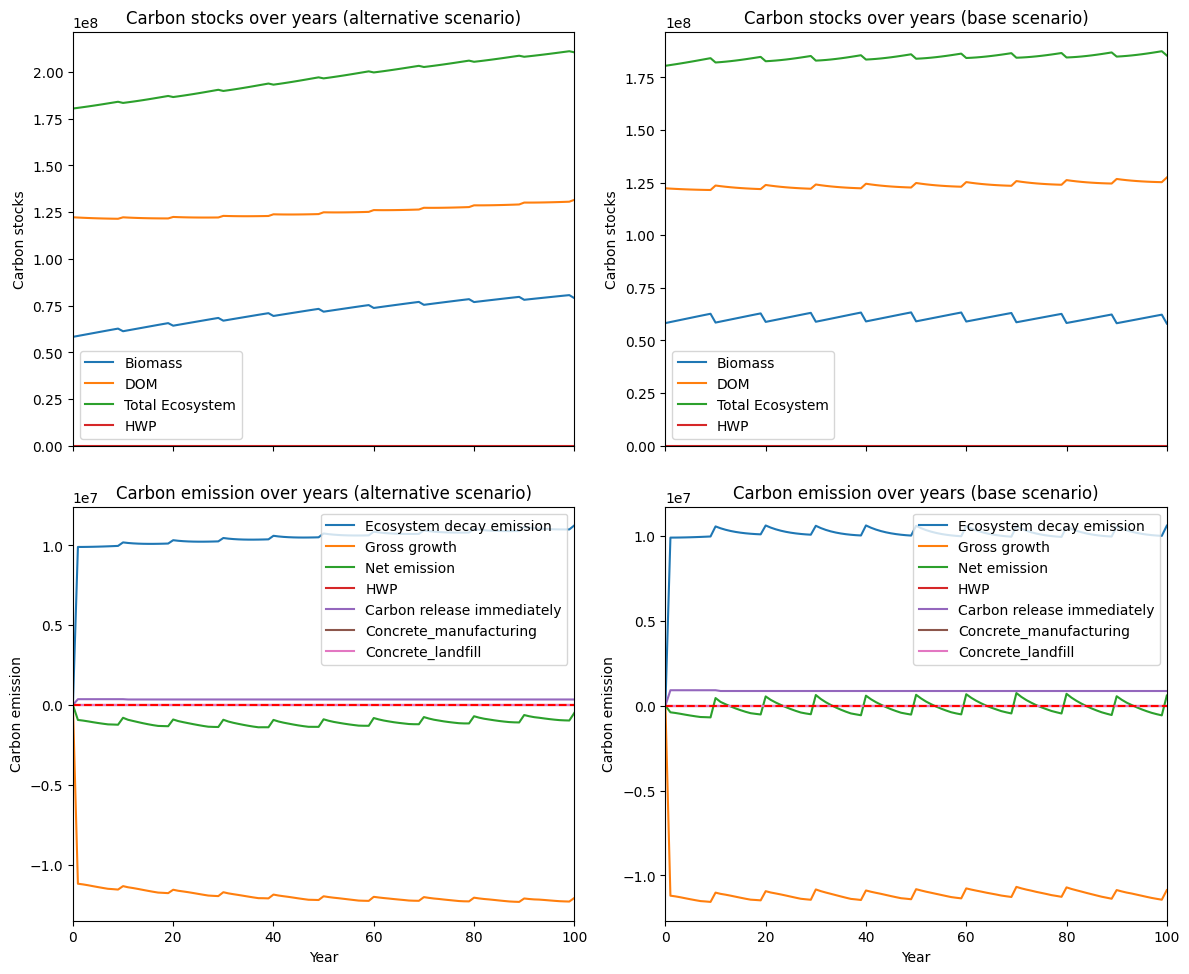

---------------------------------------------------------------------------------------
Net emission difference -21071415.04069959
Net emission base scenario -26723506.970231995
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  0.47457657592928276
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  21043.735039  21043.735039
DougFir  0.0   1390.176949   1390.176949
Bal      0.0  38448.268380  38448.268380
Spruce   0.0  57938.781835  57938.781835
Aspen    0.0    134.169052    134.169052
Pine     0.0  17726.201955  17726.201955

Overall, the old growth area has **increased** by 136681.33 hectares in the alternative scenario compared to the base scenario.


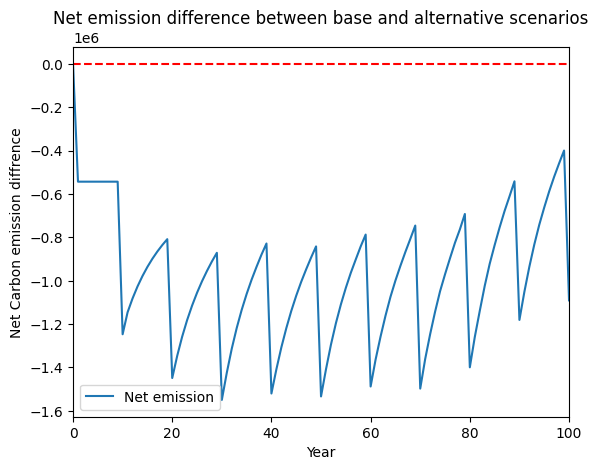

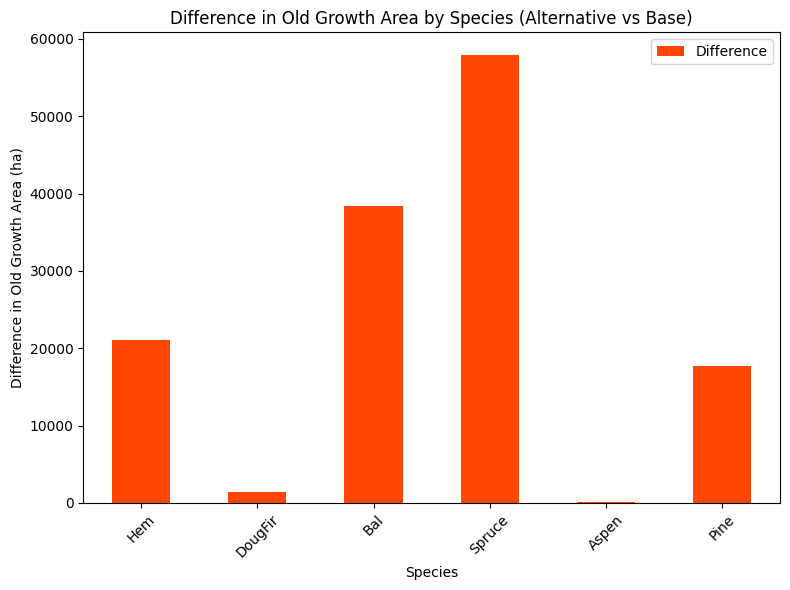

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


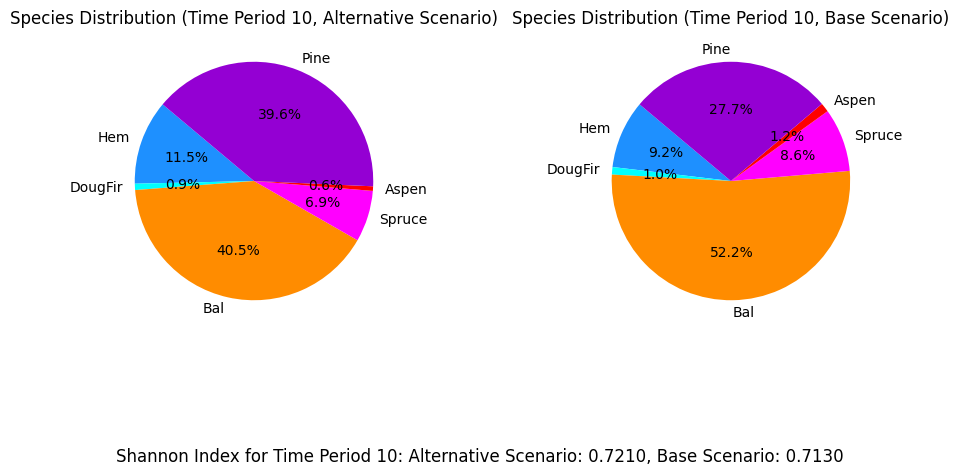

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_eqtslvr_AAC_30%...
running the scenario for the Equity Silver mining site (30%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x28cc63f4
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.31s
Presolved: 8375 r

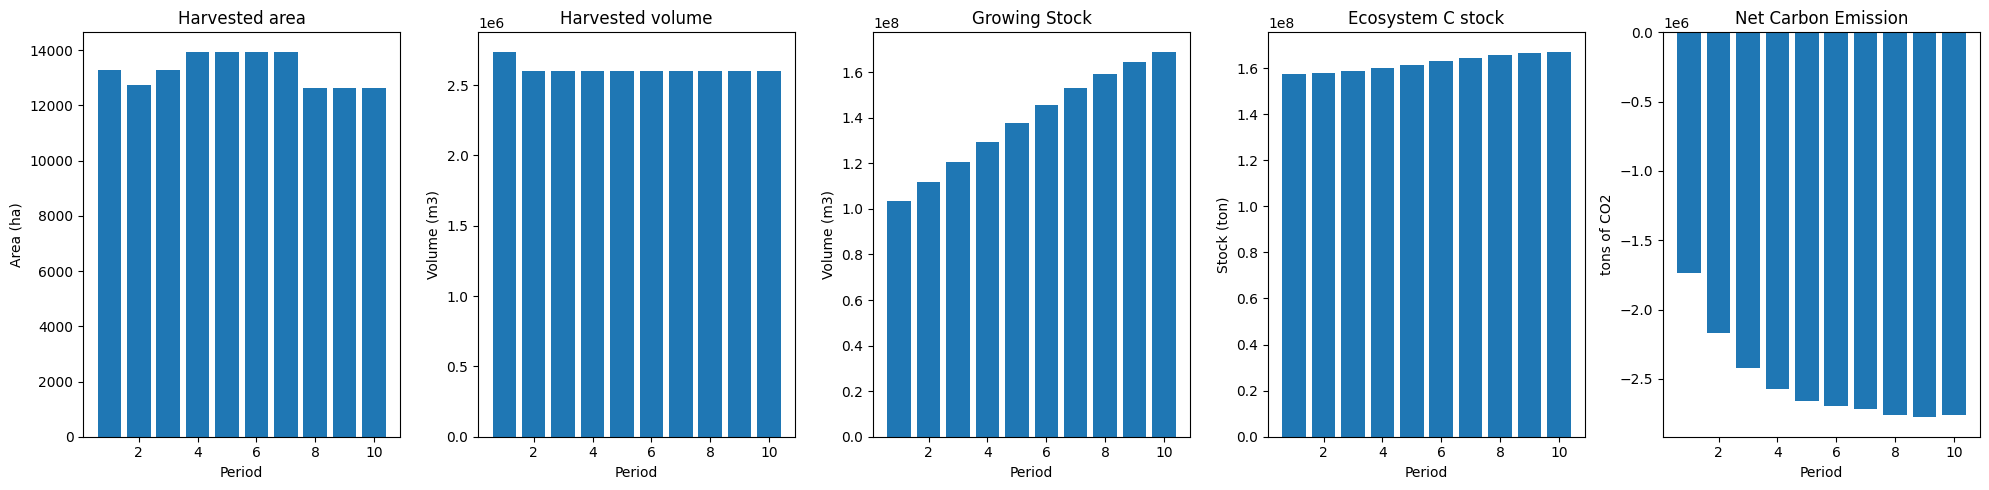

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_30%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  27647
The economic indicator (the provincial government revenues) is:  942827
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


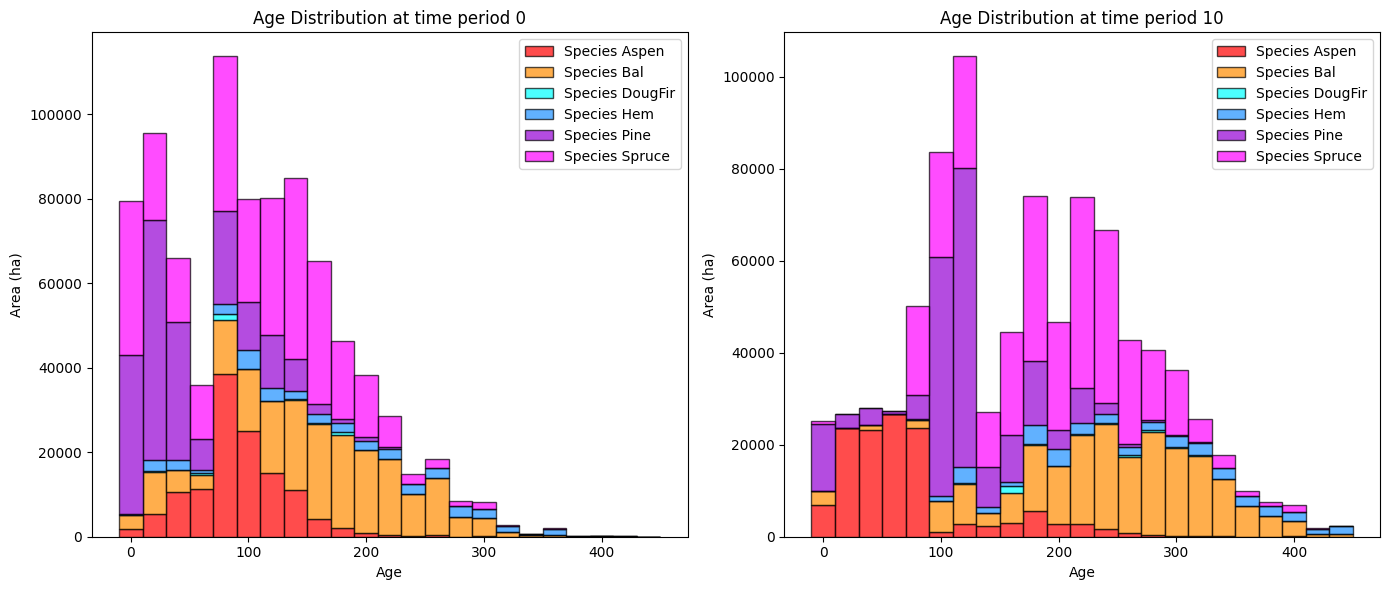

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_30%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   32688.964561   13536.837333
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  153020.043286   93704.072817
Spruce   36410.744598  197818.592269  161407.847671
Aspen    29632.731169   21022.530005   -8610.201164
Pine      7432.733686   48793.969605   41361.235919

Overall diversity has **increased** by 303202.04 hectares from time period 0 to time period 10.


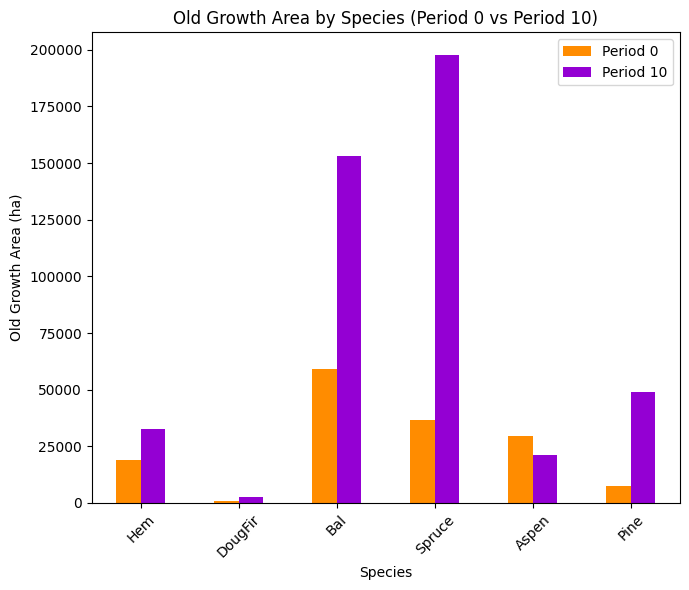

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_30%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7217

Diversity has **decreased** by 3.74% from time 0 to time 10.


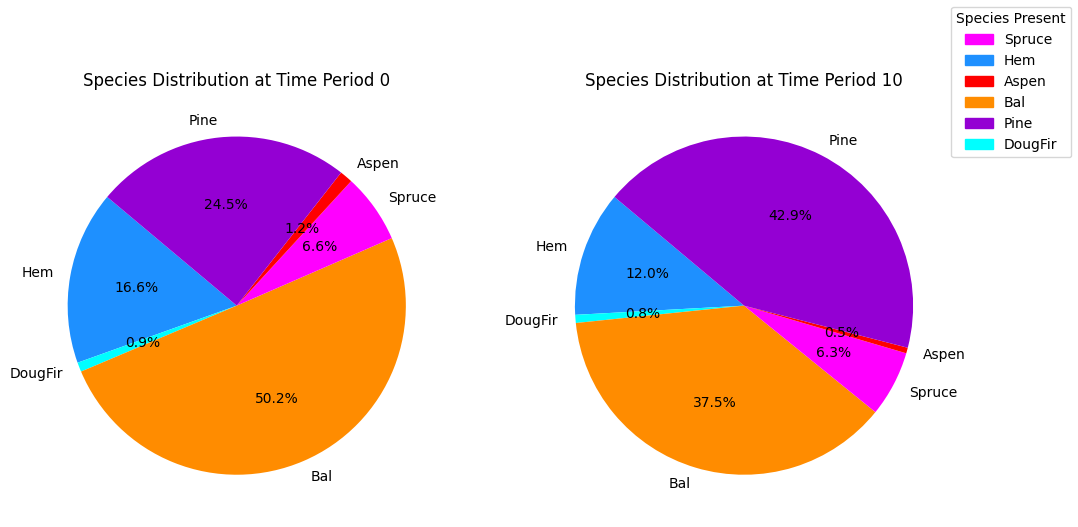

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_30%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.26s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

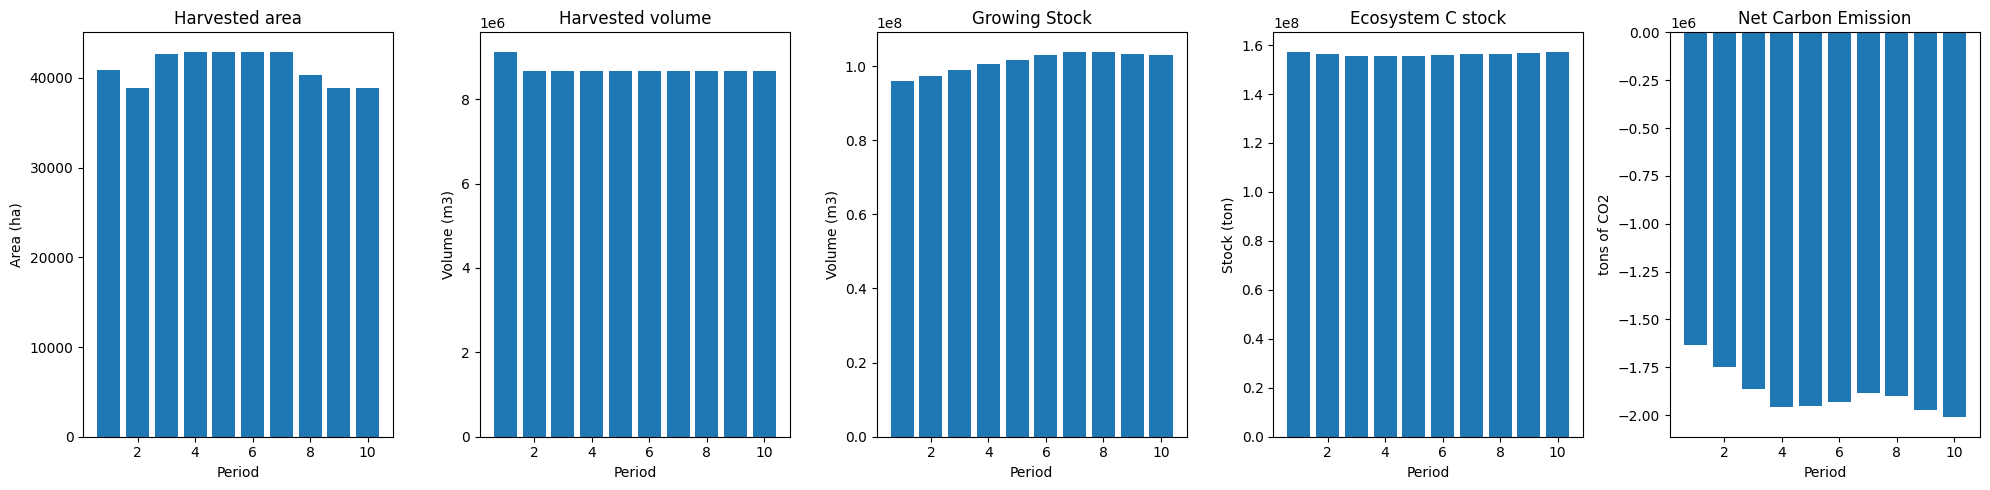

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


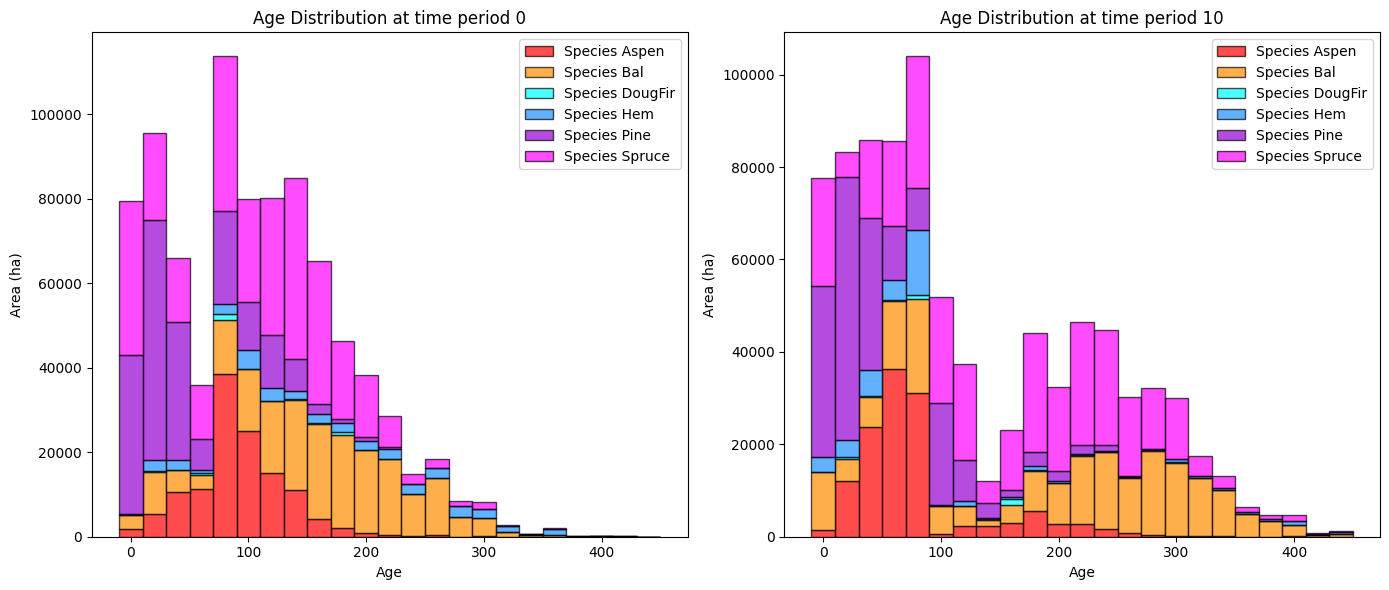

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


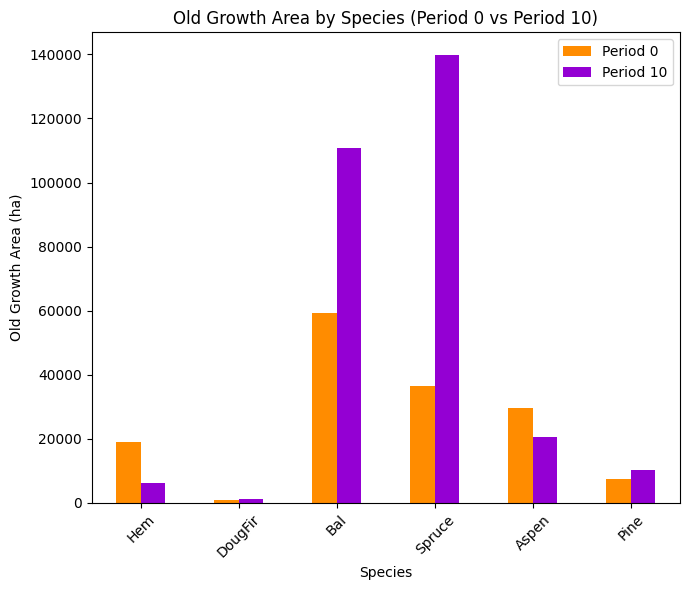

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


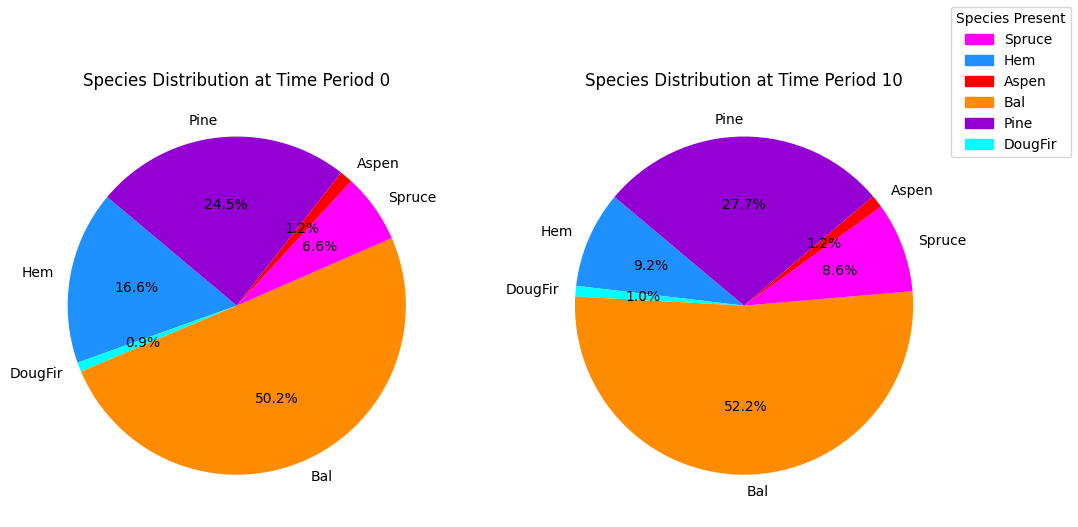

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


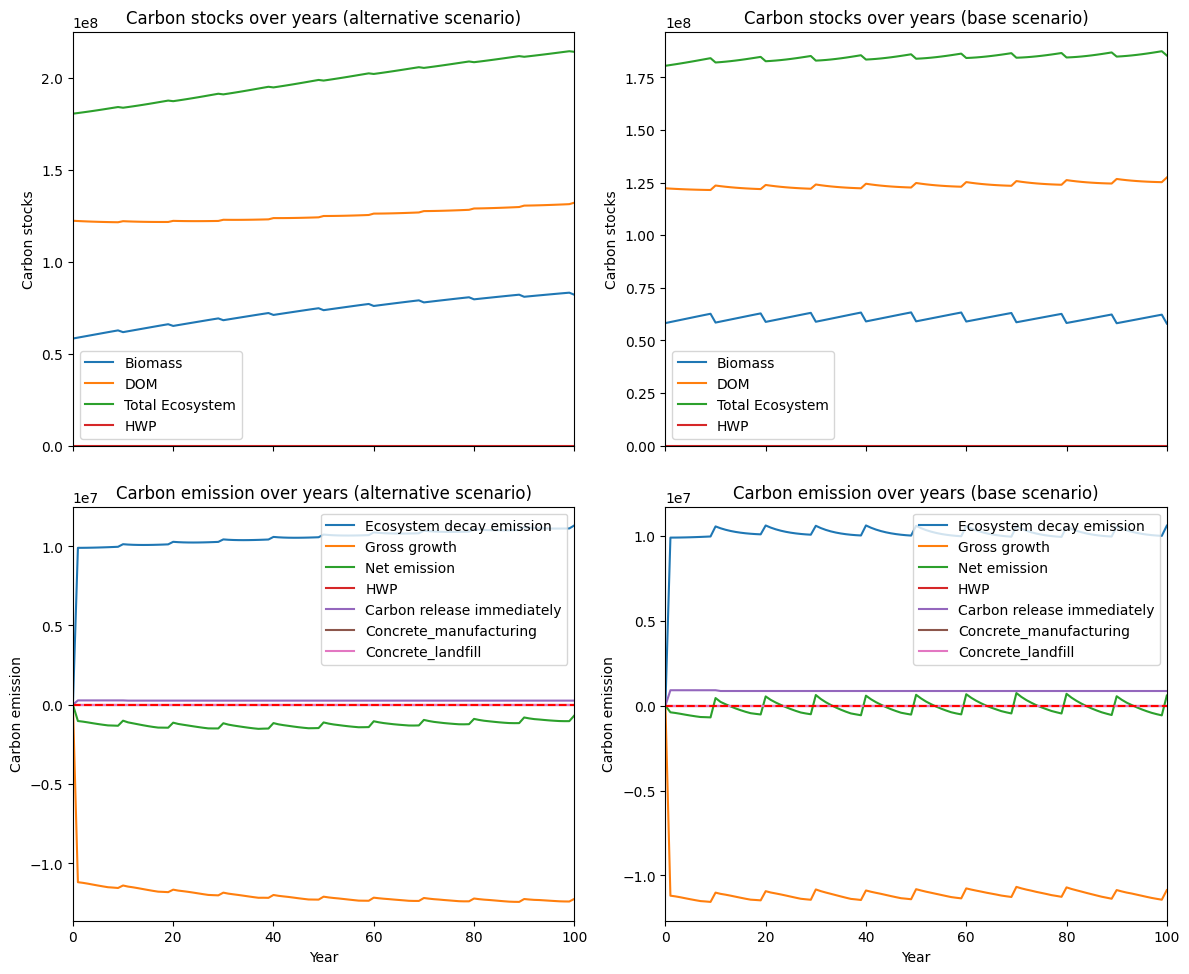

---------------------------------------------------------------------------------------
Net emission difference -24370172.28739924
Net emission base scenario -30022264.216931645
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  0.4103376817393518
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  26409.408269  26409.408269
DougFir  0.0   1390.176949   1390.176949
Bal      0.0  42128.671995  42128.671995
Spruce   0.0  57938.781835  57938.781835
Aspen    0.0    333.002038    333.002038
Pine     0.0  38608.761562  38608.761562

Overall, the old growth area has **increased** by 166808.80 hectares in the alternative scenario compared to the base scenario.


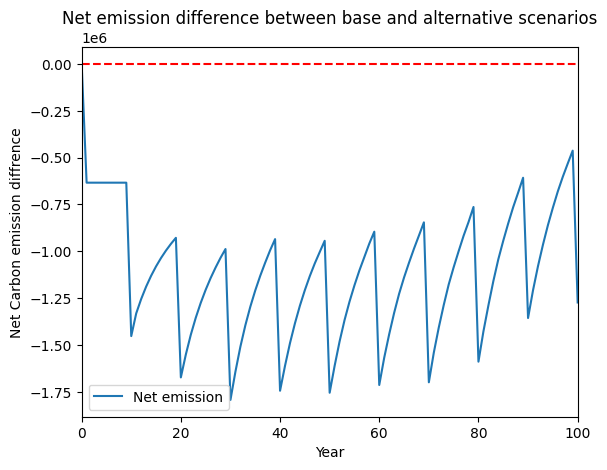

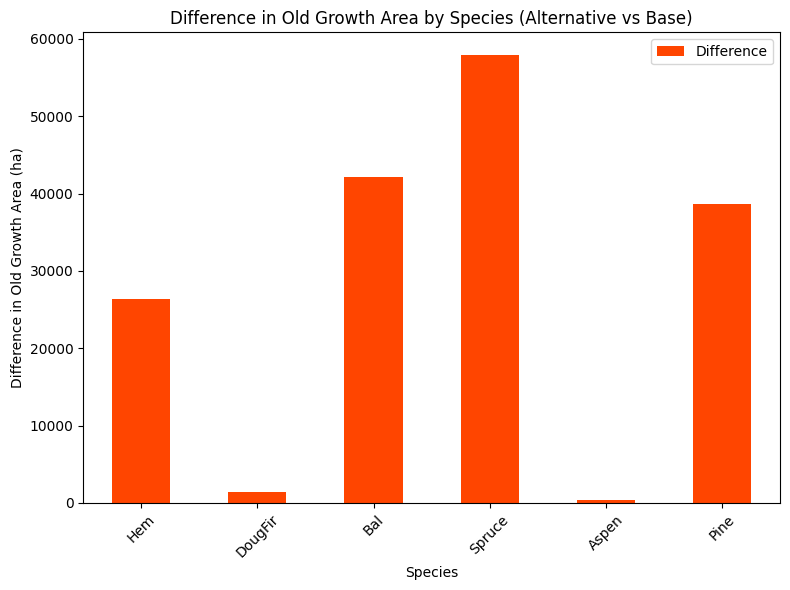

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


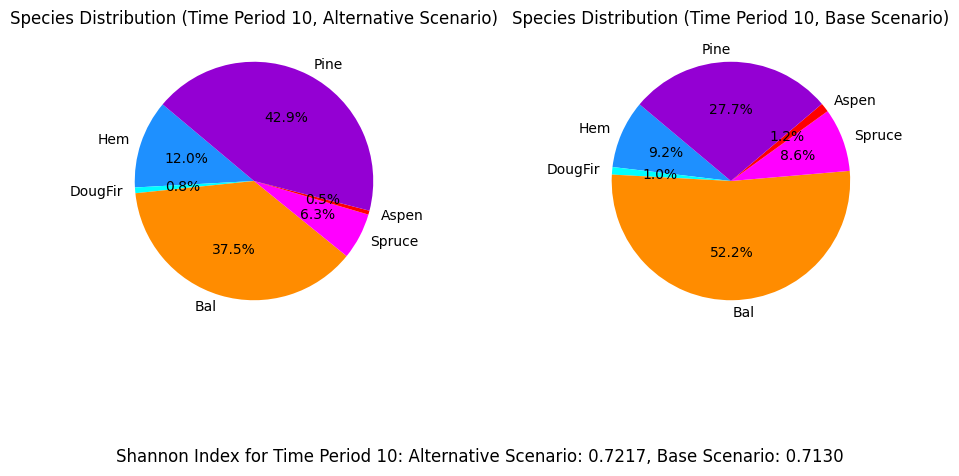

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_eqtslvr_AAC_20%...
running the scenario for the Equity Silver mining site (20%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xc577792a
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.26s
Presolved: 8375 r

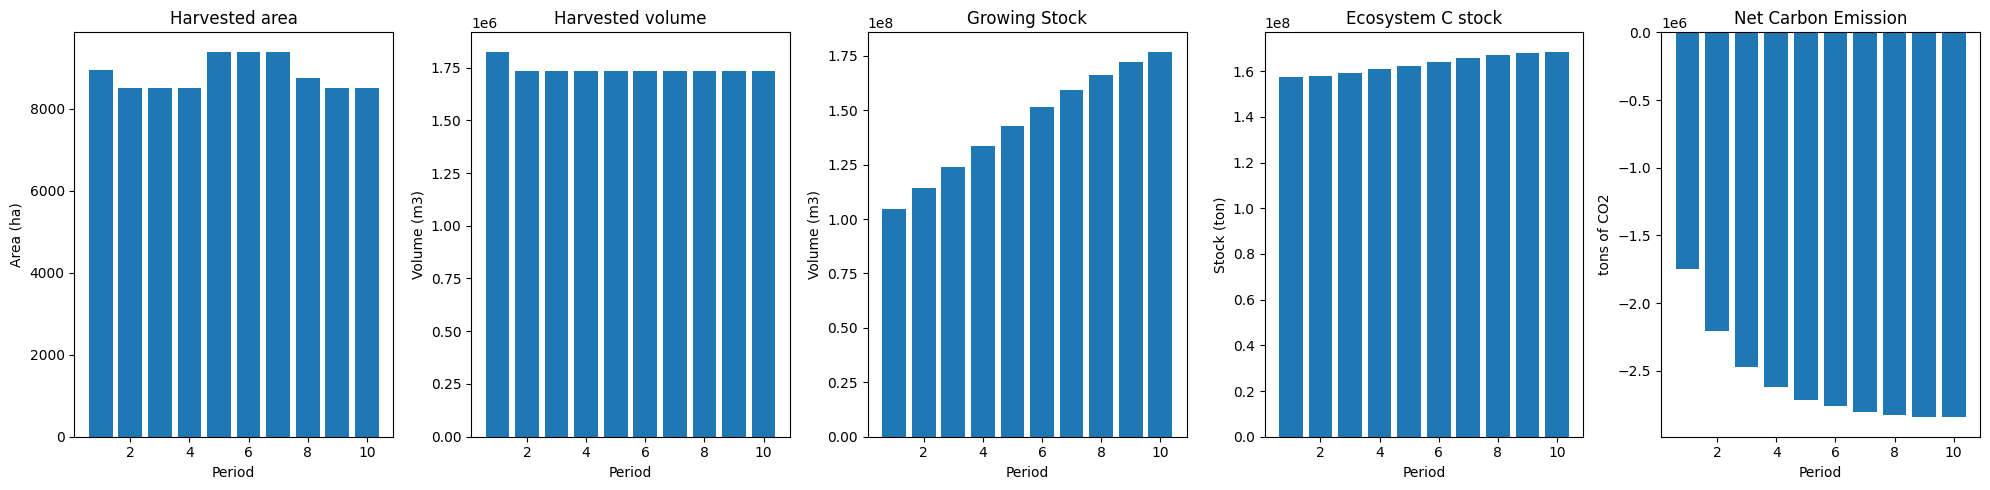

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_20%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  18431
The economic indicator (the provincial government revenues) is:  628551
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


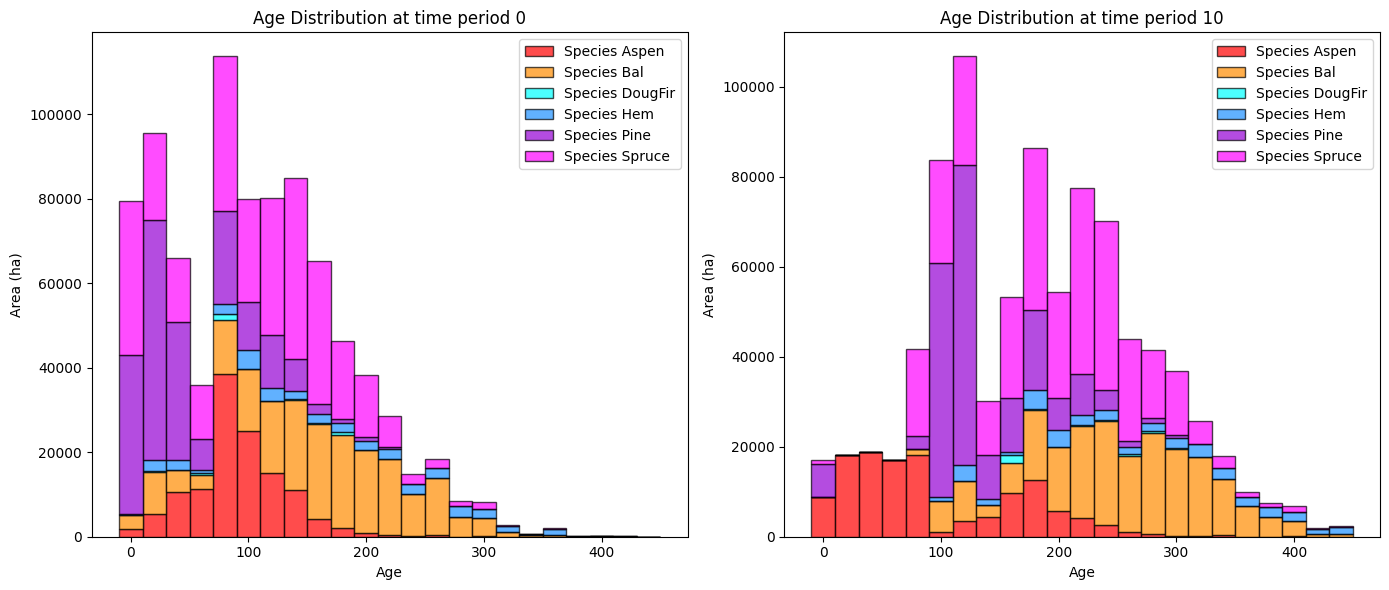

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_20%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   32688.964561   13536.837333
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  157689.747715   98373.777247
Spruce   36410.744598  197818.592269  161407.847671
Aspen    29632.731169   42619.355629   12986.624459
Pine      7432.733686   63386.640721   55953.907035

Overall diversity has **increased** by 344061.24 hectares from time period 0 to time period 10.


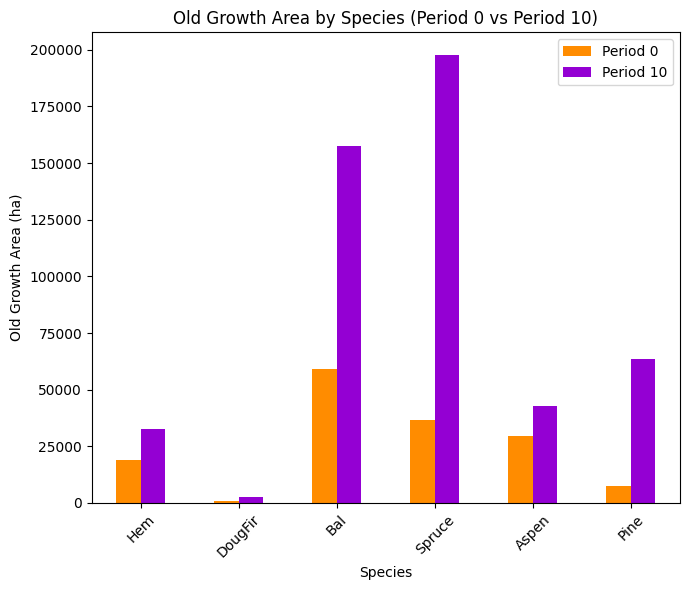

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_20%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7267

Diversity has **decreased** by 3.25% from time 0 to time 10.


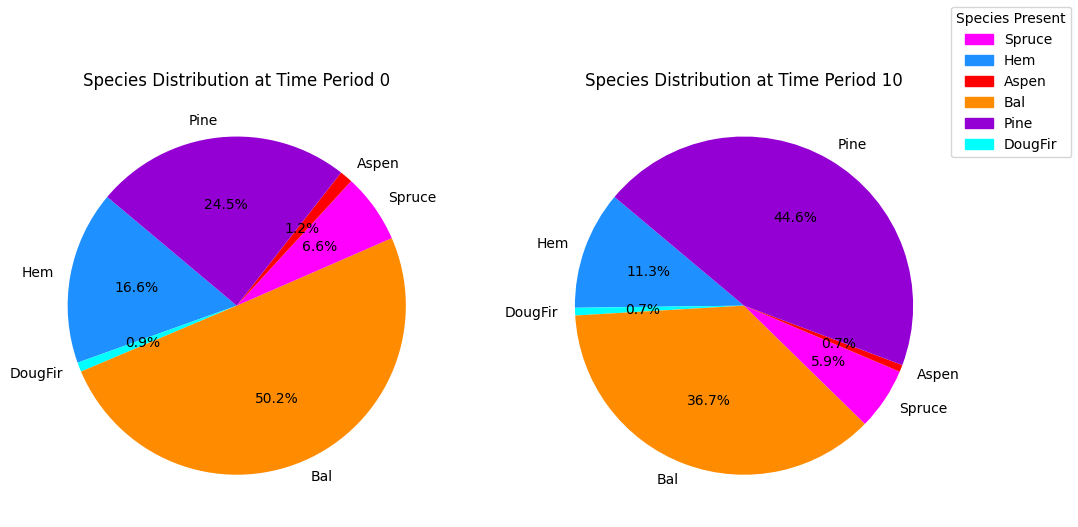

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_20%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.25s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

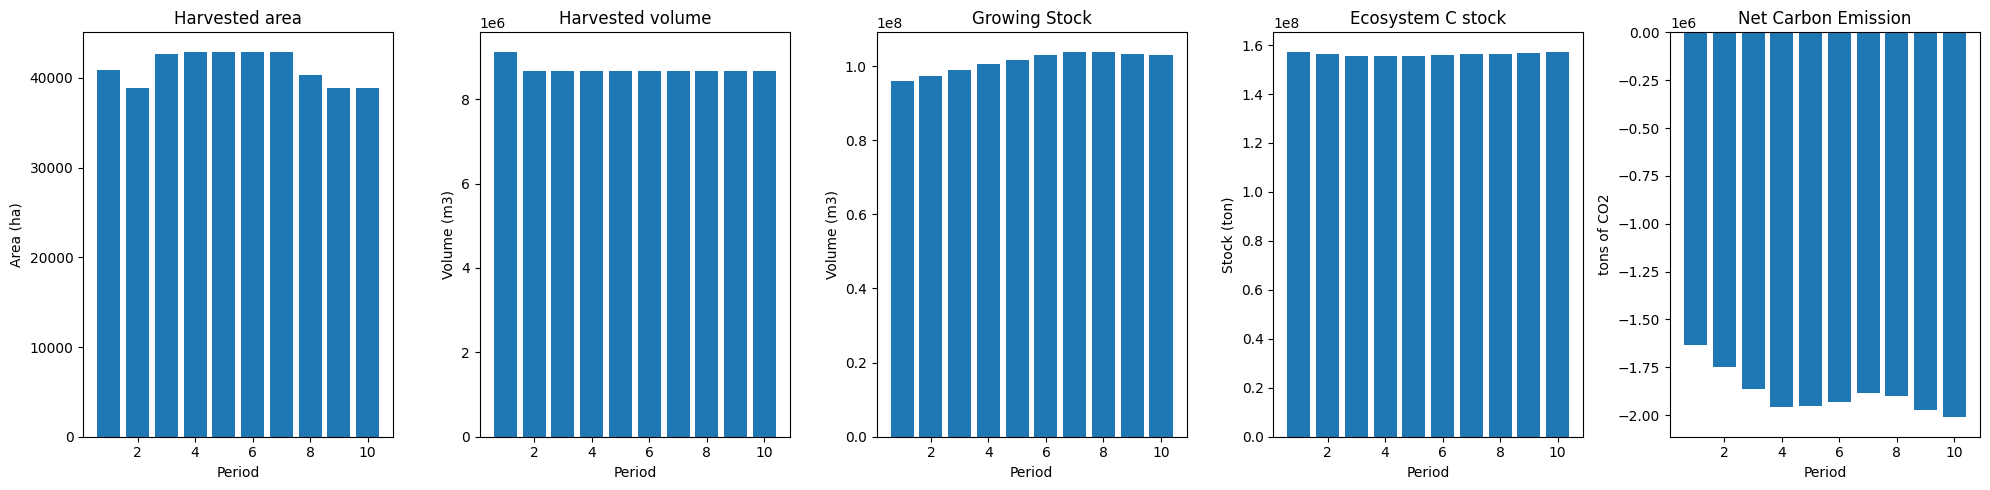

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


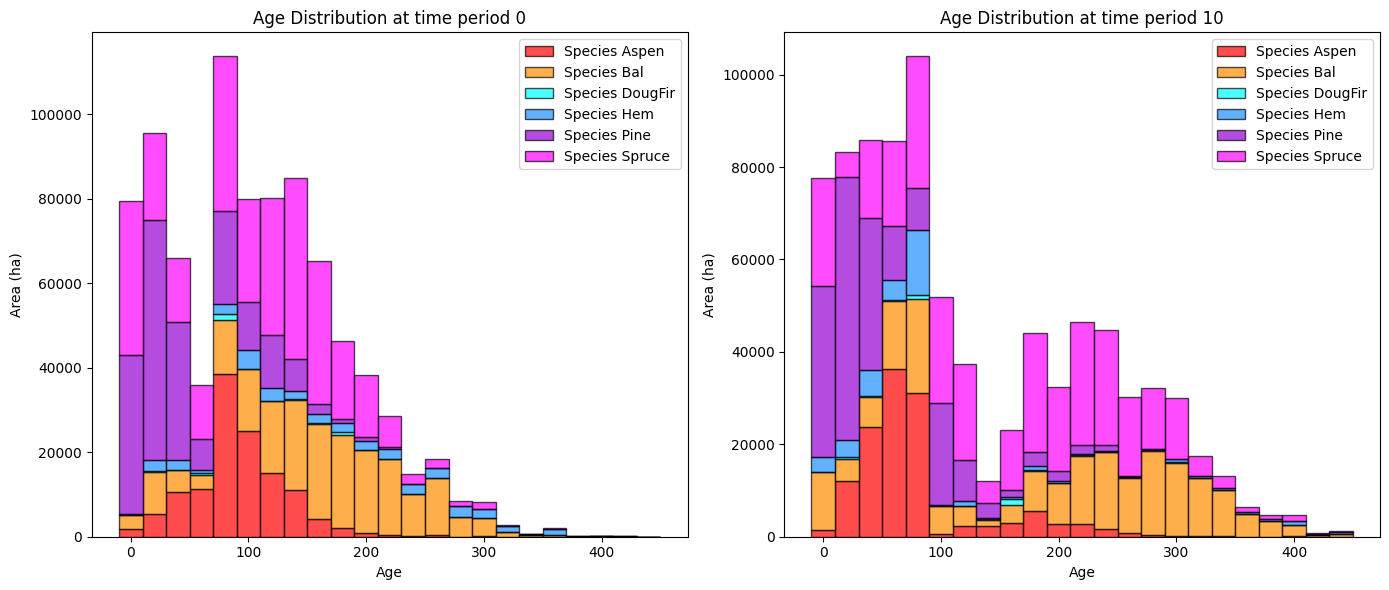

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


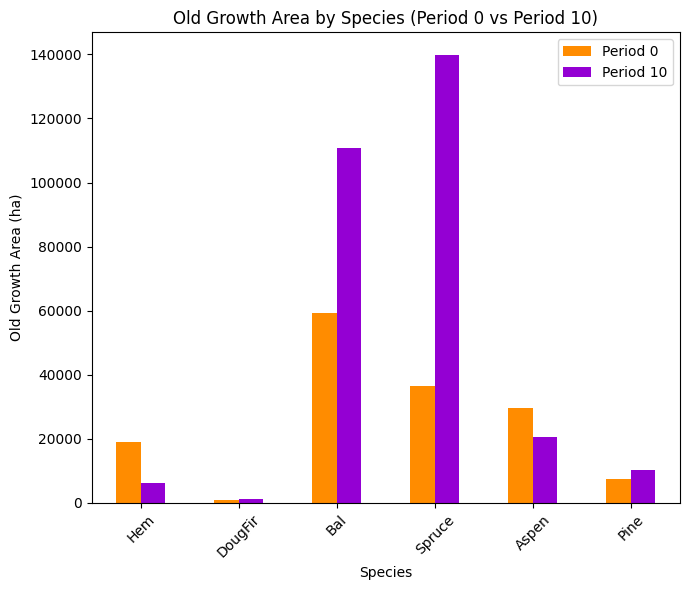

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


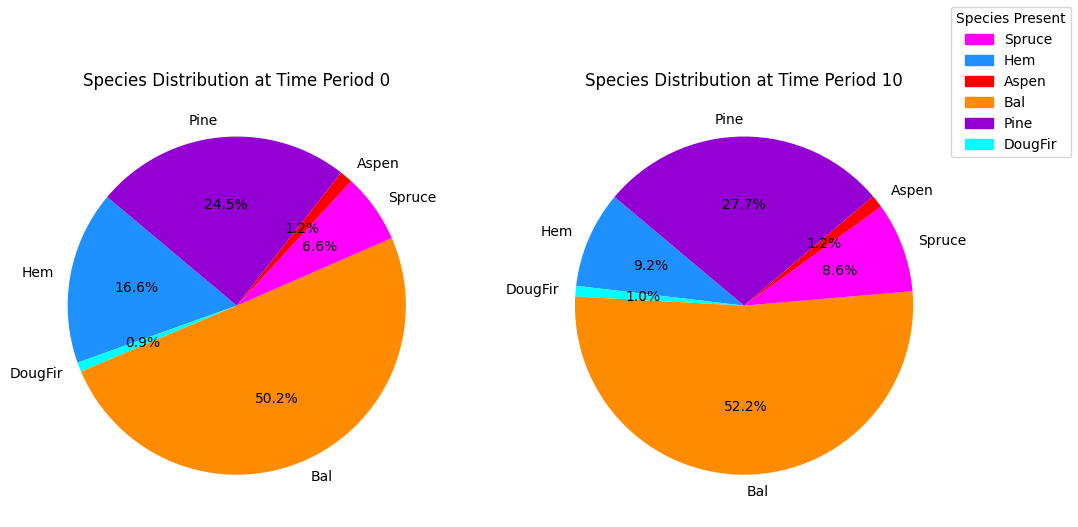

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


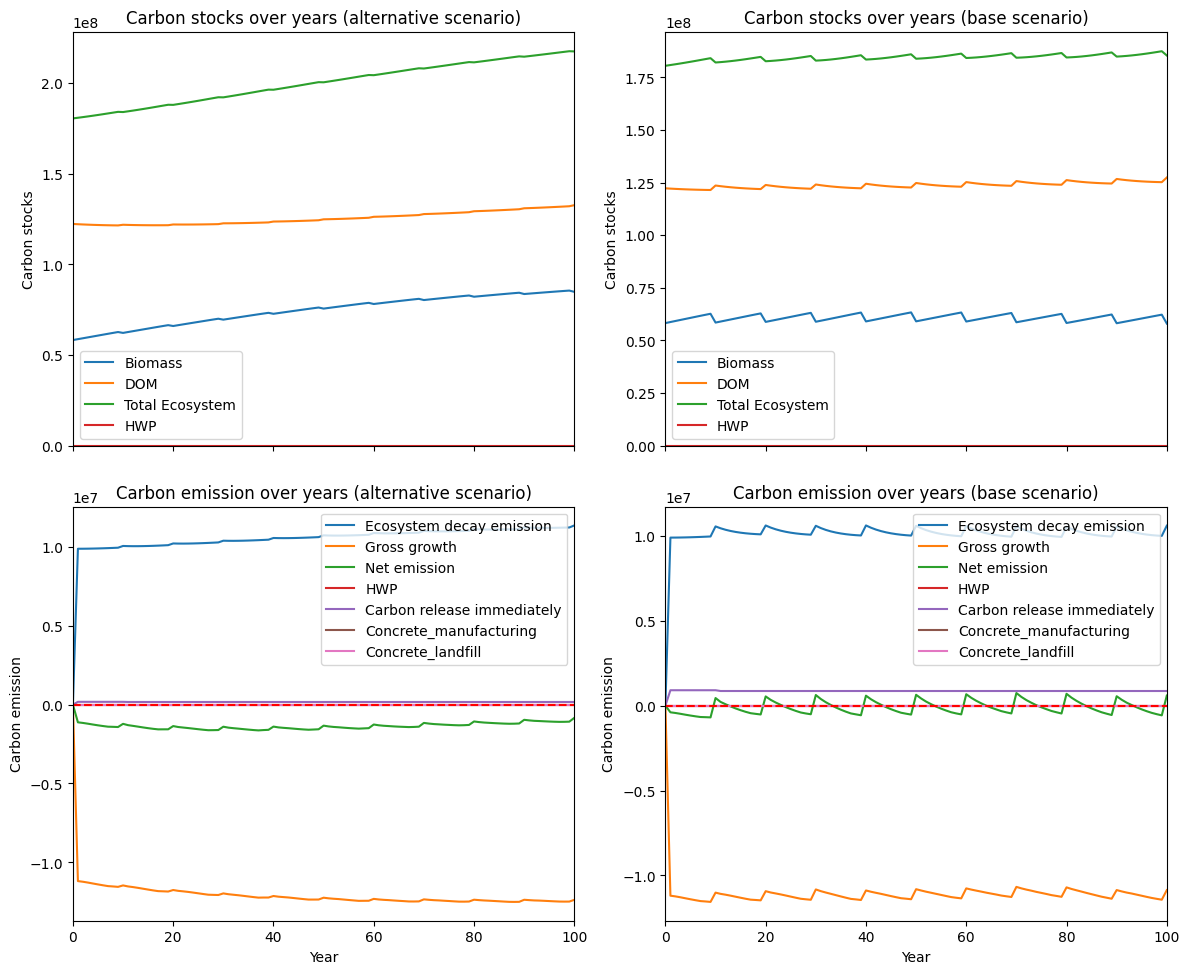

---------------------------------------------------------------------------------------
Net emission difference -27620633.47003322
Net emission base scenario -33272725.39956563
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  0.36204817716615434
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  26409.408269  26409.408269
DougFir  0.0   1390.176949   1390.176949
Bal      0.0  46798.376425  46798.376425
Spruce   0.0  57938.781835  57938.781835
Aspen    0.0  21929.827661  21929.827661
Pine     0.0  53201.432678  53201.432678

Overall, the old growth area has **increased** by 207668.00 hectares in the alternative scenario compared to the base scenario.


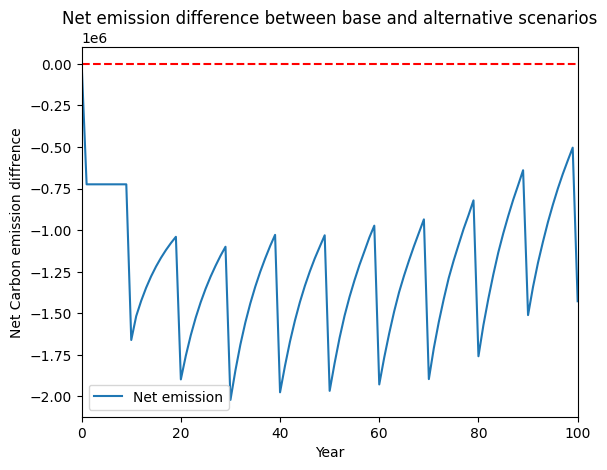

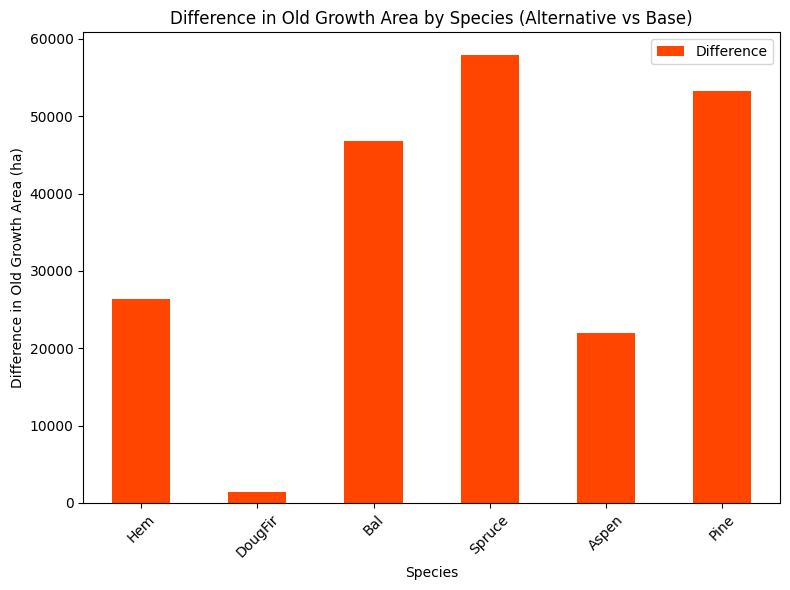

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


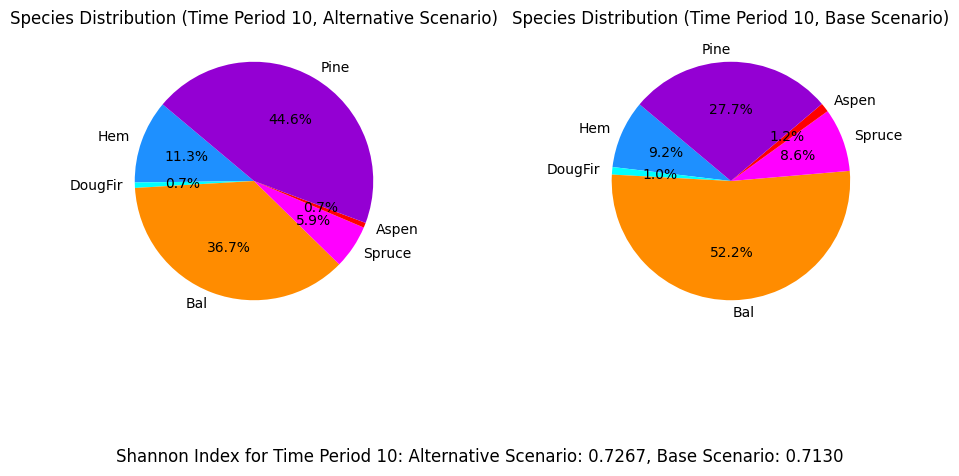

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for equitysilver_min_em_eqtslvr_AAC_10%...
running the scenario for the Equity Silver mining site (10%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0x0713f37a
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.23s
Presolved: 8375 r

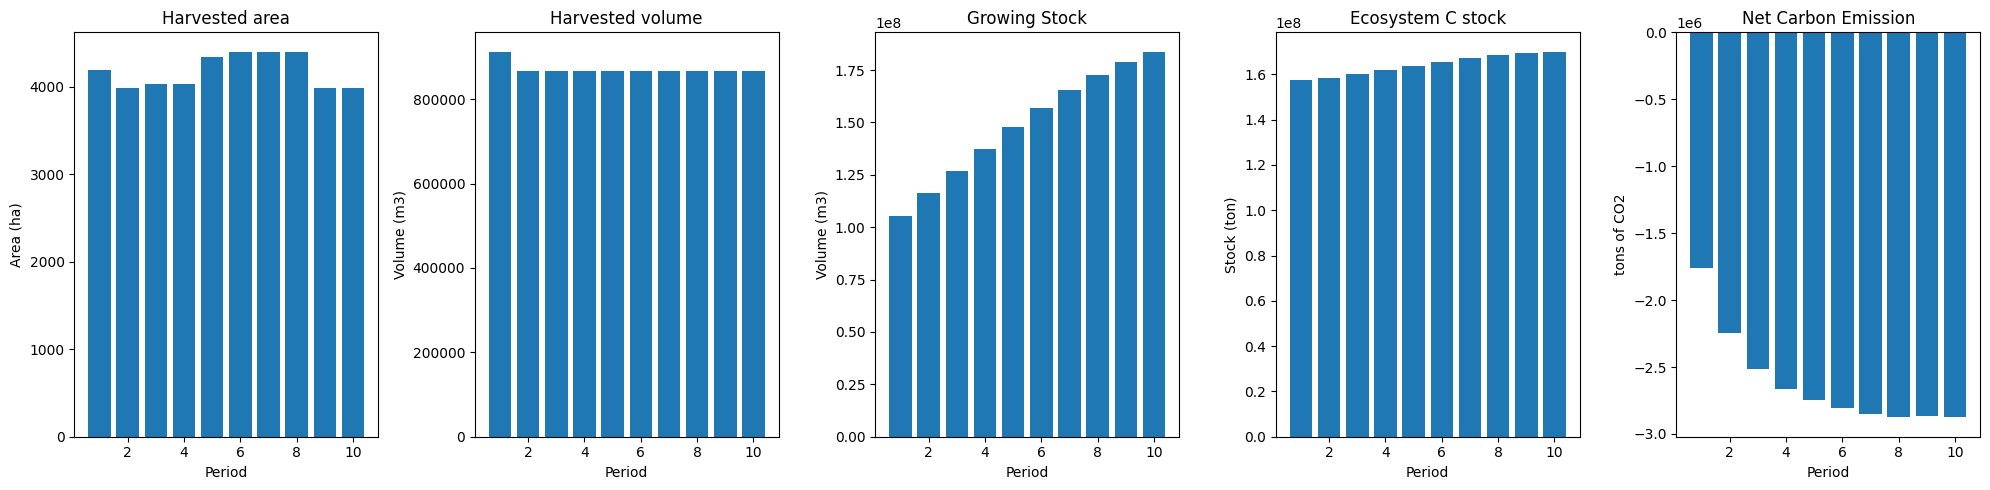

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_10%_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  9215
The economic indicator (the provincial government revenues) is:  314275
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


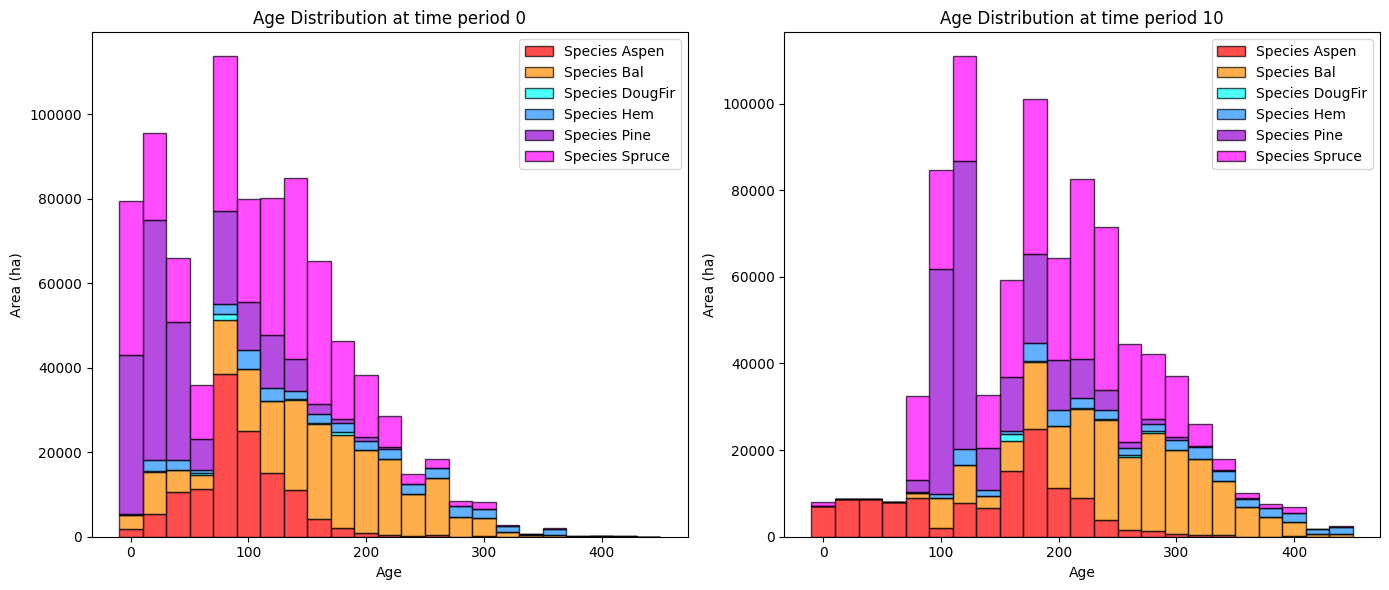

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_10%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229   32688.964561   13536.837333
DougFir    947.047810    2749.298212    1802.250402
Bal      59315.970469  157689.747715   98373.777247
Spruce   36410.744598  197818.592269  161407.847671
Aspen    29632.731169   78581.329617   48948.598448
Pine      7432.733686   70671.811755   63239.078069

Overall diversity has **increased** by 387308.39 hectares from time period 0 to time period 10.


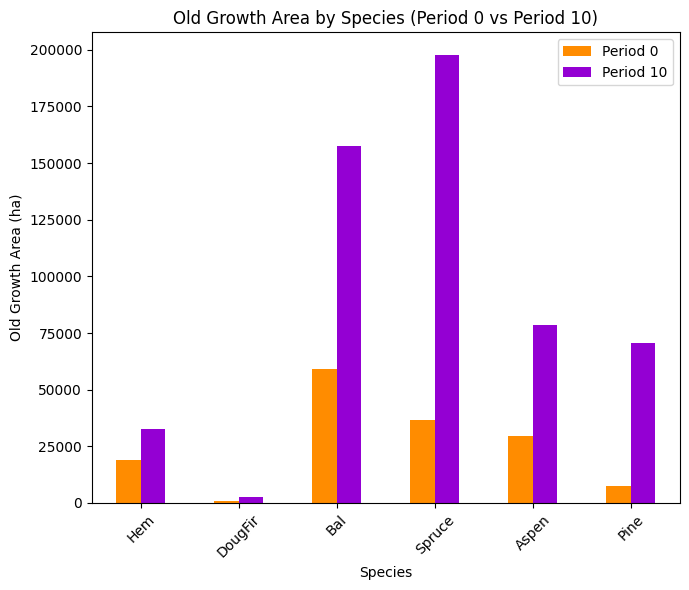

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_10%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7374

Diversity has **decreased** by 2.18% from time 0 to time 10.


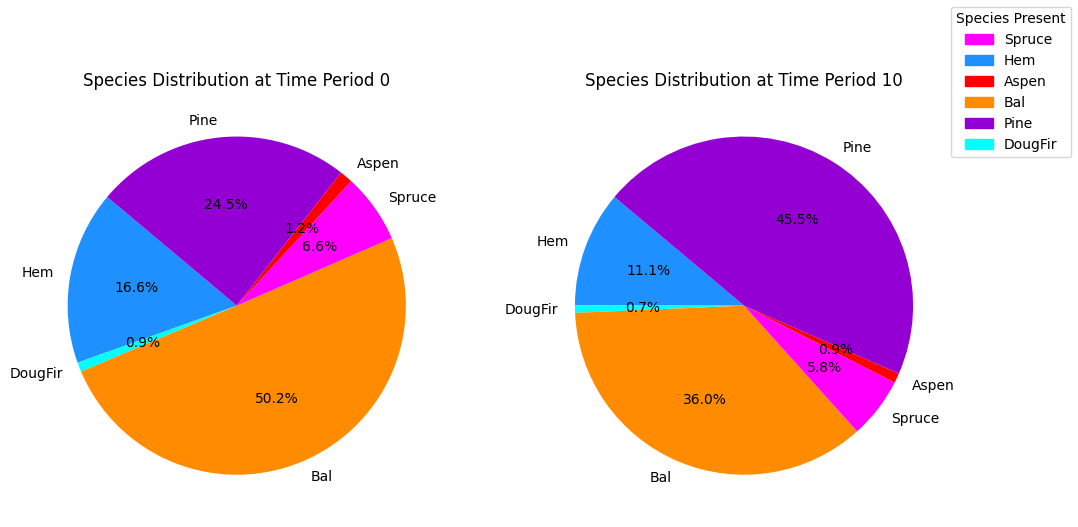

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_eqtslvr_AAC_10%_species_pie.pdf
running business as usual scenario for the Equity Silver mining site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 17067 rows, 83258 columns and 631504 nonzeros
Model fingerprint: 0xf9d6bd3f
Coefficient statistics:
  Matrix range     [5e-03, 7e+05]
  Objective range  [3e-02, 5e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+11]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 8692 rows and 8884 columns
Presolve time: 0.24s
Presolved: 8375 rows, 74375 columns, 536310 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Or

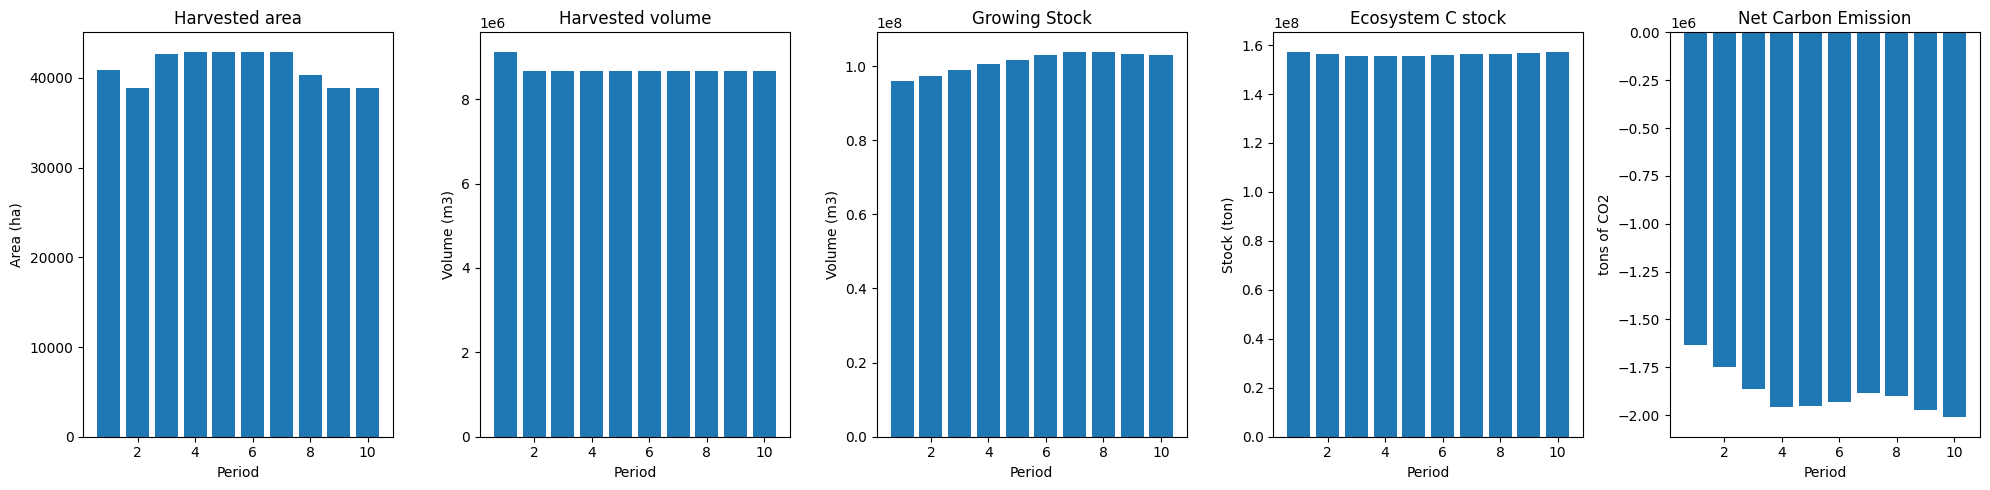

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_scheduling_minemission.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  92157
The economic indicator (the provincial government revenues) is:  3142756
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


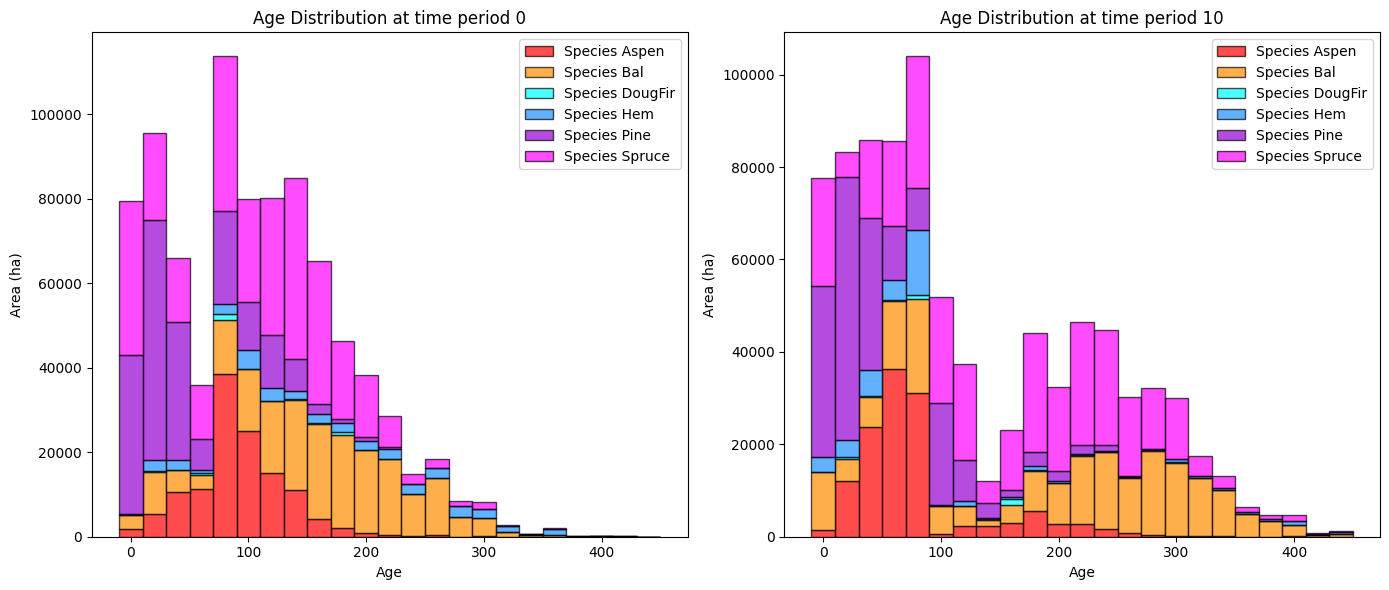

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                    0             10     Difference
Hem      19152.127229    6279.556292  -12872.570937
DougFir    947.047810    1359.121263     412.073453
Bal      59315.970469  110891.371291   51575.400822
Spruce   36410.744598  139879.810435  103469.065837
Aspen    29632.731169   20689.527968   -8943.203201
Pine      7432.733686   10185.208043    2752.474357

Overall diversity has **increased** by 136393.24 hectares from time period 0 to time period 10.


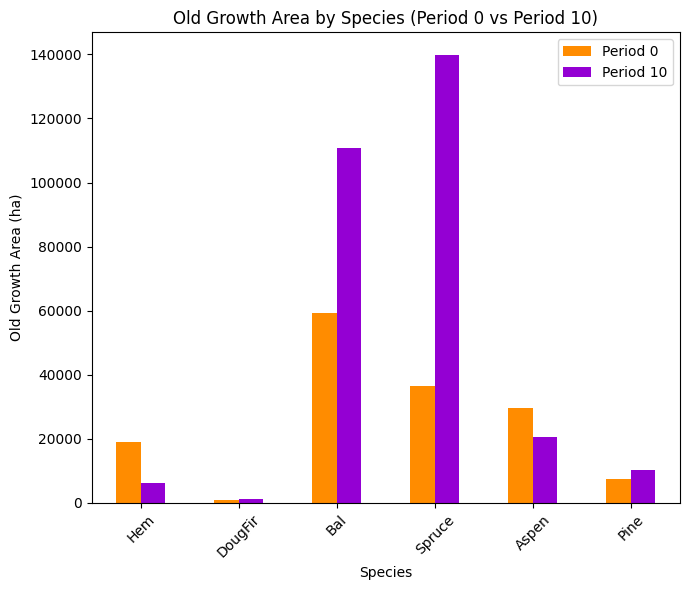

Clustered column plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.7592
Shannon Evenness Index for time period 10: 0.7130

Diversity has **decreased** by 4.61% from time 0 to time 10.


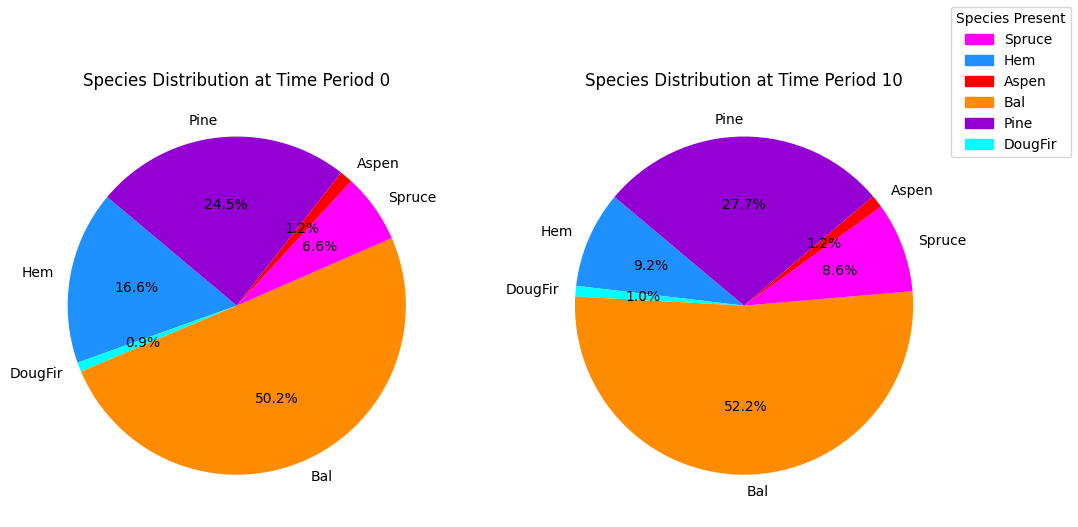

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_bau_eqtslvr_species_pie.pdf


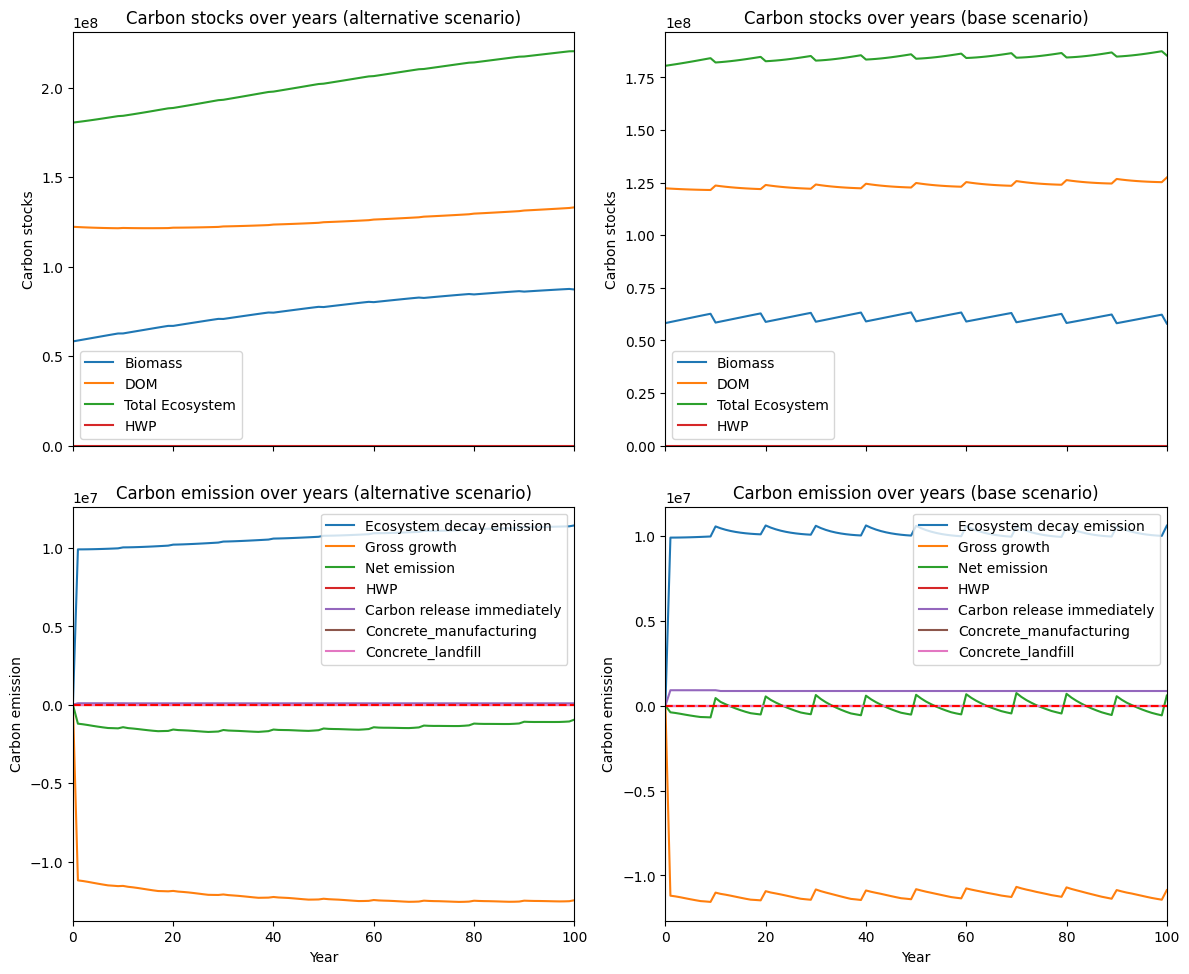

---------------------------------------------------------------------------------------
Net emission difference -30871498.291750997
Net emission base scenario -36523590.221283406
Net emission alternative scenario -5652091.929532407
dollar_per_ton is:  0.3239233776571202
Comparison of Old Growth Areas (Alternative - Base)
           0            10    Difference
Hem      0.0  26409.408269  26409.408269
DougFir  0.0   1390.176949   1390.176949
Bal      0.0  46798.376425  46798.376425
Spruce   0.0  57938.781835  57938.781835
Aspen    0.0  57891.801649  57891.801649
Pine     0.0  60486.603712  60486.603712

Overall, the old growth area has **increased** by 250915.15 hectares in the alternative scenario compared to the base scenario.


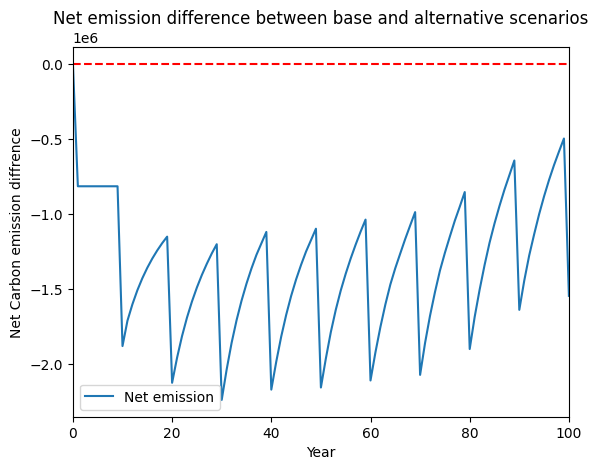

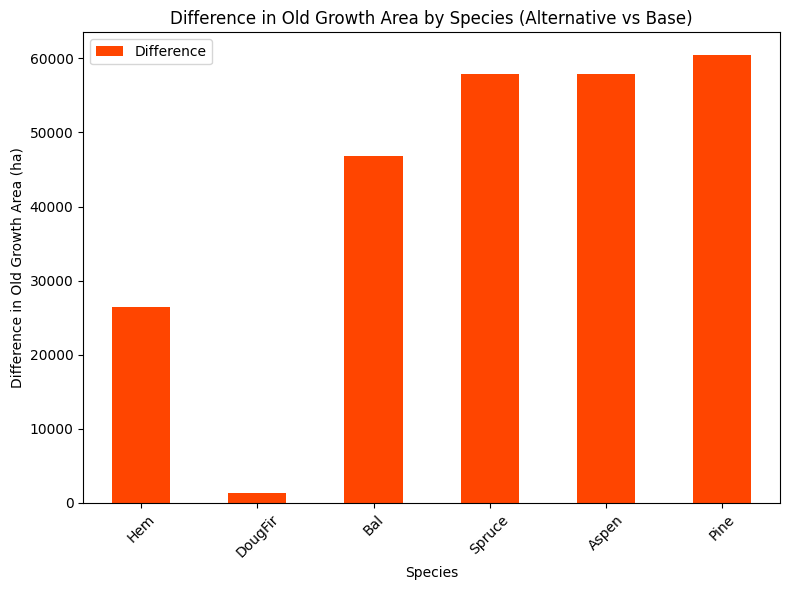

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_age_difference.pdf


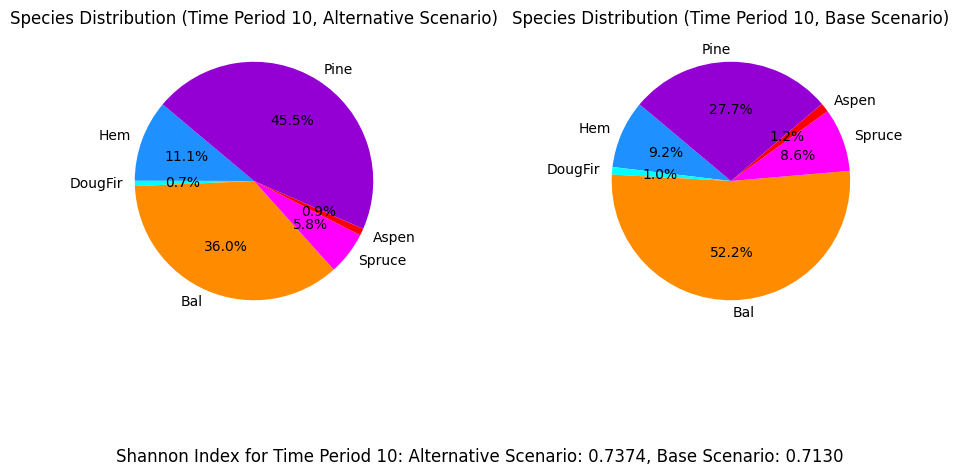

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/equitysilver/equitysilver_min_em_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
It took 345.4 minutes to run all scenarios.


In [12]:
Start = time.time()
scenario_names = scenario_options.get(case_study, [])
for scenario_name in scenario_names:
    print(f"Running for {case_study}_{obj_mode}_{scenario_name}...")
    results_scenarios(fm, 
                      clt_percentage, 
                      credibility, 
                      budget_input, 
                      n_steps, 
                      max_harvest, 
                      scenario_name, 
                      displacement_effect, 
                      hwp_pool_effect_value, 
                      release_immediately_value, 
                      case_study, 
                      obj_mode,                   
                      pickle_output_base=False, 
                      pickle_output_alter=False)
print('It took', round((time.time() - Start) / 60, 1), "minutes to run all scenarios.")

In [13]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 345.4 minutes to run this script.
